### Set Up

In [1]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
from io import BytesIO
import gzip
from astropy.io import fits
from pathlib import Path


lsst_zip = Path(
    "/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip"
)
head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"
readme_name = "LSST_ALERTS/LSST/LSST.README"

# Bits used
DETECTION_BIT = 1
GARBAGE_BIT = 64
VALID_BANDS = np.array(list("ugrizy"))

#print("Working directory:". Path.cwd())
print("Archive path:", lsst_zip.resolve())

Archive path: /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip


In [3]:
if not lsst_zip.exists():
    raise FileNotFoundError(f"LSST archive not found: {lsst_zip.resolve()}")
    
try:
    with ZipFile(lsst_zip, "r") as archive:
        names = archive.namelist()
        print(f"Archive entries: {len(names):,}")
        print("\n".join(names[:30]))
except BadZipFile as exc:
    raise BadZipFile(f"Not a valid ZIP archive: {lsst_zip}") from exc



Archive entries: 67
LSST_ALERTS/
LSST_ALERTS/LSST/
LSST_ALERTS/TABLE.GARBAGE
LSST_ALERTS/TEXT_archive/
LSST_ALERTS/SUBMIT.INFO
LSST_ALERTS/.DS_Store
__MACOSX/LSST_ALERTS/._.DS_Store
LSST_ALERTS/MERGE.LOG
LSST_ALERTS/TABLE.SNIDALL
LSST_ALERTS/SCRIPTS_MKDATA.tar.gz
LSST_ALERTS/LSST_CHUNK01/
LSST_ALERTS/ALL.DONE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT010_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT005_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT002_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT007_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT003_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT004_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT006_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST.README
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST.IGNORE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_PHOT.FITS.gz
LSST_AL

In [4]:
with ZipFile(lsst_zip, "r") as archive:
    readme_text = archive.read(readme_name).decode("utf-8", errors = "replace")

print(readme_text[:5000])

DOCUMENTATION: 
  PURPOSE:                   transient lightcurve data files for analysis 
  SOURCE_LSST_FASTDB:        True 
  SURVEY:                    LSST 
  FORMAT:                    FITS 
  USERNAME:                  kessler 
  PHOTFLAG_DETECT:           1 
  # 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  PHOTFLAG_GARBAGE:          64 
  NEVT_GARBAGE_ALL:          4472 
  NEVT_GARBAGE_RADEC:        0 
  NEVT_GARBAGE_FLUX_NOTFLOAT:  29 
  NEVT_GARBAGE_FLUX_ZERO:    4443 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  # 
  NEVT_PROCESS_ALL:          501084 
  NEVT_WRITE_ALL:            501084 
  NEVT_WRITE_HOST_ZSPEC:     0 
  NEVT_WRITE_HOST_ZPHOT:     0 
  NEVT_WRITE_SPECTRA:        0 
  NEVT_REJECT:               0 
  NEVT_WRITE_BY_FIELD(WFD):  451593 
  NEVT_WRITE_BY_FIELD(DDF):  49491 
  WALLTIME:                  15.97  # minutes 
  ABORT_IF_ZERO:             429 
DOCUMENTATION_END: 



### Load + Helpers

In [5]:
def read_gzipped_fits_table(archive: ZipFile, member_name: str):
    """Helper for gzip files"""
    raw = gzip.decompress(archive.read(member_name))
    with fits.open(BytesIO(raw), memmap = False) as hdul:
        data = hdul[1].data.copy()
        columns = list(hdul[1].columns.names)
    return data, columns

with ZipFile(lsst_zip, "r") as archive:
    head_data, head_columns = read_gzipped_fits_table(archive, head_name)
    phot_data, phot_columns = read_gzipped_fits_table(archive, phot_name)

print(f"Head objects: {len(head_data):,}")
print(f"Phot rows: {len(phot_data):,}")
print("\nHead columns:", head_columns)
print("\nPhot columns", phot_columns)

Head objects: 51,000
Phot rows: 273,660

Head columns: ['SNID', 'NAME_IAUC', 'NAME_TRANSIENT', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'REDSHIFT_QUALITYFLAG', 'MASK_REDSHIFT_SOURCE', 'VPEC', 'VPEC_ERR', 'LENSDMU', 'LENSDMU_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG_g', 'HOSTGAL_MAG_r', 'HOSTGAL_MAG_i', 'HOSTGAL_MAG_z', 'HOSTGAL_MAG_y', 'HOSTGAL_MA

In [6]:
def clean_snid(value) -> str:
    """Return SNID as python string"""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace").strip()
    return str(value).strip()

def get_lightcurve(head_row, phot_table=phot_data):
    """ Extract phot rows for one object using SNANA pointers """
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])
    expected = int(head_row["NOBS"])

    lc = phot_table[start:stop]
    if len(lc) != expected:
        raise ValueError(
            f"SNID {clean_snid(head_row['SNID'])}: expected {expected} rows,"
            f"but pointer range returned {len(lc)}."
        )
    return lc

    

### Photometric Quality Mask

In [7]:
def photometry_mask(lc, *, detections_only=False):
    """ Mask for one object phot
    Keeps: finite MJD, FLUXCAL, and FLUXCALERR
    FLUXCALERR > 0
    real lsst band (removes separator)
    no garbage 64 bit

    if detections_only = True, ony allow detectin bit = 1
    """
    mjd = np.asarray(lc["MJD"], dtype=float)
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    mask = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & np.isin(band, VALID_BANDS)
        & ((flag & GARBAGE_BIT) == 0)
    )

    if detections_only:
        mask &= (flag & DETECTION_BIT) != 0

    return mask


def mask_report(lc):
    """Diagnosgic summary of quality mask"""

    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    good = photometry_mask(lc)
    detections = photometry_mask(lc, detections_only = True)
    return {
        "raw_rows": len(lc),
        "good_rows": int(good.sum()),
        "detections": int(detections.sum()),
        "garbage_rows": int(((flag & GARBAGE_BIT) != 0).sum()),
    }

In [8]:
NIGHTLY_DTYPE = [
    ("MJD", float),
    ("BAND", "U1"),
    ("FLUX", float),
    ("FLUXERR", float),
    ("N_EXP", int),
]

def make_nightly_lightcurve(lc):
    """Using Inverse-Variance to combine multi obs into one per night per band"""
    good = photometry_mask(lc)
    if not np.any(good):
        return np.asarray([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    night_id = np.floor(mjd).astype(int)

    records = []
    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)
        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)
            weights = 1.0 / fluxerr[use] ** 2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)
    
    

In [9]:
def valid_redshift(value) -> bool:
    value = float(value)
    return np.isfinite(value) and value > 0


def summarise_object(row, phot_table=phot_data):
    lc = get_lightcurve(row, phot_table)
    good = photometry_mask(lc)
    detection = photometry_mask(lc, detections_only=True)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))

    clean_mjd = mjd[good]
    clean_band = band[good]

    return {
        "SNID": clean_snid(row["SNID"]),
        "SNTYPE": int(row["SNTYPE"]),
        "NOBS": int(row["NOBS"]),
        "N_CLEAN": int(good.sum()),
        "N_DETECT": int(detection.sum()),
        "N_BANDS": int(np.unique(clean_band).size),
        "N_NIGHTS": int(np.unique(np.floor(clean_mjd)).size) if clean_mjd.size else 0,
        "TIME_SPAN": float(np.ptp(clean_mjd)) if clean_mjd.size > 1 else 0.0,
        "HAS_REDSHIFT": valid_redshift(row["REDSHIFT_FINAL"]),
    }


summary = pd.DataFrame(summarise_object(row) for row in head_data)
summary.head()

,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT
0,00000533-33a2-42cf-bfa4-e4951522102f,0,2,2,2,1,2,4.0419,False
1,00001b7e-822c-4030-9b16-cf9cdca02319,0,2,2,2,1,2,30.9735,False
2,00001dd3-dcbc-436f-99d8-5f310e2212ba,0,2,2,2,1,2,10.0075,False
3,00004f91-a3cc-4f46-912b-df70ebb4c131,0,2,2,2,1,2,11.9482,False
4,00005c75-321d-47a7-ad59-9abf192e251b,0,2,2,2,1,2,8.0208,False


### Further Cuts to find candidates with usable data 

In [10]:
SELECTION = {
    # tweak
    "min_clean": 8, # minimum clean photometric measurements 
    # (individual phot rows passing photometry_mask
    "min_detections": 3,
    "min_bands": 2,
    "min_nights": 5,
    "min_time_span_days": 8,
}

# currently require all, can change
candidate_mask = (
    (summary["N_CLEAN"] >= SELECTION["min_clean"])
    & (summary["N_DETECT"] >= SELECTION["min_detections"])
    & (summary["N_BANDS"] >= SELECTION["min_bands"])
    & (summary["N_NIGHTS"] >= SELECTION["min_nights"])
    & (summary["TIME_SPAN"] >= SELECTION["min_time_span_days"])
)

summary["PASS_MASK"] = candidate_mask
candidates = (
    summary.loc[candidate_mask]
    .sort_values(["N_NIGHTS", "N_BANDS", "N_DETECT", "TIME_SPAN"], ascending=False)
    .reset_index(drop=True)
)

print(f"Objects passing: {candidate_mask.sum():,} / {len(candidate_mask):,} "
      f"({100 * candidate_mask.mean():.2f}%)")

display(candidates.head(20))
    

Objects passing: 2,278 / 51,000 (4.47%)


,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT,PASS_MASK
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,0,149,149,125,6,66,180.6791,False,True
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,0,157,157,110,6,65,180.6779,False,True
2,23af3b06-9c88-44d8-a6c2-39a062326bbf,0,147,147,134,6,64,180.7016,False,True
3,1ee3563b-4982-460e-8a6f-f609d50f62c9,0,142,142,110,6,62,176.6518,False,True
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,0,142,142,118,6,60,175.6530,False,True
5,c277a753-263d-45cf-914f-cc97dce31425,0,132,132,128,6,59,164.7465,False,True
6,d1a059cd-5fd8-4b2d-a93d-cf5fc9d1942e,0,129,129,95,6,59,176.6487,False,True
7,946a4392-911b-4e13-8d45-7b3d49d184ec,0,134,134,82,6,59,180.6800,False,True
8,b7f4b026-6b06-494e-9737-a02df930e7de,0,132,132,106,6,56,162.7911,False,True
9,57245251-c21f-4736-8427-2b70bd52bdf1,0,130,130,105,6,54,155.6985,False,True


### Sanity checks

In [12]:
print("SNTYPE counts:")
print(
    pd.Series(np.asarray(head_data["SNTYPE"]).astype(np.int64))
    .value_counts()
    .sort_index()
)

print("\nFAKE counts:")
print(
    pd.Series(np.asarray(head_data["FAKE"]).astype(np.int64))
    .value_counts()
    .sort_index()
)

#print("SNTYPE counts:")
#print(pd.Series(head_data["SNTYPE"]).value_counts().sort_index())

#print("\nFAKE counts:")
#print(pd.Series(head_data["FAKE"]).value_counts().sort_index())

if "SEARCH_TYPE" in head_columns:
    print("\nSEARCH_TYPE counts:")
    print(
        pd.Series(np.asarray(head_data["SEARCH_TYPE"]).astype(np.int64))
        .value_counts()
        .sort_index()
)

print("\nNOBS percentiles:")
print(np.percentile(head_data["NOBS"], [0, 1, 5, 25, 50, 75, 90, 95, 99, 100]))

SNTYPE counts:
0    51000
Name: count, dtype: int64

FAKE counts:
0    51000
Name: count, dtype: int64

SEARCH_TYPE counts:
-9    50999
 0        1
Name: count, dtype: int64

NOBS percentiles:
[  1.   1.   1.   2.   2.   3.   6.  13.  33. 756.]


In [13]:
if candidates.empty:
    raise RuntimeError("No objects pass the current selection mask. Relax SELECTION thresholds.")

best_snid = candidates.loc[0, "SNID"]
head_snids = np.array([clean_snid(value) for value in head_data["SNID"]])
match = np.flatnonzero(head_snids == best_snid)

if match.size != 1:
    raise ValueError(f"Expected exactly one HEAD match for {best_snid!r}; found {match.size}.")

best_idx = int(match[0])
best_row = head_data[best_idx]
best_lc = get_lightcurve(best_row)
best_nightly = make_nightly_lightcurve(best_lc)

print("SNID:", best_snid)
print("HEAD index:", best_idx)
print(mask_report(best_lc))

SNID: a3f7ac57-349f-44a8-bc11-dd101444ace1
HEAD index: 32932
{'raw_rows': 149, 'good_rows': 149, 'detections': 125, 'garbage_rows': 0}


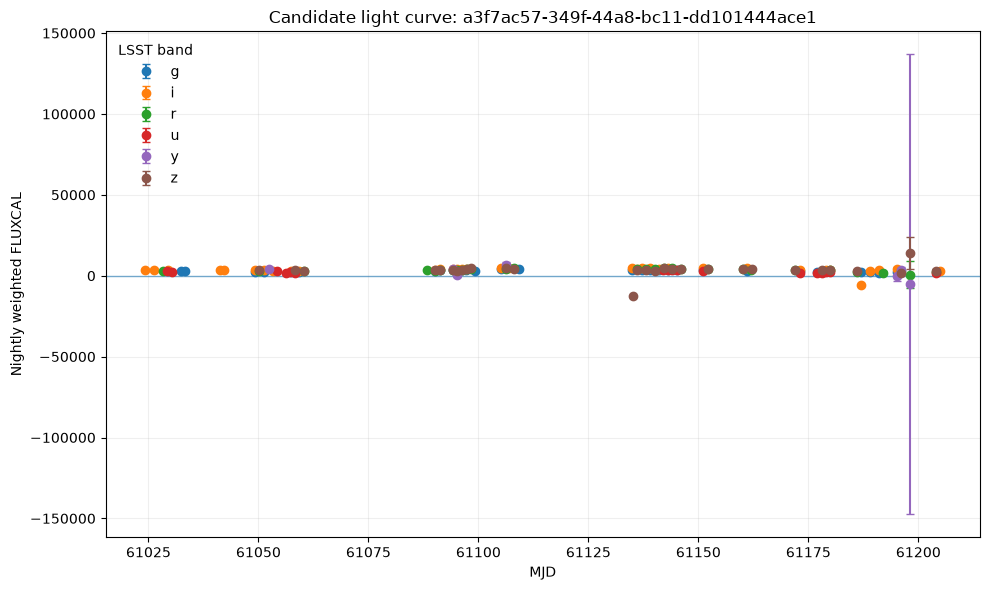

In [14]:
def plot_nightly_lightcurve(nightly, snid=None):
    if len(nightly) == 0:
        print("No clean nightly photometry to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))

    for current_band in np.unique(nightly["BAND"]):
        use = nightly["BAND"] == current_band
        order = np.argsort(nightly["MJD"][use])
        ax.errorbar(
            nightly["MJD"][use][order],
            nightly["FLUX"][use][order],
            yerr=nightly["FLUXERR"][use][order],
            fmt="o",
            capsize=3,
            label=current_band,
        )

    ax.axhline(0, linewidth=1, alpha=0.6)
    ax.set_xlabel("MJD")
    ax.set_ylabel("Nightly weighted FLUXCAL")
    ax.set_title(f"Candidate light curve: {snid}" if snid else "Nightly light curve")
    ax.legend(title="LSST band", frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


plot_nightly_lightcurve(best_nightly, best_snid)

In [15]:
# Comparison to unmasked version

good = photometry_mask(best_lc)
detect = photometry_mask(best_lc, detections_only=True)

inspection = pd.DataFrame({
    "MJD": np.asarray(best_lc["MJD"], dtype=float),
    "BAND": np.char.strip(np.asarray(best_lc["BAND"]).astype(str)),
    "FLUXCAL": np.asarray(best_lc["FLUXCAL"], dtype=float),
    "FLUXCALERR": np.asarray(best_lc["FLUXCALERR"], dtype=float),
    "PHOTFLAG": np.asarray(best_lc["PHOTFLAG"], dtype=int),
    "GOOD": good,
    "DETECTION": detect,
})

display(inspection)

,MJD,BAND,FLUXCAL,FLUXCALERR,PHOTFLAG,GOOD,DETECTION
0,61024.2948,i,3800.199951,98.334999,1,True,True
1,61026.2137,i,3795.199951,317.170013,1,True,True
2,61028.3266,r,3106.199951,57.818001,1,True,True
3,61029.3241,u,2729.500000,125.769997,1,True,True
4,61029.3311,g,2677.300049,154.949997,1,True,True
...,...,...,...,...,...,...,...
144,61198.0024,z,13864.000000,9813.500000,0,True,False
145,61204.0172,u,1563.000000,1060.400024,0,True,False
146,61204.0213,r,2193.399902,744.479980,0,True,False
147,61204.0256,z,2992.800049,1126.800049,0,True,False


### Refinements of Cuts

In [16]:
def science_quality_mask(lc, min_snr=3.0):
    """Select clean photometry with |FLUXCAL| / FLUXCALERR >= min_snr."""
    good = photometry_mask(lc)

    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    snr = np.zeros(len(lc), dtype=float)
    snr[good] = np.abs(flux[good]) / fluxerr[good]

    return good & (snr >= min_snr)
    
def positive_detection_mask(lc, min_snr=3.0):
    """
    Select clean, positive, high-S/N photometric measurements.
    """
    good = photometry_mask(lc)

    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    snr = np.zeros(len(lc), dtype=float)
    snr[good] = flux[good] / fluxerr[good]

    return good & (snr >= min_snr)

In [17]:
quality = science_quality_mask(best_lc, min_snr=3.0)

print("Total rows:", len(best_lc))
print("Basic clean rows:", photometry_mask(best_lc).sum())
print("High-S/N clean rows:", quality.sum())

Total rows: 149
Basic clean rows: 149
High-S/N clean rows: 138


In [18]:
test_df = pd.DataFrame({
    "MJD": np.asarray(best_lc["MJD"], dtype=float),
    "BAND": np.char.strip(np.asarray(best_lc["BAND"]).astype(str)),
    "FLUXCAL": np.asarray(best_lc["FLUXCAL"], dtype=float),
    "FLUXCALERR": np.asarray(best_lc["FLUXCALERR"], dtype=float),
})

test_df["SNR"] = (
    np.abs(test_df["FLUXCAL"])
    / test_df["FLUXCALERR"]
)

test_df["BASIC_GOOD"] = photometry_mask(best_lc)
test_df["SCIENCE_QUALITY"] = quality

display(test_df)

,MJD,BAND,FLUXCAL,FLUXCALERR,SNR,BASIC_GOOD,SCIENCE_QUALITY
0,61024.2948,i,3800.199951,98.334999,38.645447,True,True
1,61026.2137,i,3795.199951,317.170013,11.965822,True,True
2,61028.3266,r,3106.199951,57.818001,53.723752,True,True
3,61029.3241,u,2729.500000,125.769997,21.702314,True,True
4,61029.3311,g,2677.300049,154.949997,17.278478,True,True
...,...,...,...,...,...,...,...
144,61198.0024,z,13864.000000,9813.500000,1.412748,True,False
145,61204.0172,u,1563.000000,1060.400024,1.473972,True,False
146,61204.0213,r,2193.399902,744.479980,2.946217,True,False
147,61204.0256,z,2992.800049,1126.800049,2.656017,True,False


In [19]:
def make_quality_nightly_lightcurve(lc, min_snr=3.0):
    """
    Inverse-variance combine high-quality measurements
    by integer MJD and band.
    """
    good = science_quality_mask(lc, min_snr=min_snr)

    if not np.any(good):
        return np.array([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    night_id = np.floor(mjd).astype(int)

    records = []

    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)

        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)

            weights = 1.0 / fluxerr[use]**2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)

In [20]:
best_nightly_quality = make_quality_nightly_lightcurve(
    best_lc,
    min_snr=3.0
)

In [21]:
print("Original nightly points:", len(best_nightly))
print("High-S/N nightly points:", len(best_nightly_quality))

Original nightly points: 149
High-S/N nightly points: 138


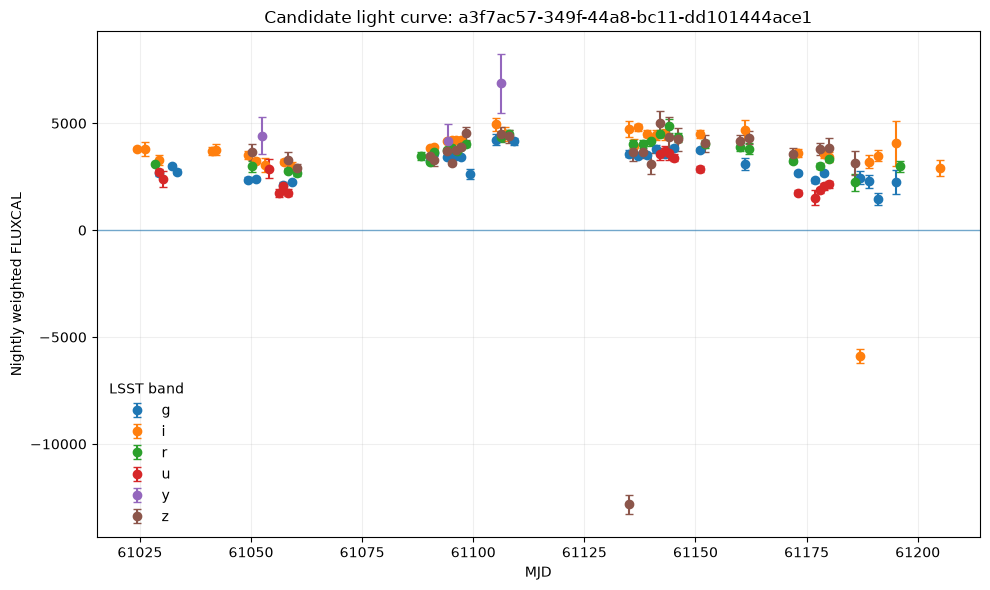

In [22]:
plot_nightly_lightcurve(
    best_nightly_quality,
    best_snid
)

In [23]:
basic_good = photometry_mask(best_lc)
science_good = science_quality_mask(best_lc, min_snr=3.0)
positive_good = positive_detection_mask(best_lc, min_snr=3.0)

print("Raw rows:", len(best_lc))
print("Basic good:", basic_good.sum())
print("Science quality |S/N| >= 3:", science_good.sum())
print("Positive S/N >= 3:", positive_good.sum())

Raw rows: 149
Basic good: 149
Science quality |S/N| >= 3: 138
Positive S/N >= 3: 136


In [24]:
flux = np.asarray(best_lc["FLUXCAL"], dtype=float)
fluxerr = np.asarray(best_lc["FLUXCALERR"], dtype=float)
mjd = np.asarray(best_lc["MJD"], dtype=float)
band = np.char.strip(np.asarray(best_lc["BAND"]).astype(str))

snr = flux / fluxerr

negative_significant = science_good & (snr < -3)

negative_df = pd.DataFrame({
    "MJD": mjd[negative_significant],
    "BAND": band[negative_significant],
    "FLUXCAL": flux[negative_significant],
    "FLUXCALERR": fluxerr[negative_significant],
    "SNR": snr[negative_significant],
})

display(negative_df)

,MJD,BAND,FLUXCAL,FLUXCALERR,SNR
0,61135.0433,z,-12831.000000,442.980011,-28.965190
1,61186.9812,i,-5881.399902,336.730011,-17.466218


In [25]:
def make_positive_nightly_lightcurve(lc, min_snr=3.0):
    good = positive_detection_mask(lc, min_snr=min_snr)

    if not np.any(good):
        return np.array([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    night_id = np.floor(mjd).astype(int)

    records = []

    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)

        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)

            weights = 1.0 / fluxerr[use]**2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)

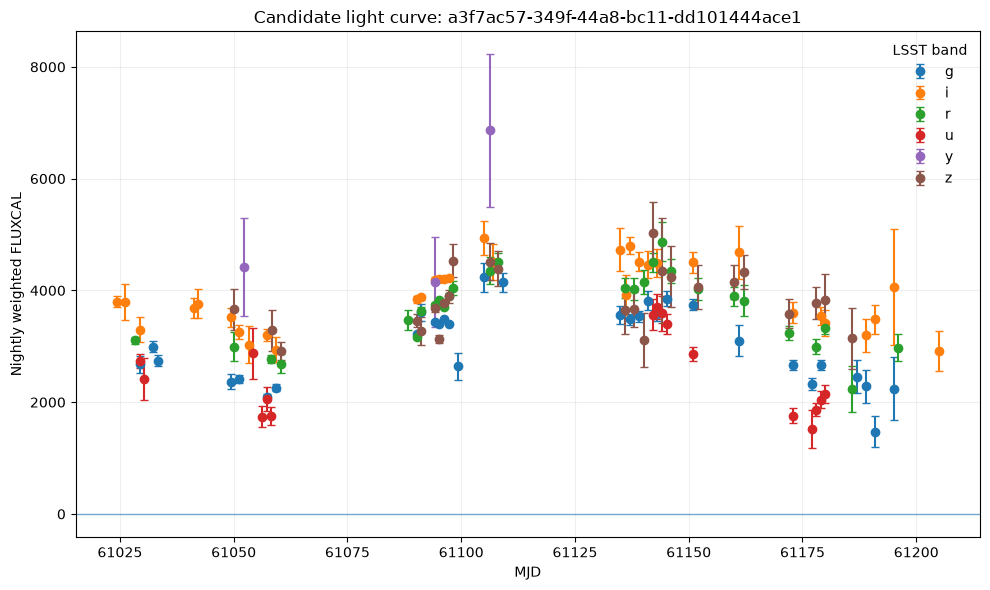

In [26]:
best_nightly_positive = make_positive_nightly_lightcurve(
    best_lc,
    min_snr=3.0
)

plot_nightly_lightcurve(
    best_nightly_positive,
    best_snid
)

### Specific SN lc cuts (exploratory):

In [27]:
def transient_metrics(lc, min_snr=3.0):
    good = photometry_mask(lc)
    pos = positive_detection_mask(lc, min_snr=min_snr)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    if not np.any(good):
        return {
            "N_POS": 0,
            "N_POS_BANDS": 0,
            "N_POS_NIGHTS": 0,
            "PEAK_FLUX": np.nan,
            "BASELINE_FLUX": np.nan,
            "AMPLITUDE": np.nan,
            "PEAK_SNR": np.nan,
            "EVENT_SPAN": np.nan,
        }

    # Positive high-S/N measurements
    n_pos = int(pos.sum())
    n_pos_bands = len(np.unique(band[pos])) if np.any(pos) else 0
    n_pos_nights = (
        len(np.unique(np.floor(mjd[pos]).astype(int)))
        if np.any(pos) else 0
    )

    # Peak measurement
    if np.any(pos):
        peak_idx = np.argmax(flux[pos])
        peak_flux = flux[pos][peak_idx]
        peak_mjd = mjd[pos][peak_idx]
        peak_snr = np.max(flux[pos] / fluxerr[pos])
    else:
        peak_flux = np.nan
        peak_mjd = np.nan
        peak_snr = np.nan

    # Simple baseline: median of clean measurements
    baseline_flux = np.median(flux[good])

    amplitude = (
        peak_flux - baseline_flux
        if np.isfinite(peak_flux)
        else np.nan
    )

    # Duration covered by significant positive measurements
    if np.sum(pos) >= 2:
        event_span = mjd[pos].max() - mjd[pos].min()
    else:
        event_span = np.nan

    return {
        "N_POS": n_pos,
        "N_POS_BANDS": n_pos_bands,
        "N_POS_NIGHTS": n_pos_nights,
        "PEAK_FLUX": peak_flux,
        "BASELINE_FLUX": baseline_flux,
        "AMPLITUDE": amplitude,
        "PEAK_SNR": peak_snr,
        "EVENT_SPAN": event_span,
    }


In [28]:
transient_rows = []

for idx in range(len(head_data)):
    head_row = head_data[idx]

    lc = get_lightcurve(head_row)
    metrics = transient_metrics(lc, min_snr=3.0)

    transient_rows.append({
        "HEAD_INDEX": idx,
        "SNID": str(head_row["SNID"]),
        **metrics,
    })

transient_summary = pd.DataFrame(transient_rows)

In [29]:
# Explore dist of cuts

display(
    transient_summary[
        [
            "N_POS",
            "N_POS_BANDS",
            "N_POS_NIGHTS",
            "AMPLITUDE",
            "PEAK_SNR",
            "EVENT_SPAN",
        ]
    ].describe()
)

,N_POS,N_POS_BANDS,N_POS_NIGHTS,AMPLITUDE,PEAK_SNR,EVENT_SPAN
count,51000.000000,51000.000000,51000.000000,1.220400e+04,12204.000000,6532.000000
mean,1.079137,0.370137,0.628980,7.137237e+03,22.531003,27.927161
std,7.095465,0.803358,2.260074,4.034602e+04,54.663706,42.849975
min,0.000000,0.000000,0.000000,-4.530500e+02,3.002405,0.000100
25%,0.000000,0.000000,0.000000,0.000000e+00,7.387261,3.981375
50%,0.000000,0.000000,0.000000,6.218250e+02,11.426524,9.948950
75%,0.000000,0.000000,0.000000,2.636770e+03,18.684036,38.830600
max,594.000000,6.000000,63.000000,1.571460e+06,2057.171487,250.199200


In [30]:
transient_mask = (
    (transient_summary["N_POS"] >= 5)
    & (transient_summary["N_POS_BANDS"] >= 2)
    & (transient_summary["N_POS_NIGHTS"] >= 4)
    & (transient_summary["PEAK_SNR"] >= 5)
    & (transient_summary["AMPLITUDE"] > 0)
)

In [31]:
transient_candidates = (
    transient_summary.loc[transient_mask]
    .sort_values(
        [
            "PEAK_SNR",
            "AMPLITUDE",
            "N_POS_NIGHTS",
            "N_POS_BANDS",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

Best transient candidate
------------------------
SNID: bd0b7764-c21c-47f8-a4f5-fd87e7238898
HEAD index: 37136


,HEAD_INDEX,SNID,N_POS,N_POS_BANDS,N_POS_NIGHTS,PEAK_FLUX,BASELINE_FLUX,AMPLITUDE,PEAK_SNR,EVENT_SPAN
0,37136,bd0b7764-c21c-47f8-a4f5-fd87e7238898,46,6,27,303260.0,-37676.0,340936.0,2057.171487,174.7015


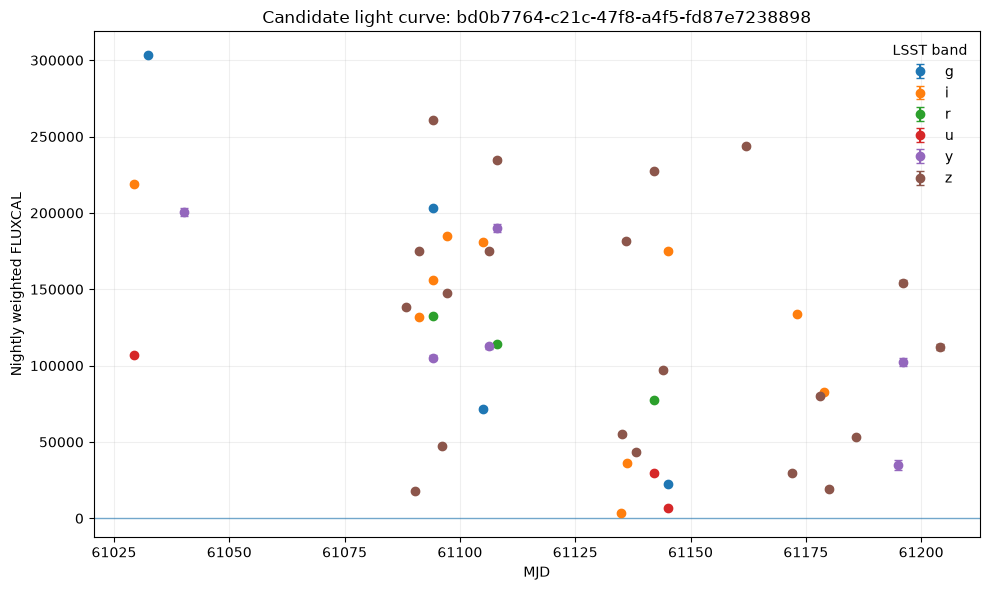

In [32]:
best_transient = transient_candidates.iloc[0]

best_idx = int(best_transient["HEAD_INDEX"])
best_snid = best_transient["SNID"]

best_head_row = head_data[best_idx]
best_transient_lc = get_lightcurve(best_head_row)

best_transient_nightly = make_positive_nightly_lightcurve(
    best_transient_lc,
    min_snr=3.0,
)

print("Best transient candidate")
print("------------------------")
print("SNID:", best_snid)
print("HEAD index:", best_idx)

display(best_transient.to_frame().T)

plot_nightly_lightcurve(
    best_transient_nightly,
    best_snid,
)


Rank 1: bd0b7764-c21c-47f8-a4f5-fd87e7238898
N_POS=46, N_POS_NIGHTS=27, N_POS_BANDS=6, PEAK_SNR=2057.2, AMPLITUDE=340936.0


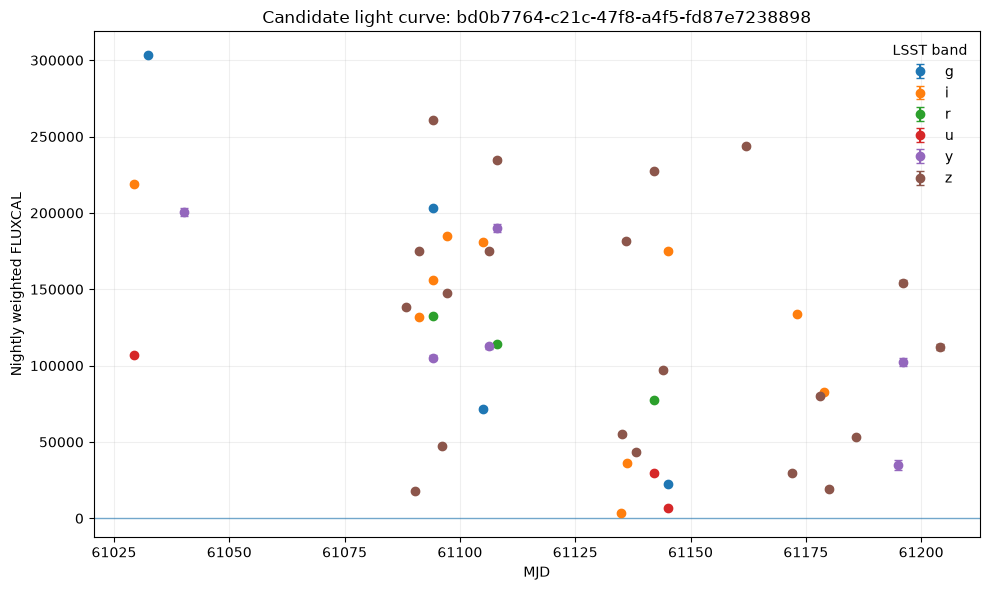


Rank 2: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
N_POS=88, N_POS_NIGHTS=47, N_POS_BANDS=4, PEAK_SNR=1652.3, AMPLITUDE=56062.0


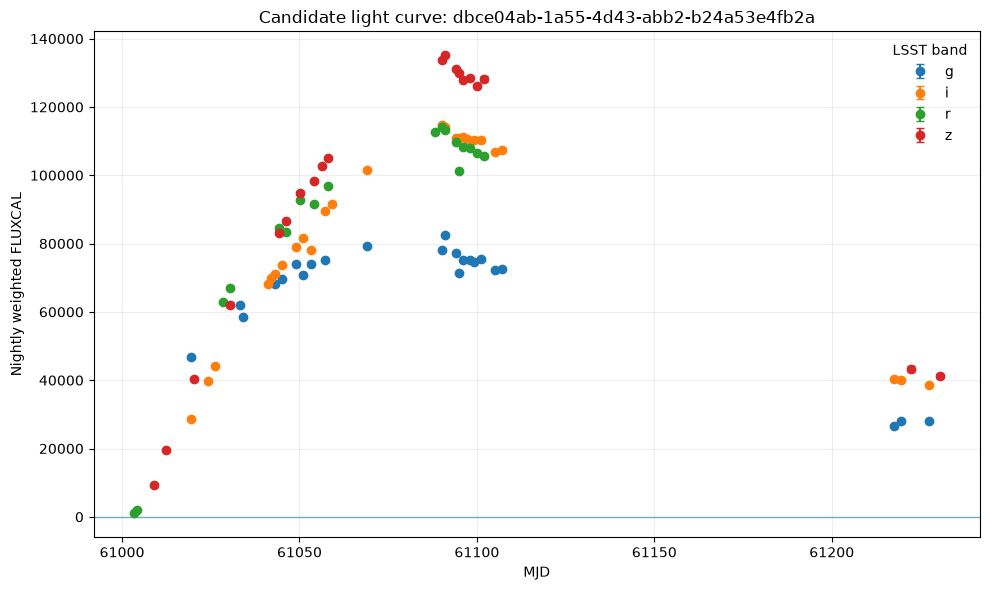


Rank 3: 42c4d994-fd32-46c1-8099-3b39ea5eb532
N_POS=53, N_POS_NIGHTS=34, N_POS_BANDS=6, PEAK_SNR=1326.4, AMPLITUDE=52104.9


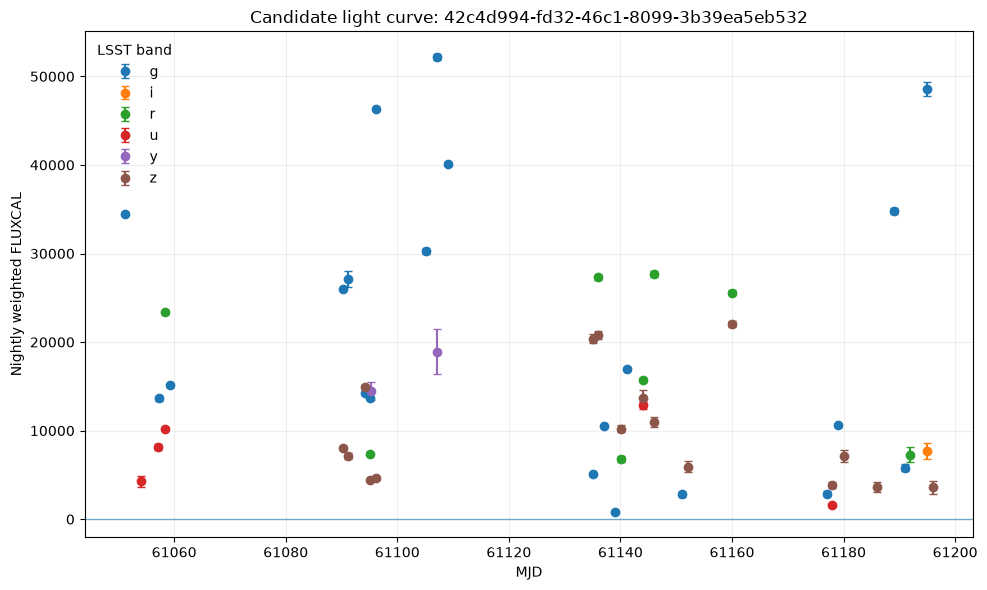


Rank 4: a8f9b606-293f-473b-9ca2-371b8d9ff71e
N_POS=23, N_POS_NIGHTS=8, N_POS_BANDS=5, PEAK_SNR=951.8, AMPLITUDE=57390.0


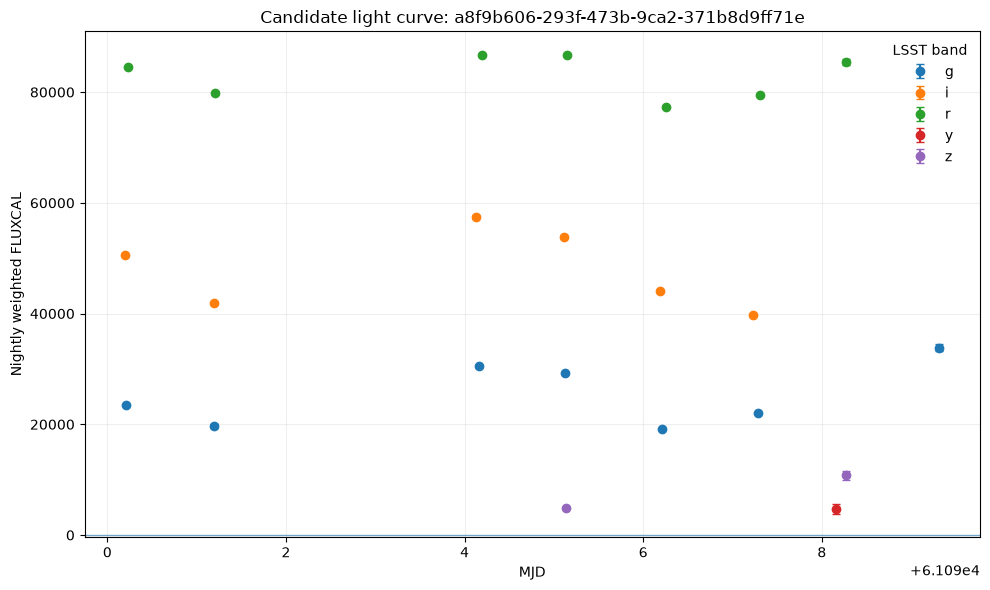


Rank 5: 8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1
N_POS=29, N_POS_NIGHTS=23, N_POS_BANDS=4, PEAK_SNR=797.9, AMPLITUDE=105205.0


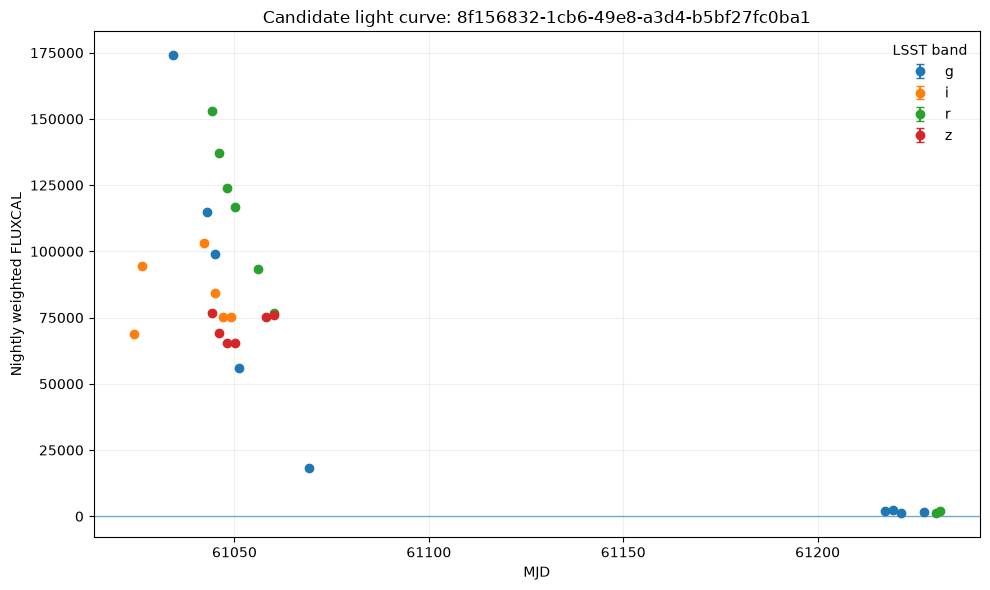


Rank 6: b80c74be-6838-42eb-814d-1cffd0bbfd85
N_POS=25, N_POS_NIGHTS=12, N_POS_BANDS=3, PEAK_SNR=776.0, AMPLITUDE=7100.0


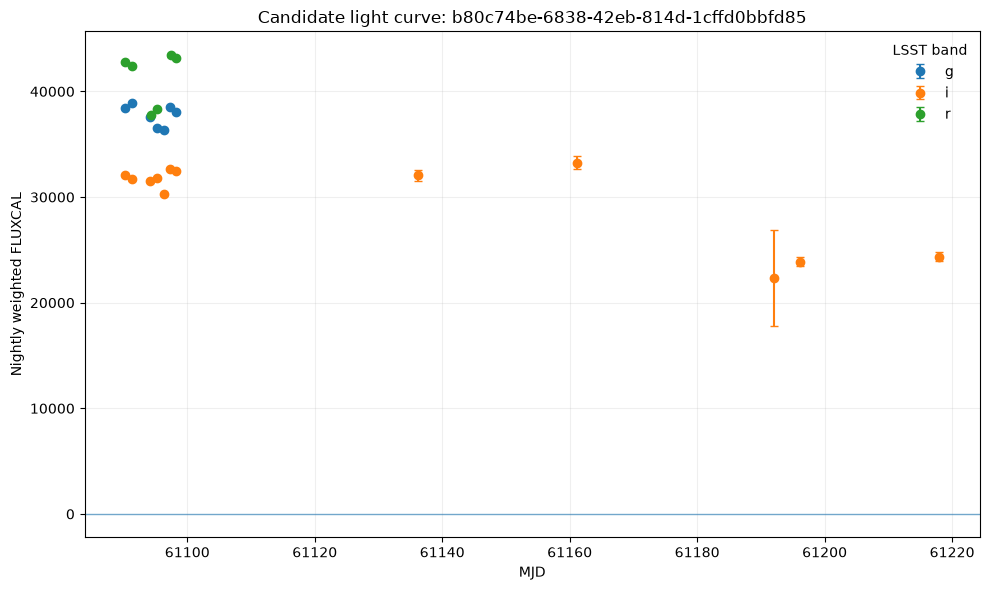


Rank 7: b7f4b026-6b06-494e-9737-a02df930e7de
N_POS=57, N_POS_NIGHTS=31, N_POS_BANDS=6, PEAK_SNR=768.5, AMPLITUDE=237579.8


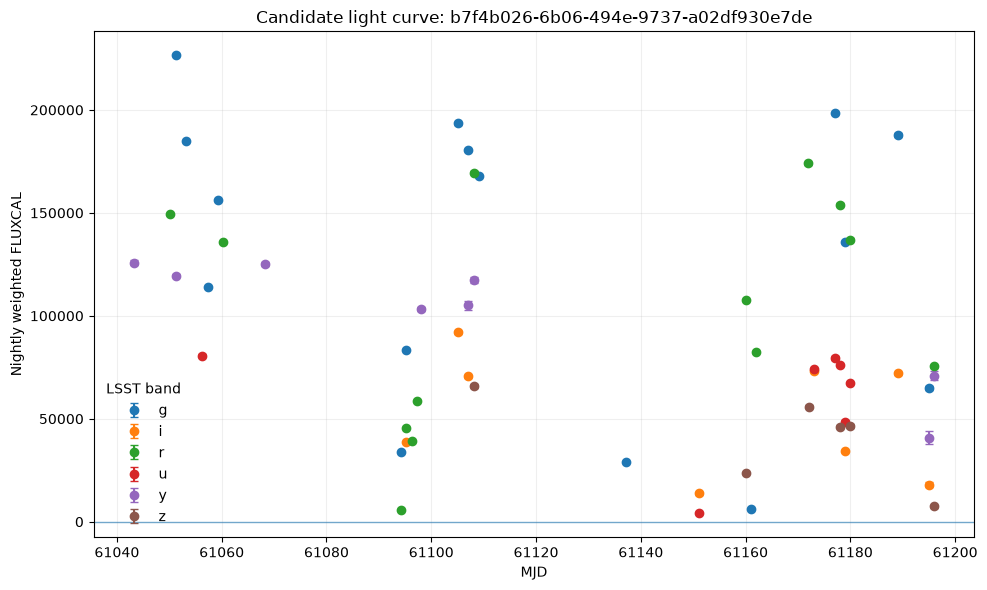


Rank 8: 5c0a0944-be92-489a-b4bc-50d0f57bc816
N_POS=105, N_POS_NIGHTS=40, N_POS_BANDS=6, PEAK_SNR=660.8, AMPLITUDE=15857.0


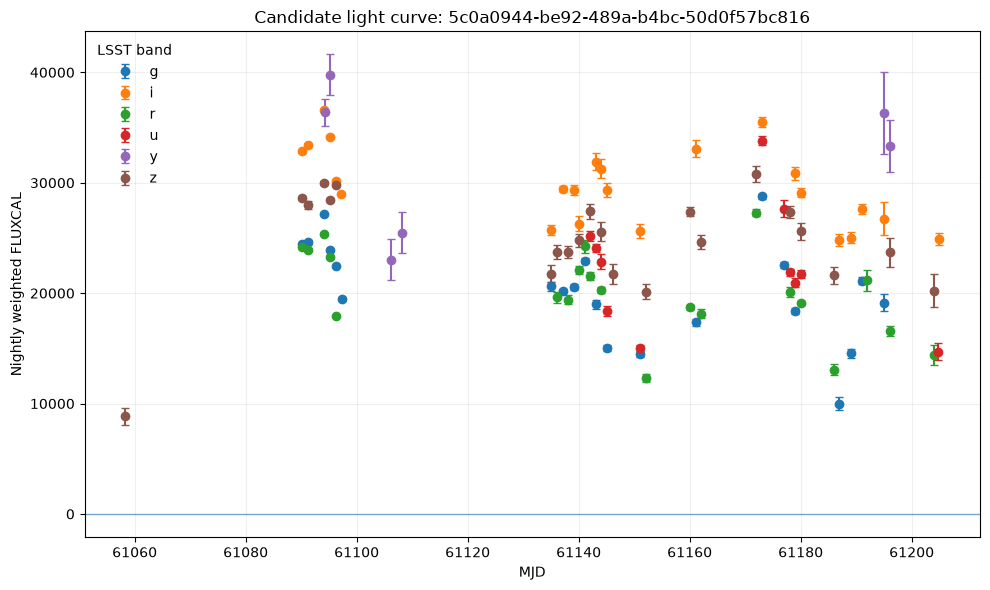


Rank 9: 75c6e247-f802-4836-a290-aad3829569df
N_POS=11, N_POS_NIGHTS=4, N_POS_BANDS=3, PEAK_SNR=626.7, AMPLITUDE=165421.0


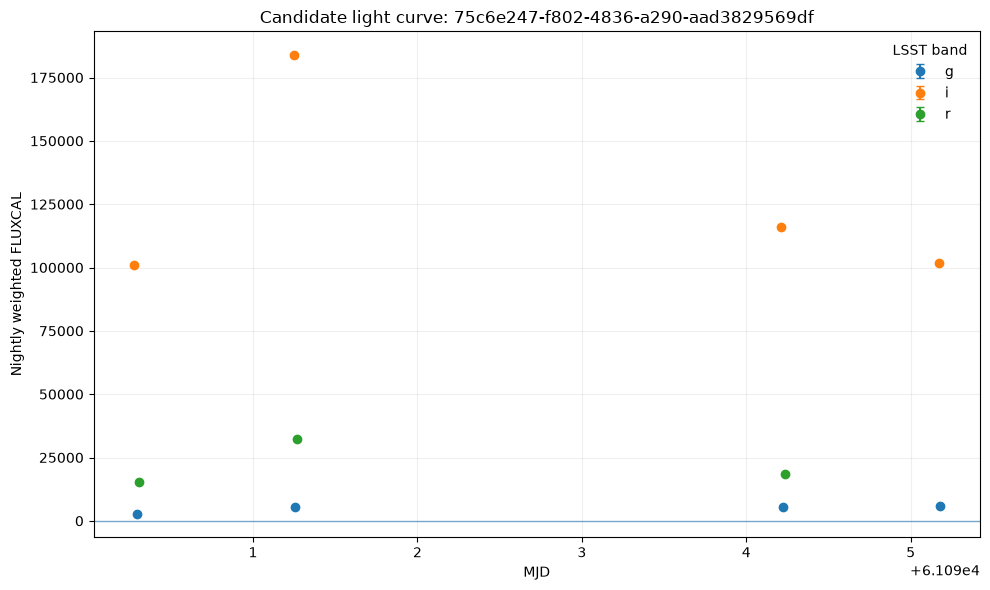


Rank 10: 33828df4-6b78-480d-82a9-71bab6d991a8
N_POS=52, N_POS_NIGHTS=27, N_POS_BANDS=6, PEAK_SNR=591.5, AMPLITUDE=2453.5


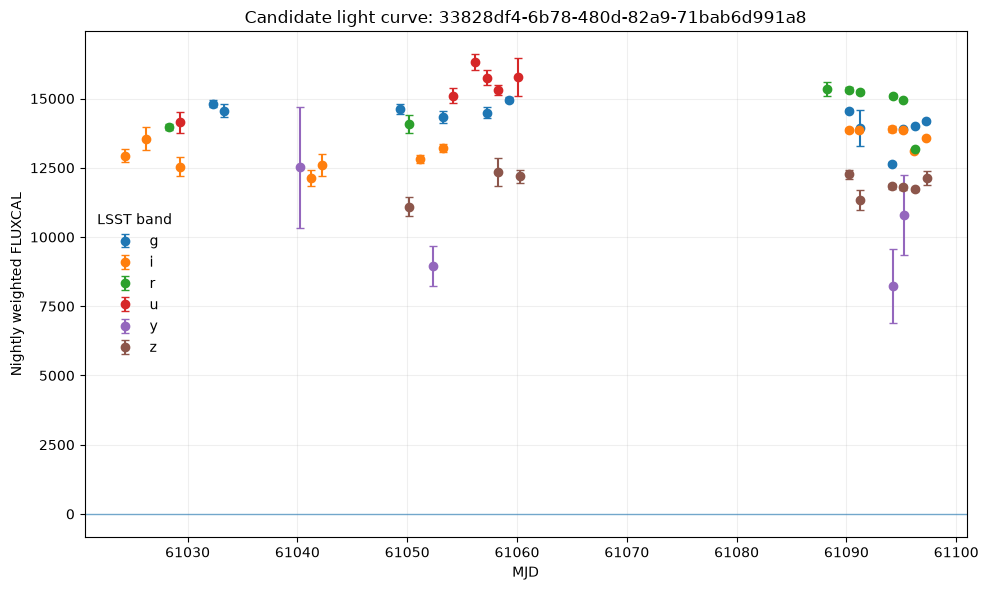


Rank 11: 75e3d45b-a980-4cb0-8b0b-be5ea81ecf00
N_POS=5, N_POS_NIGHTS=4, N_POS_BANDS=2, PEAK_SNR=589.6, AMPLITUDE=252671.3


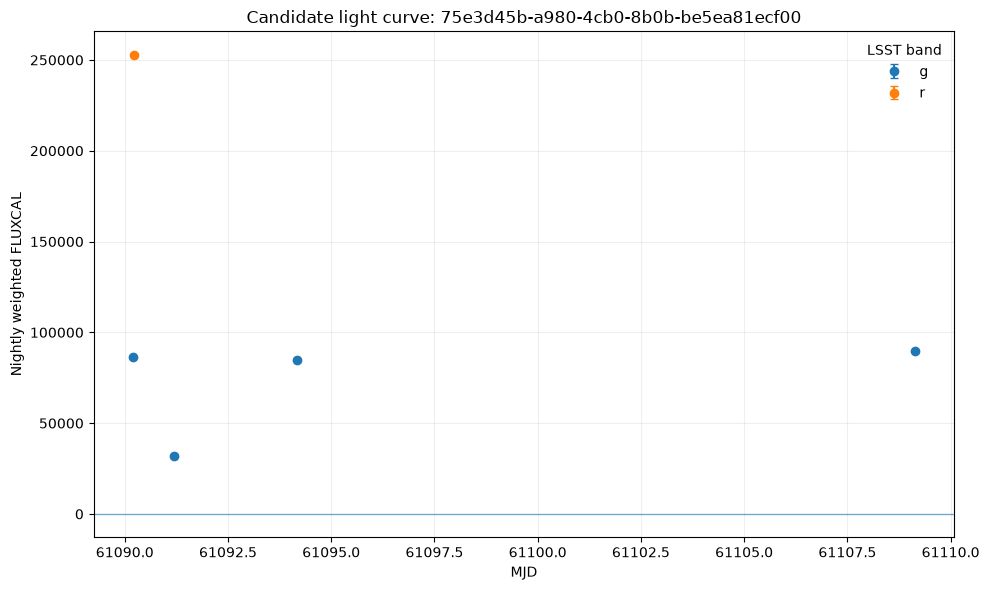


Rank 12: 8a1d3b39-6646-4fa1-9758-655cea2a4116
N_POS=27, N_POS_NIGHTS=7, N_POS_BANDS=5, PEAK_SNR=513.1, AMPLITUDE=3573.7


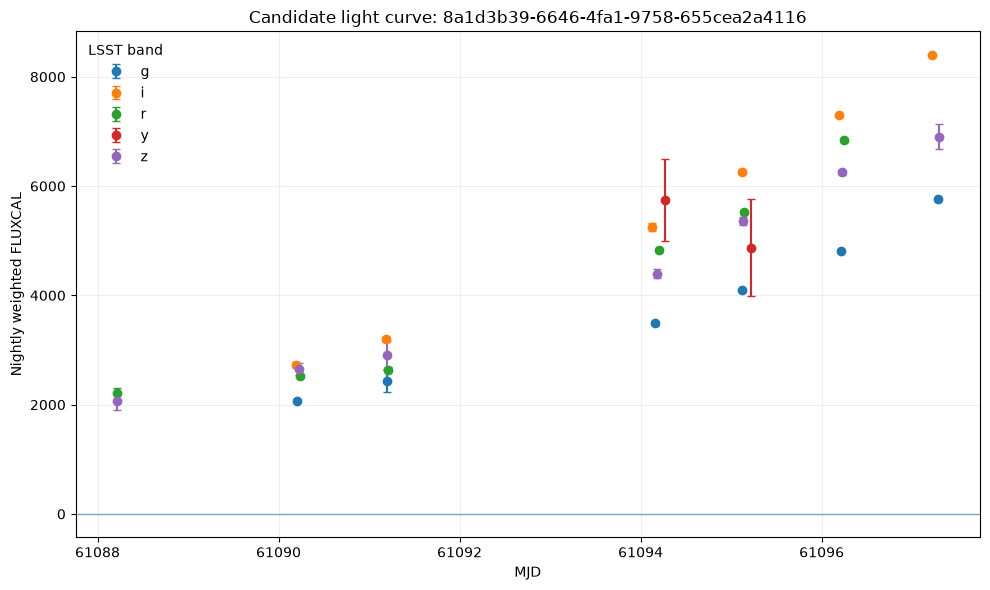


Rank 13: bd33bca9-f500-45cd-ab91-6f4f4238cbb6
N_POS=88, N_POS_NIGHTS=36, N_POS_BANDS=6, PEAK_SNR=495.2, AMPLITUDE=4789.0


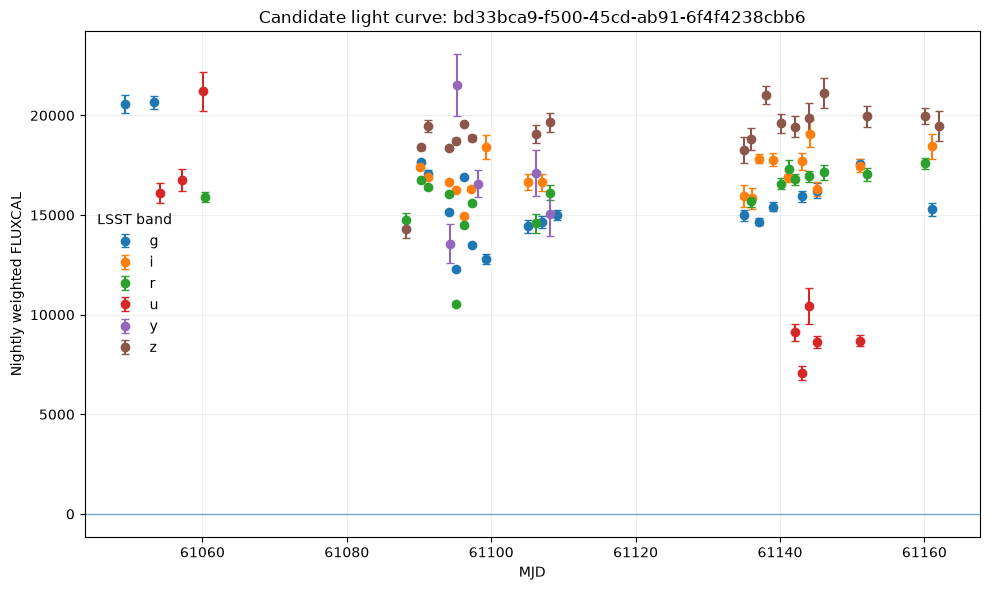


Rank 14: 668d78ca-8052-4c7d-91cf-f5cb65b383c3
N_POS=106, N_POS_NIGHTS=48, N_POS_BANDS=6, PEAK_SNR=485.2, AMPLITUDE=6530.6


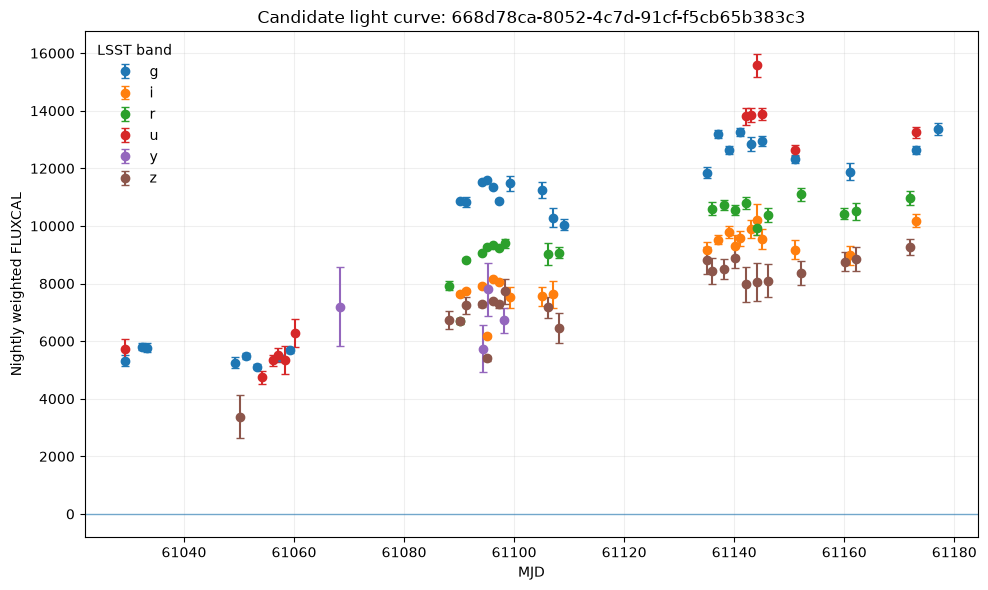


Rank 15: fa7e6f64-6697-445c-8bf8-a27f193035c4
N_POS=6, N_POS_NIGHTS=4, N_POS_BANDS=2, PEAK_SNR=460.9, AMPLITUDE=209156.0


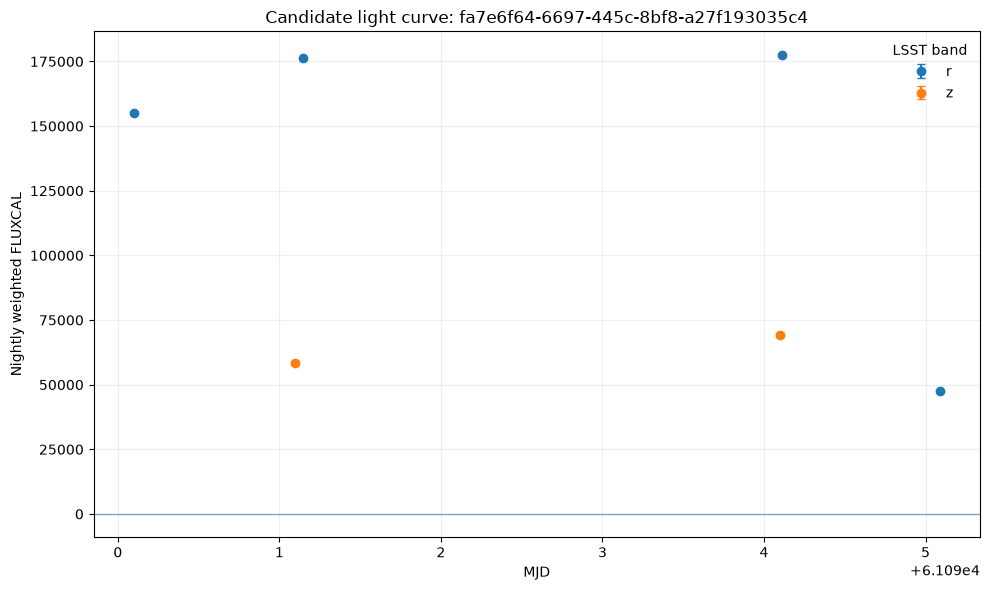


Rank 16: 0a8ea188-f02d-41cd-9fc1-65e979b3c74e
N_POS=15, N_POS_NIGHTS=8, N_POS_BANDS=4, PEAK_SNR=449.7, AMPLITUDE=187318.0


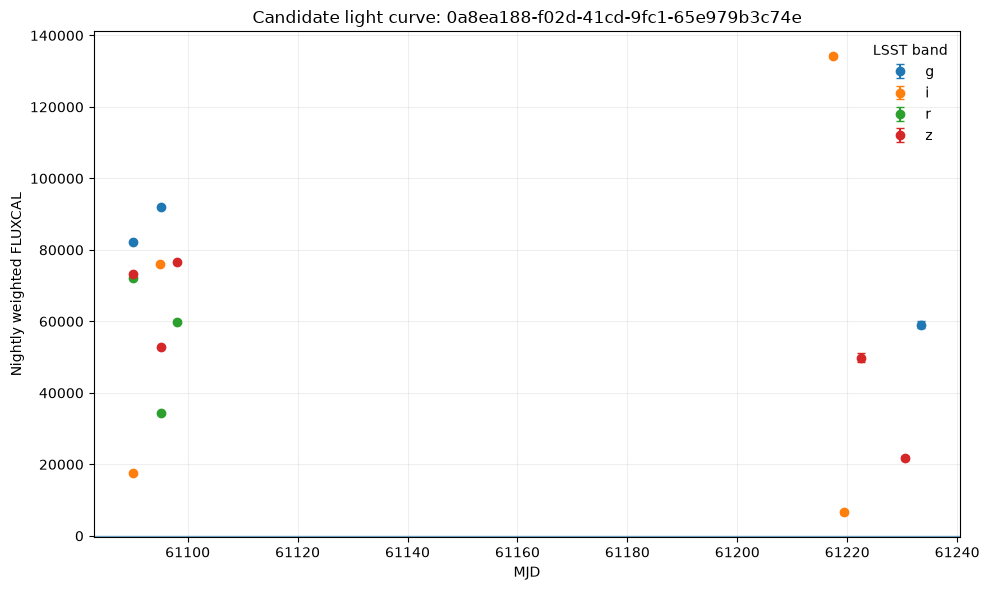


Rank 17: 0046d02c-7800-475c-9faf-42ec4b5819e4
N_POS=35, N_POS_NIGHTS=14, N_POS_BANDS=6, PEAK_SNR=401.9, AMPLITUDE=4432.6


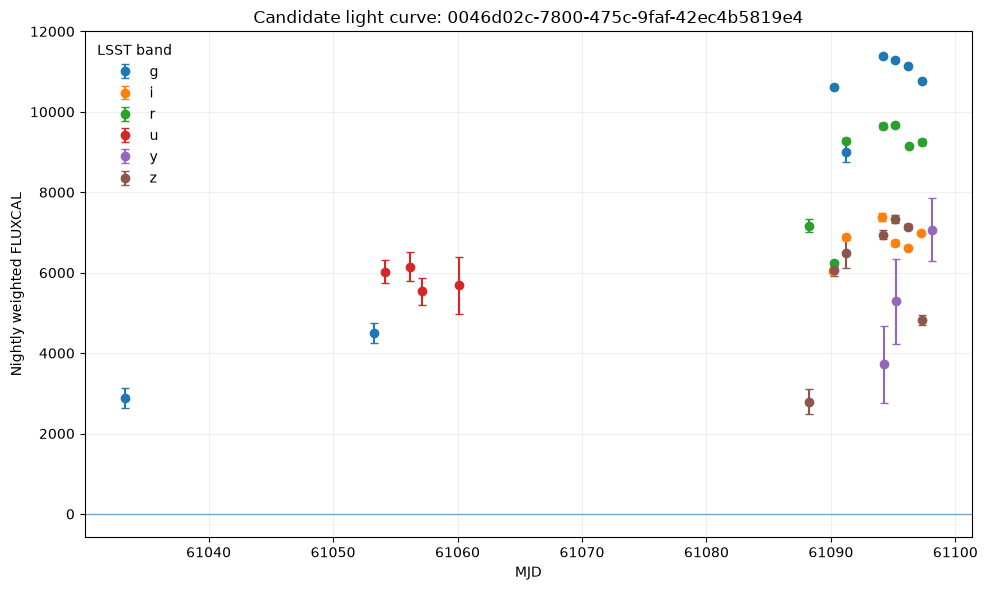


Rank 18: 33685c53-d100-44fd-962e-8d3a95eaed1b
N_POS=63, N_POS_NIGHTS=29, N_POS_BANDS=5, PEAK_SNR=400.0, AMPLITUDE=5712.2


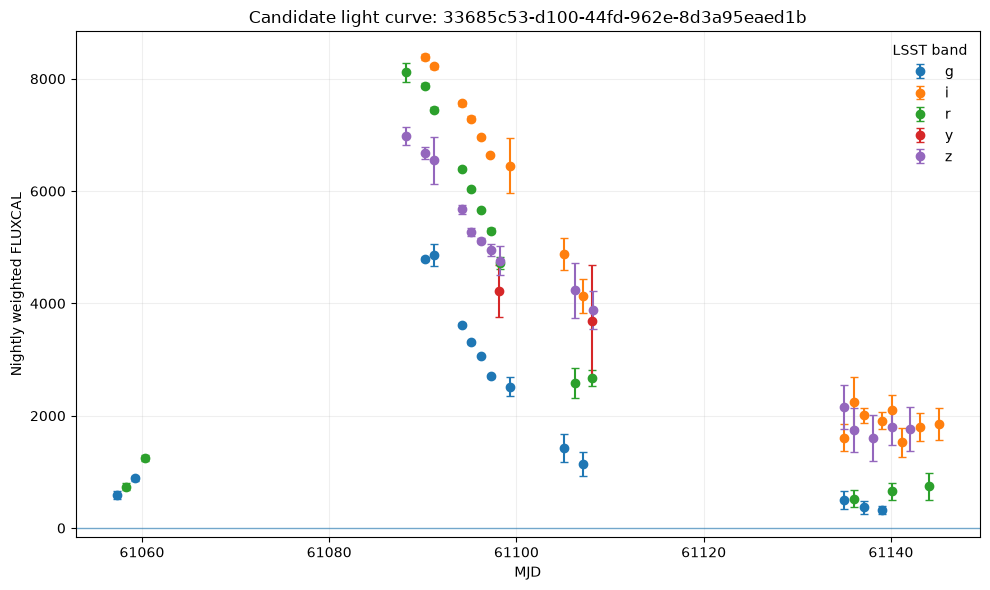


Rank 19: 14808251-4337-4232-8d92-f72b4ab22206
N_POS=58, N_POS_NIGHTS=4, N_POS_BANDS=2, PEAK_SNR=377.7, AMPLITUDE=520094.0


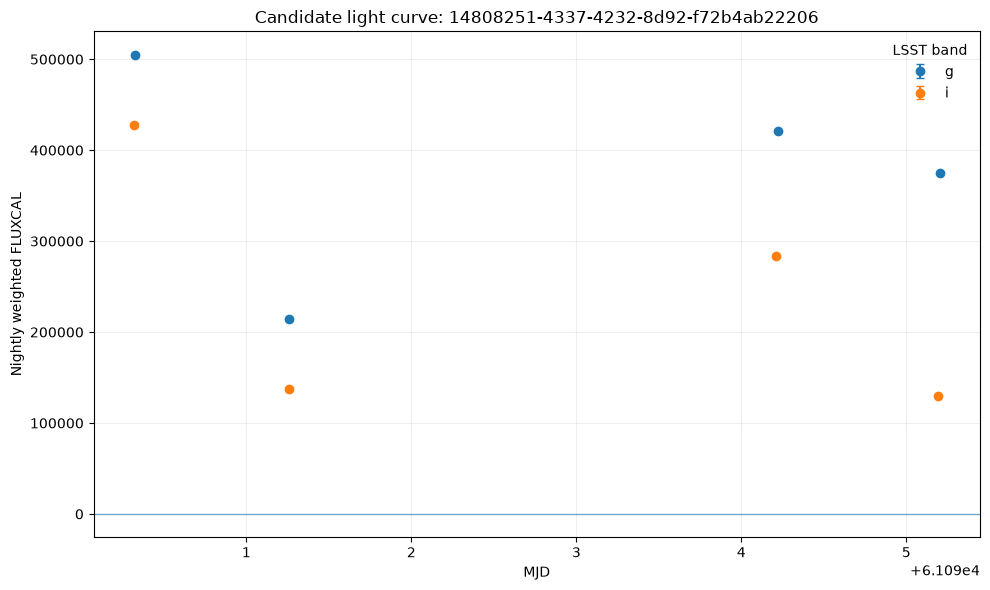


Rank 20: 8a203f90-a00e-4440-b458-57b5ea7ea727
N_POS=85, N_POS_NIGHTS=38, N_POS_BANDS=6, PEAK_SNR=370.0, AMPLITUDE=3309.8


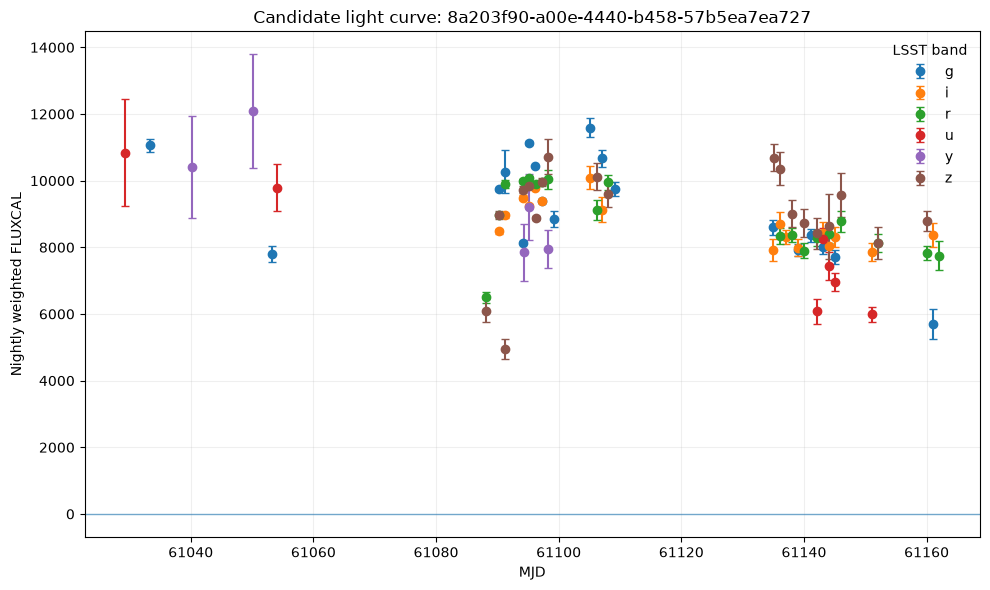

In [33]:
for rank in range(min(20, len(transient_candidates))):
    candidate = transient_candidates.iloc[rank]

    idx = int(candidate["HEAD_INDEX"])
    snid = candidate["SNID"]

    lc = get_lightcurve(head_data[idx])

    nightly = make_positive_nightly_lightcurve(
        lc,
        min_snr=3.0,
    )

    print(f"\nRank {rank + 1}: {snid}")
    print(
        f"N_POS={candidate['N_POS']}, "
        f"N_POS_NIGHTS={candidate['N_POS_NIGHTS']}, "
        f"N_POS_BANDS={candidate['N_POS_BANDS']}, "
        f"PEAK_SNR={candidate['PEAK_SNR']:.1f}, "
        f"AMPLITUDE={candidate['AMPLITUDE']:.1f}"
    )

    plot_nightly_lightcurve(nightly, snid)


### Match with Alerce for Cuts

In [37]:
from alerce.core import Alerce
import pandas as pd
import numpy as np
import time

alerce = Alerce()

# Only run ALERCE matching on objects that already passed our alert cuts
alerce_candidates = candidates.copy()

print(f"Objects to query: {len(alerce_candidates):,}")

Objects to query: 2,278


In [38]:
def match_lsst_object(ra, dec, snid, search_radius_arcsec=1.0):
    """
    Find the nearest ALERCE LSST object to a SNANA object.
    Returns (oid, separation_arcsec), or None if no match.
    """
    try:
        cands = alerce.query_objects(
            survey="lsst",
            ra=float(ra),
            dec=float(dec),
            radius=search_radius_arcsec,
            format="pandas",
        )
    except Exception as e:
        print(f"{snid}: object query failed: {e}")
        return None

    if cands is None or cands.empty:
        return None

    # ALERCE query is centred on our coordinate, so take the closest candidate
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    source = SkyCoord(float(ra) * u.deg, float(dec) * u.deg)
    alerce_coords = SkyCoord(
        cands["meanra"].astype(float).values * u.deg,
        cands["meandec"].astype(float).values * u.deg,
    )

    sep = source.separation(alerce_coords).arcsec
    i = np.argmin(sep)

    return cands.iloc[i]["oid"], sep[i]

In [39]:
# Build lookup table from the original HEAD data
head_coords = pd.DataFrame({
    "SNID": [str(x) for x in head_data["SNID"]],
    "RA": np.asarray(head_data["RA"], dtype=float),
    "DEC": np.asarray(head_data["DEC"], dtype=float),
})

# Make sure candidate SNIDs have same type
alerce_candidates = candidates.copy()
alerce_candidates["SNID"] = alerce_candidates["SNID"].astype(str)

# Add coordinates
alerce_candidates = alerce_candidates.merge(
    head_coords,
    on="SNID",
    how="left",
    validate="one_to_one",
)

print(alerce_candidates[["SNID", "RA", "DEC"]].head())
print("Missing RA:", alerce_candidates["RA"].isna().sum())
print("Missing DEC:", alerce_candidates["DEC"].isna().sum())

                                   SNID          RA       DEC
0  a3f7ac57-349f-44a8-bc11-dd101444ace1  150.661262  1.660136
1  14c2643a-48e6-4bae-a2e0-20b41cdbefaf  149.272749  2.691964
2  23af3b06-9c88-44d8-a6c2-39a062326bbf  150.885265  0.794140
3  1ee3563b-4982-460e-8a6f-f609d50f62c9  150.683137  2.574636
4  28ea9e0f-cd86-4b7e-becb-9970dd7a006c  150.788346  2.343982
Missing RA: 0
Missing DEC: 0


In [41]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from alerce.core import Alerce
import threading
import numpy as np
import pandas as pd
import time


# -----------------------------------
# One ALeRCE client per worker thread
# -----------------------------------

thread_local = threading.local()


def get_alerce_client():
    if not hasattr(thread_local, "alerce"):
        thread_local.alerce = Alerce()

    return thread_local.alerce


# -----------------------------------
# Process one object
# -----------------------------------

def process_alerce_candidate(row):

    client = get_alerce_client()

    snid = str(row["SNID"])

    try:

        # Find corresponding ALeRCE LSST object
        m = match_lsst_object(
            row["RA"],
            row["DEC"],
            snid,
            search_radius_arcsec=1.0,
        )

        if m is None:
            return {
                "SNID": snid,
                "oid": None,
                "sep_arcsec": np.nan,
                "p_SN": np.nan,
                "classifier_version": None,
            }

        oid, sep = m


        # Get ALeRCE probabilities
        probs = client.query_probabilities(
            oid=oid,
            survey="lsst",
            format="pandas",
        )


        if probs is None or probs.empty:
            return {
                "SNID": snid,
                "oid": oid,
                "sep_arcsec": sep,
                "p_SN": np.nan,
                "classifier_version": None,
            }


        # Most recent classifier
        latest_version = probs["classifier_version"].max()

        latest = probs[
            probs["classifier_version"] == latest_version
        ]

        sn_row = latest[
            latest["class_name"] == "SN"
        ]


        p_sn = (
            sn_row["probability"].iloc[0]
            if len(sn_row)
            else np.nan
        )


        return {
            "SNID": snid,
            "oid": oid,
            "sep_arcsec": sep,
            "p_SN": p_sn,
            "classifier_version": latest_version,
        }


    except Exception as e:

        return {
            "SNID": snid,
            "oid": None,
            "sep_arcsec": np.nan,
            "p_SN": np.nan,
            "classifier_version": f"ERROR: {e}",
        }


# -----------------------------------
# Run in parallel
# -----------------------------------

N_WORKERS = 2

rows = [
    row
    for _, row in alerce_candidates.iterrows()
]

match_rows = []

t0 = time.perf_counter()


with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:

    futures = [
        pool.submit(process_alerce_candidate, row)
        for row in rows
    ]


    for i, future in enumerate(
        as_completed(futures),
        start=1,
    ):

        result = future.result()

        match_rows.append(result)


        if i % 100 == 0 or i == len(rows):

            elapsed = time.perf_counter() - t0

            rate = elapsed / i

            remaining = rate * (len(rows) - i)

            print(
                f"{i}/{len(rows)} done | "
                f"{rate:.2f} s/object | "
                f"~{remaining / 60:.1f} min remaining"
            )


# -----------------------------------
# Final dataframe
# -----------------------------------

alerce_match = pd.DataFrame(match_rows)

alerce_match.head()

100/2278 done | 1.10 s/object | ~40.0 min remaining
200/2278 done | 1.09 s/object | ~37.8 min remaining
300/2278 done | 1.09 s/object | ~35.8 min remaining
400/2278 done | 1.08 s/object | ~33.9 min remaining
500/2278 done | 1.08 s/object | ~32.0 min remaining
600/2278 done | 1.08 s/object | ~30.2 min remaining
700/2278 done | 1.08 s/object | ~28.4 min remaining
800/2278 done | 1.08 s/object | ~26.6 min remaining
900/2278 done | 1.08 s/object | ~24.8 min remaining
1000/2278 done | 1.08 s/object | ~23.0 min remaining
1100/2278 done | 1.08 s/object | ~21.2 min remaining
1200/2278 done | 1.08 s/object | ~19.4 min remaining
1300/2278 done | 1.08 s/object | ~17.5 min remaining
1400/2278 done | 1.08 s/object | ~15.7 min remaining
1500/2278 done | 1.08 s/object | ~14.0 min remaining
1600/2278 done | 1.08 s/object | ~12.2 min remaining
1700/2278 done | 1.08 s/object | ~10.4 min remaining
1800/2278 done | 1.10 s/object | ~8.8 min remaining
1900/2278 done | 1.16 s/object | ~7.3 min remaining
2000

KeyboardInterrupt: 

In [42]:
len(match_rows)

2277

In [46]:
alerce_match = pd.DataFrame(match_rows)

alerce_match.to_csv(
    "alerce_match_partial.csv",
    index=False
)

print(f"Saved {len(alerce_match)} rows")

Saved 2277 rows


In [47]:
test = pd.read_csv("alerce_match_partial.csv")

print("Saved rows:", len(test))
print(test.head())

Saved rows: 2277
                                   SNID           oid  sep_arcsec      p_SN  \
0  a3f7ac57-349f-44a8-bc11-dd101444ace1  3.138535e+17    0.004703  0.002284   
1  14c2643a-48e6-4bae-a2e0-20b41cdbefaf  3.138535e+17    0.005537  0.001532   
2  1ee3563b-4982-460e-8a6f-f609d50f62c9  3.138710e+17    0.007144  0.019884   
3  23af3b06-9c88-44d8-a6c2-39a062326bbf  3.138535e+17    0.006170  0.003808   
4  28ea9e0f-cd86-4b7e-becb-9970dd7a006c  3.138754e+17    0.019361  0.020532   

   classifier_version  
0               202.0  
1               202.0  
2               202.0  
3               202.0  
4               202.0  


In [48]:
done_snids = set(alerce_match["SNID"].astype(str))

missing = alerce_candidates[
    ~alerce_candidates["SNID"].astype(str).isin(done_snids)
].copy()

print("Missing:", len(missing))

missing[["SNID", "RA", "DEC"]]

Missing: 1


,SNID,RA,DEC
1760,0055b614-1db7-4922-9d65-4c83331f46e7,148.98608,1.252375


In [49]:
missing_results = []

for _, row in missing.iterrows():

    result = process_alerce_candidate(row)

    missing_results.append(result)

missing_results

[{'SNID': '0055b614-1db7-4922-9d65-4c83331f46e7',
  'oid': np.int64(313998569868623915),
  'sep_arcsec': np.float64(0.2904125556728216),
  'p_SN': np.float64(0.006909159),
  'classifier_version': np.int64(202)}]

In [50]:
alerce_match = pd.concat(
    [
        alerce_match,
        pd.DataFrame(missing_results)
    ],
    ignore_index=True
)

print(len(alerce_match))

2278


In [51]:
alerce_match.to_csv(
    "alerce_match.csv",
    index=False
)

print(f"Final file saved: {len(alerce_match)} objects")

Final file saved: 2278 objects


### Alerce Cuts

In [52]:
alerce_match = pd.read_csv("alerce_match.csv")

alerce_cut = alerce_match[
    alerce_match["p_SN"] > 0.5
].copy()

print(f"Passed cut: {len(alerce_cut)}/{len(alerce_match)}")
alerce_cut.head()

Passed cut: 28/2278


,SNID,oid,sep_arcsec,p_SN,classifier_version
22,dbce04ab-1a55-4d43-abb2-b24a53e4fb2a,3.137610e+17,0.001921,0.760744,202.0
96,0075e4a4-4237-4d2b-bed5-3b1715a424bf,1.700285e+17,0.000912,0.523602,202.0
98,66949c7f-8fc9-43c8-9f8f-37e0c05fa4cf,1.700197e+17,0.003380,0.896556,202.0
136,75bd15f4-a980-4ab6-845e-190d3ae5f78f,1.700945e+17,0.001581,0.833545,202.0
141,e5fb7c3e-a353-410e-b73b-e2b2a58c9244,3.136291e+17,0.002803,0.991358,202.0


Found 28 light curves to plot


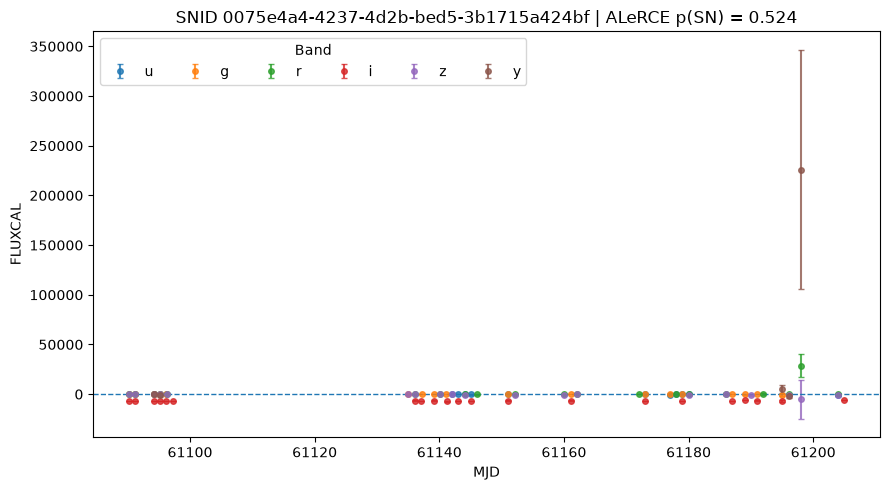

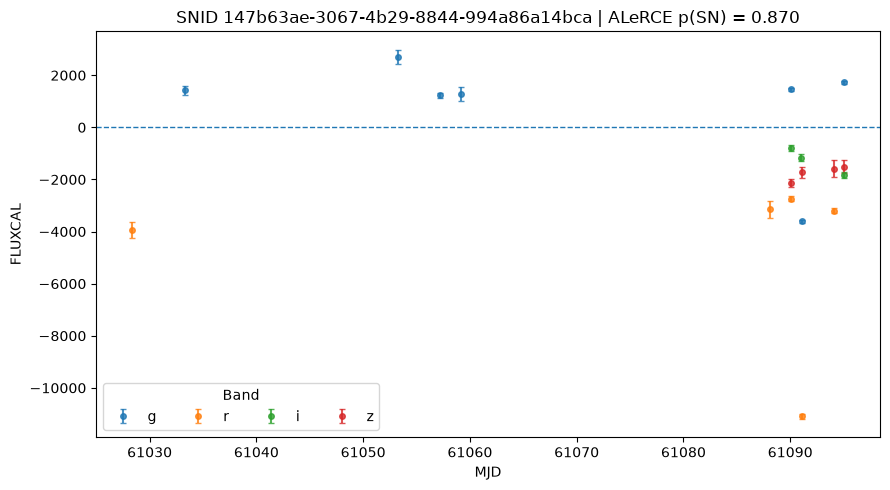

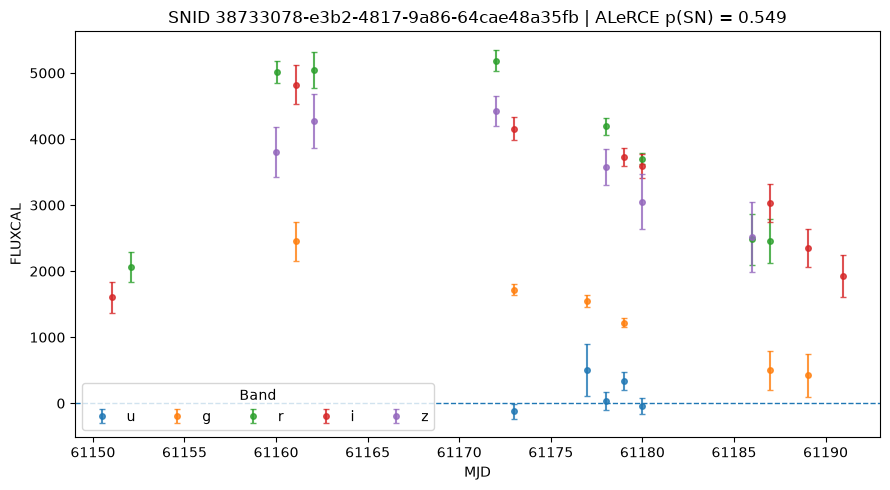

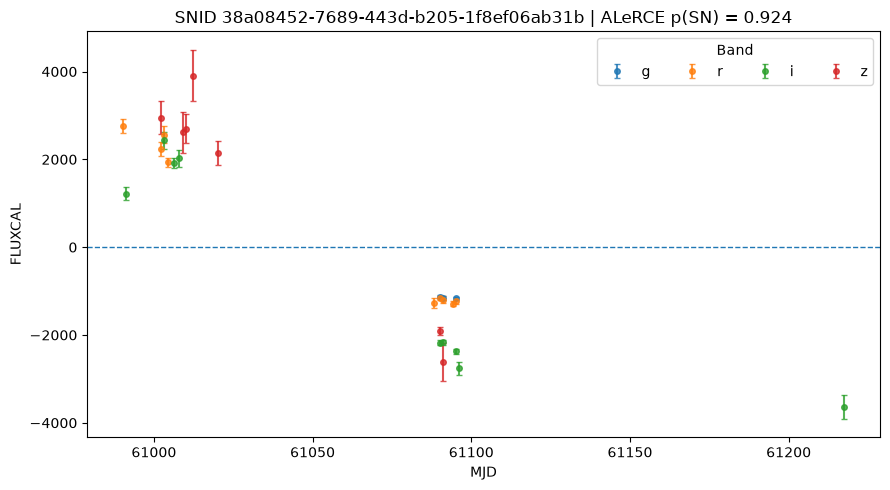

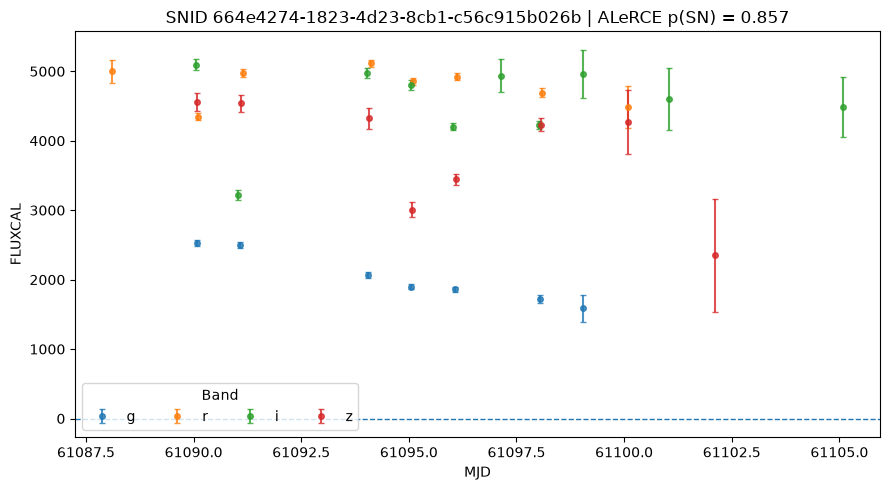

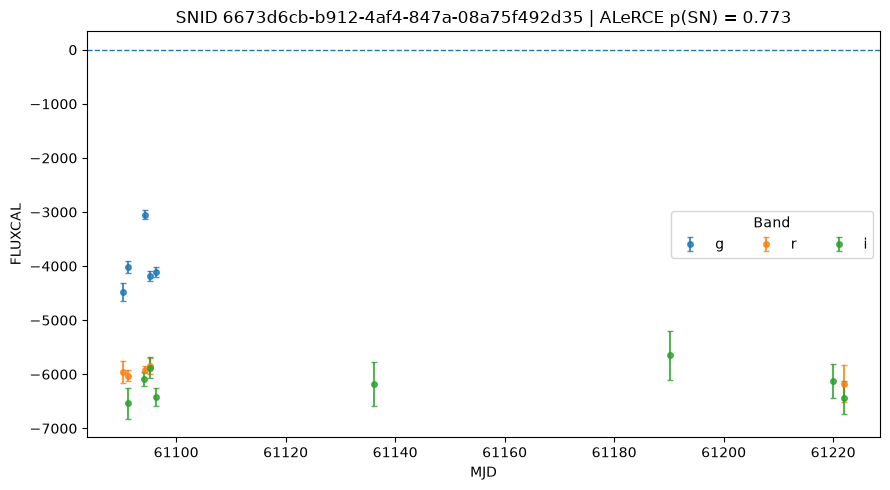

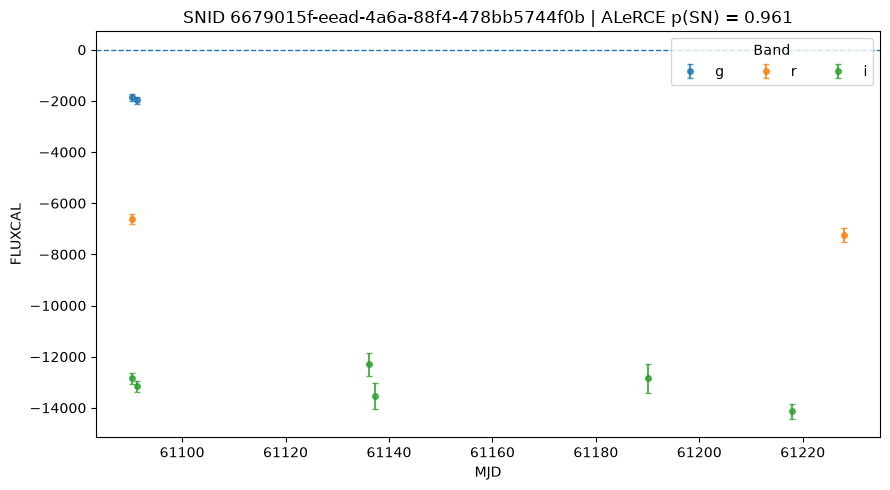

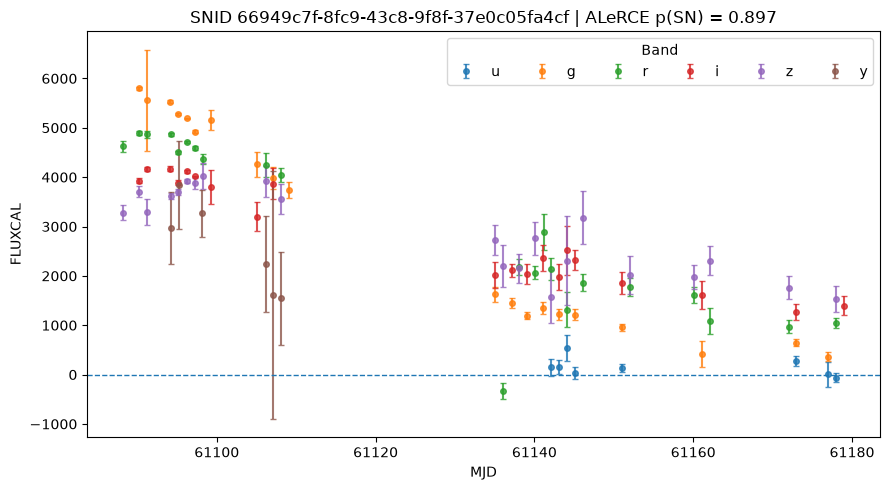

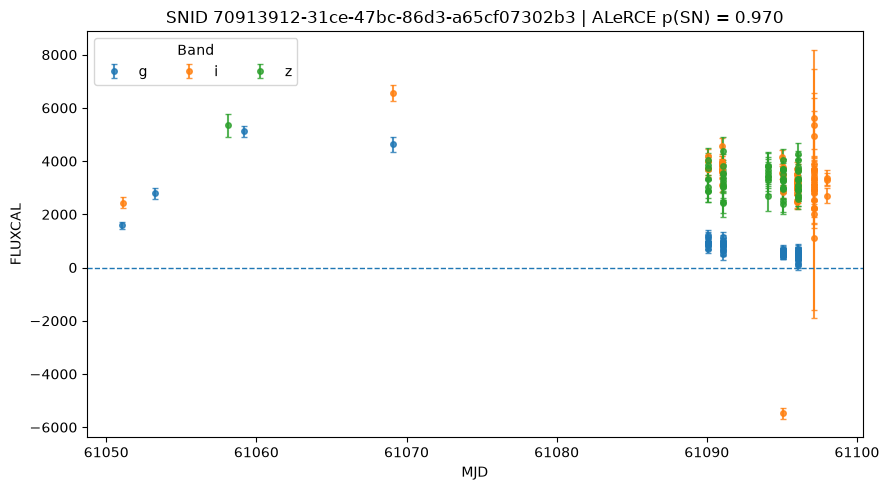

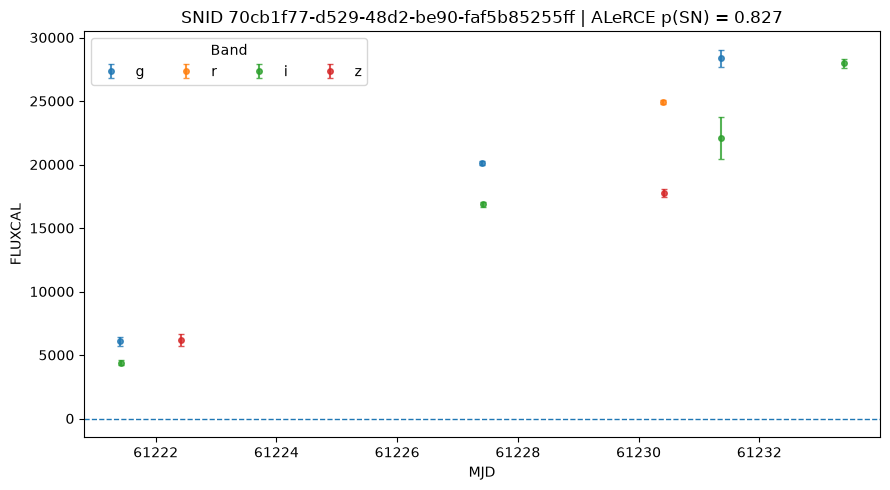

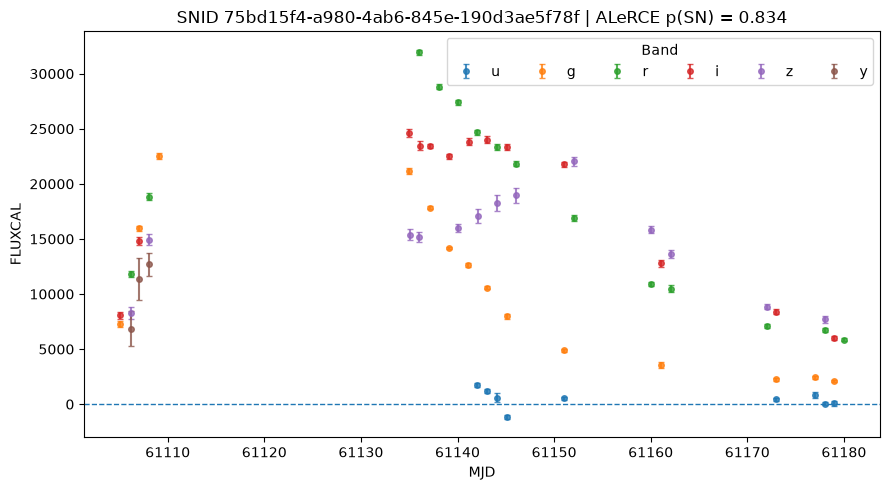

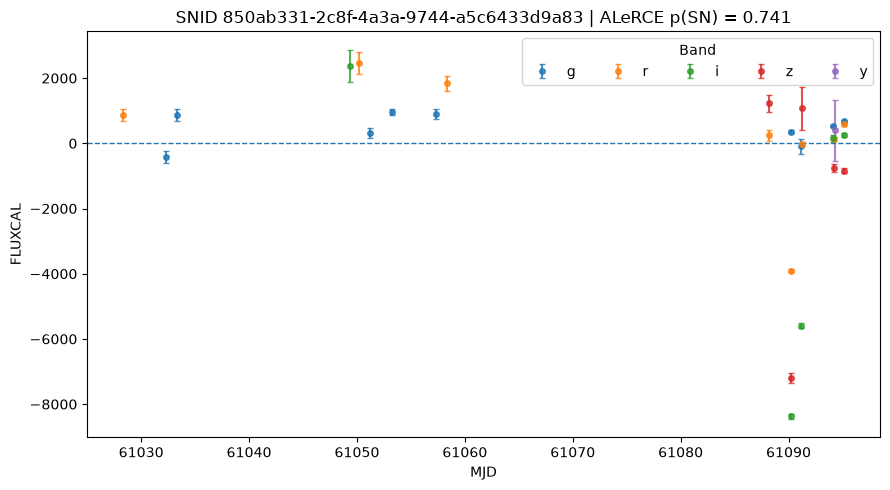

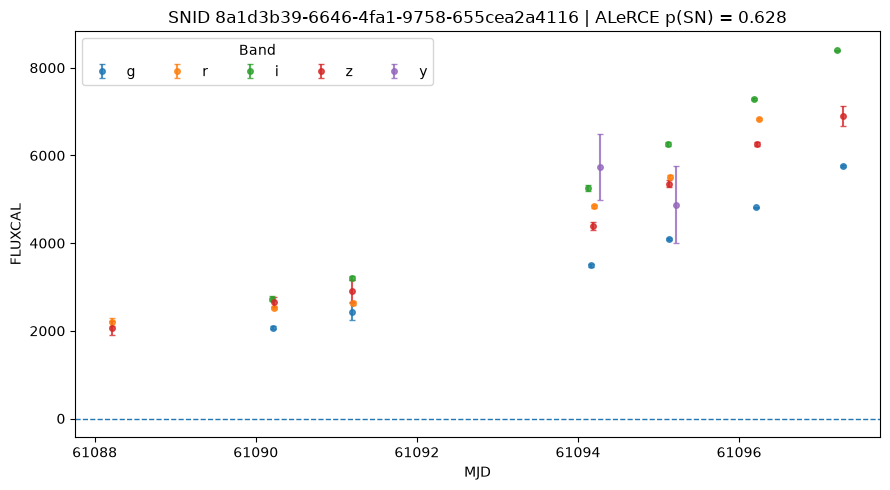

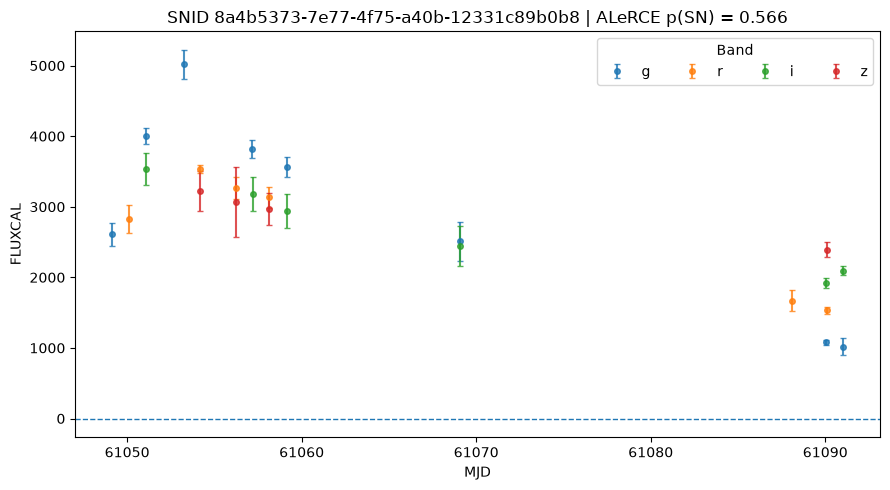

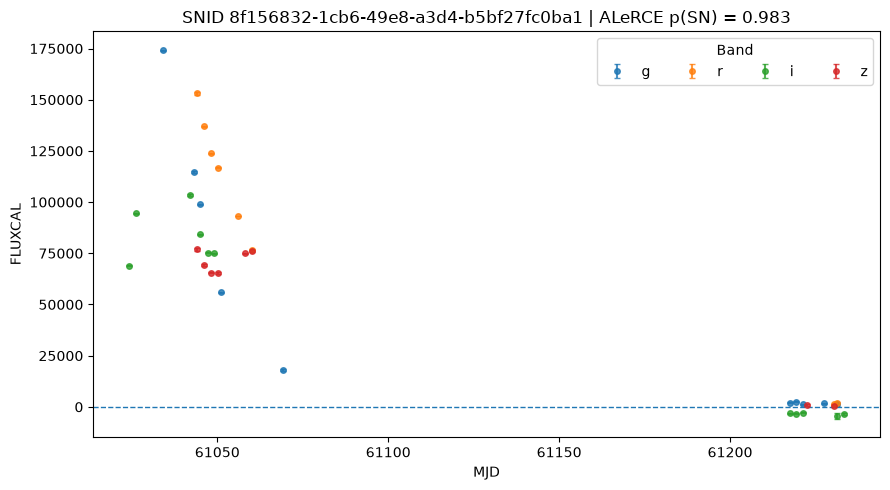

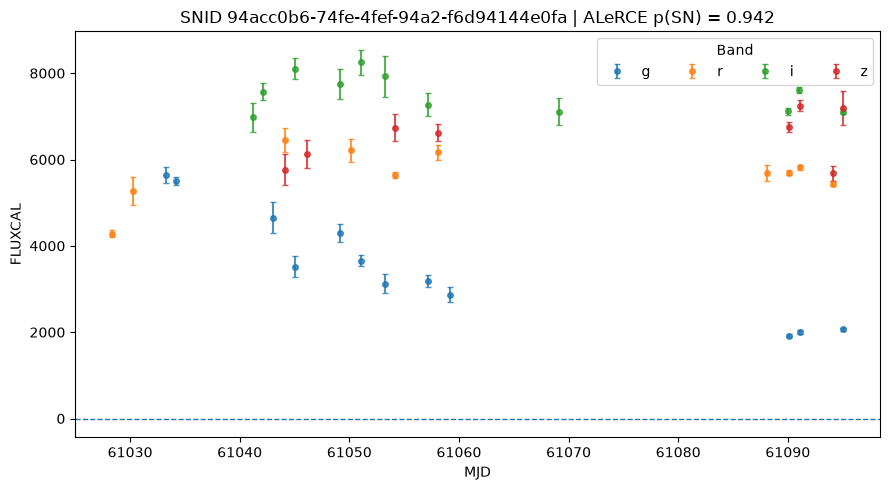

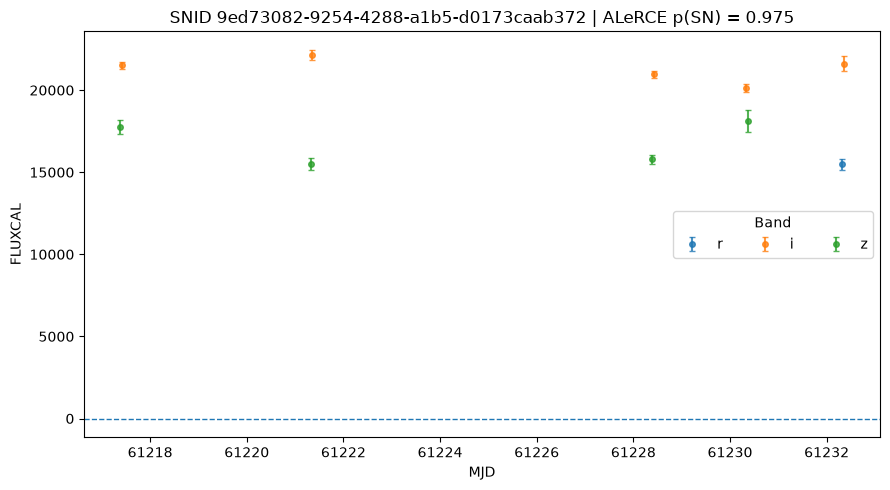

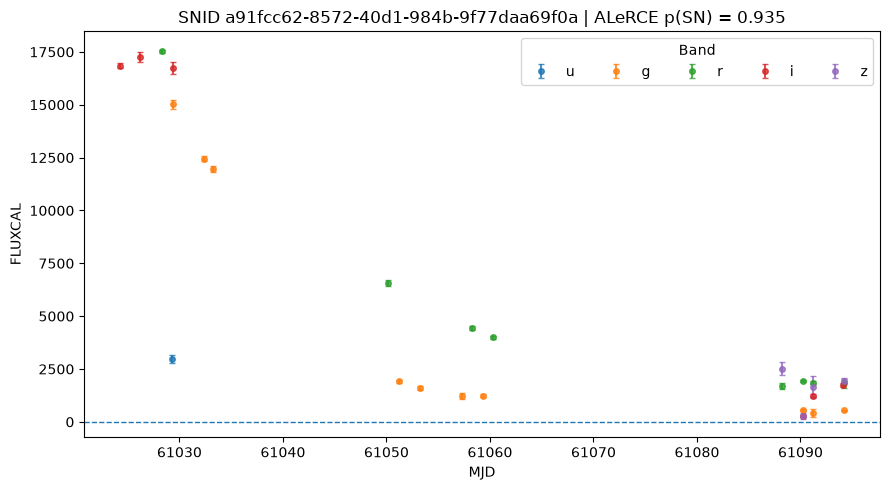

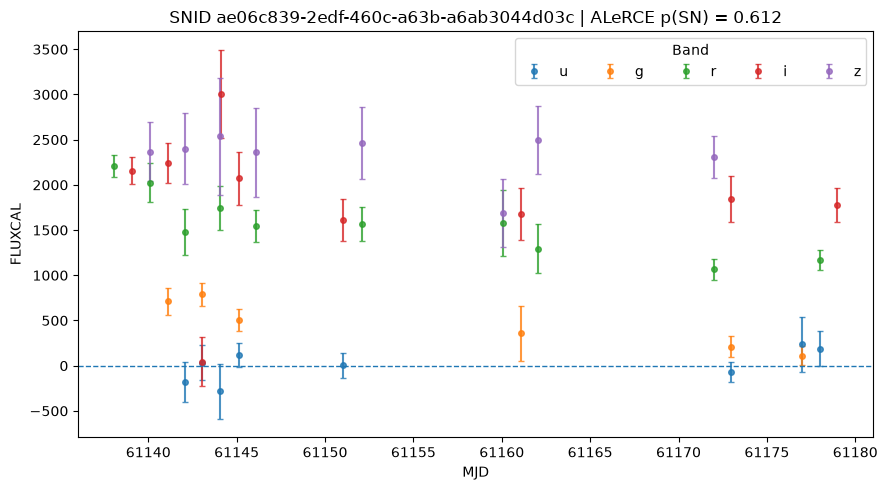

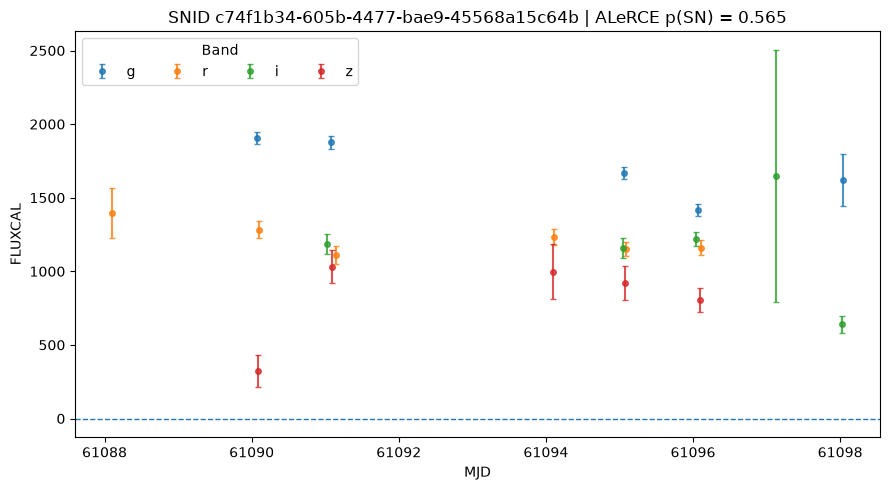

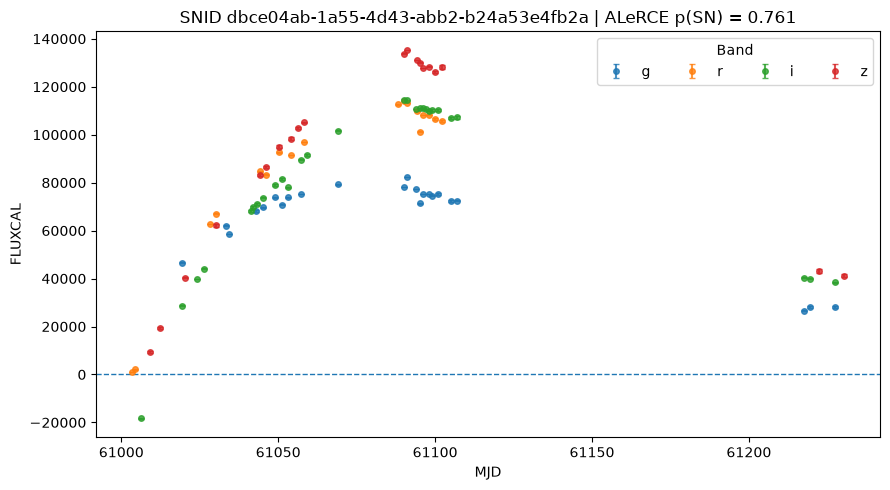

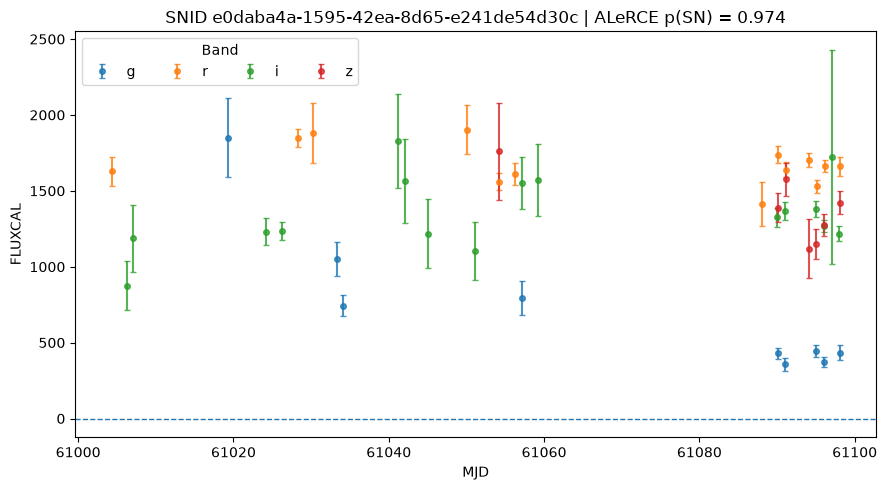

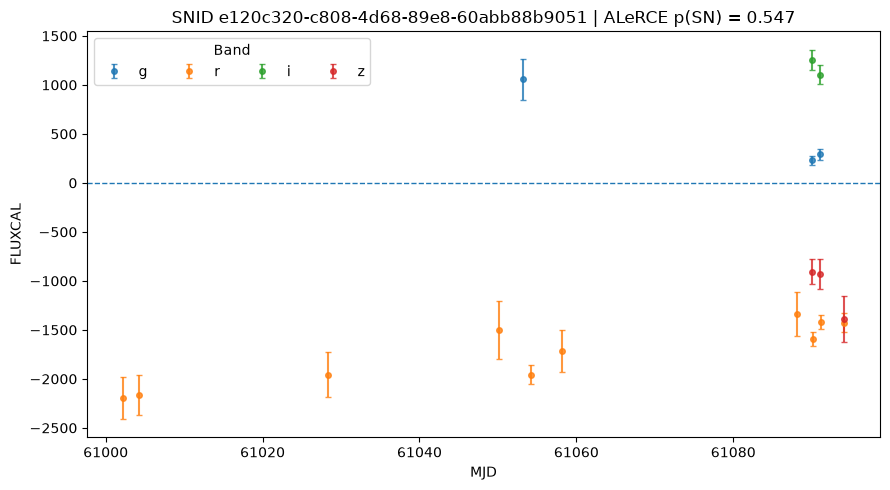

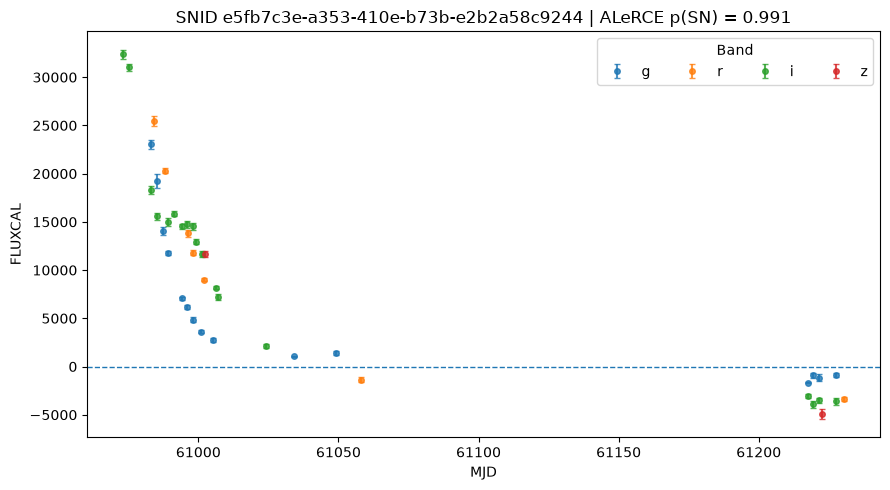

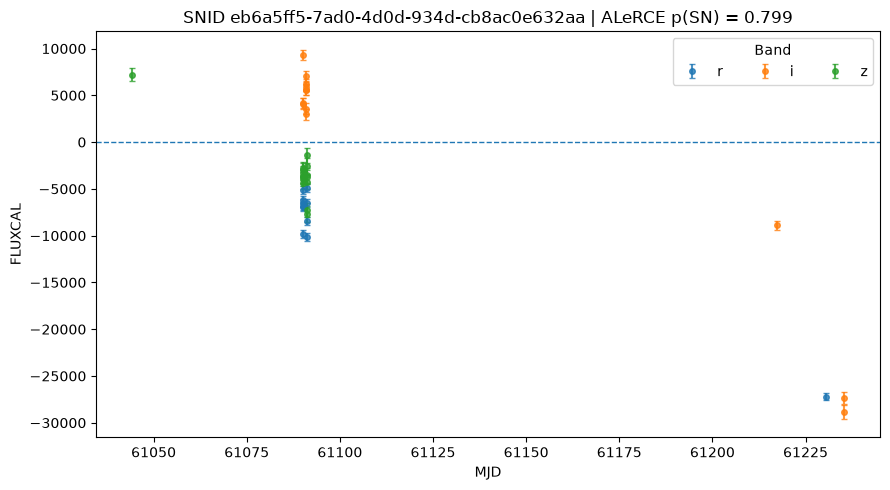

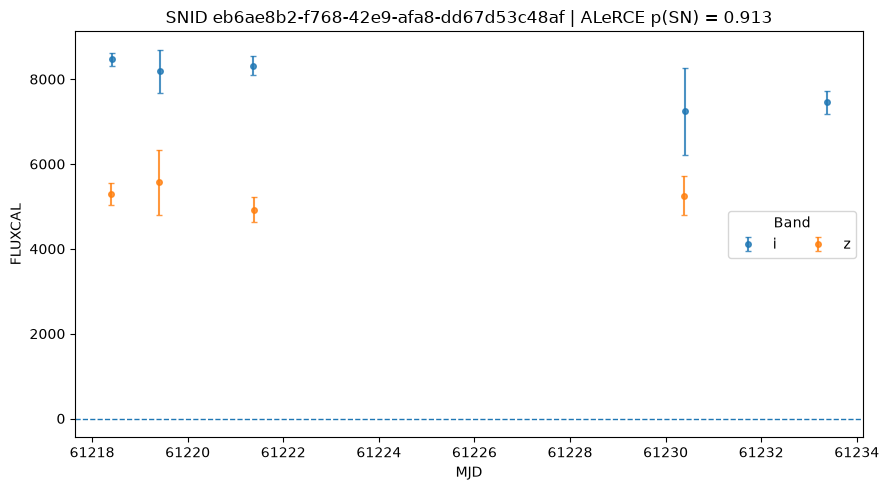

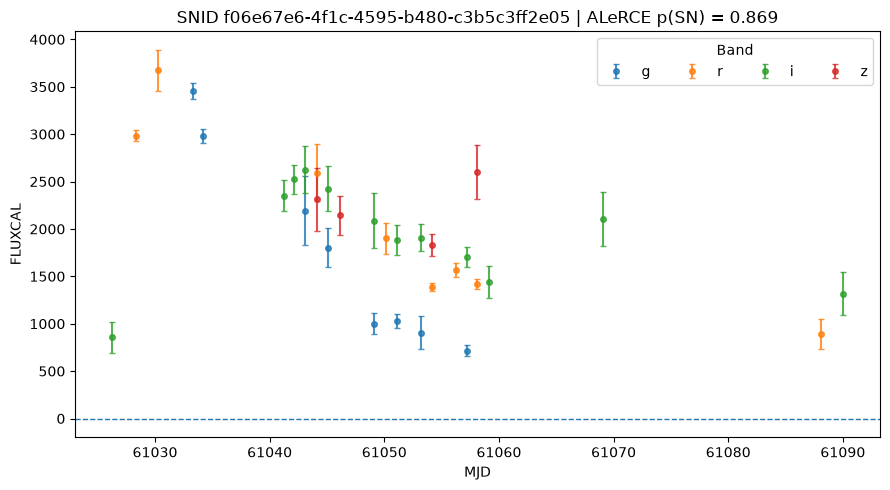

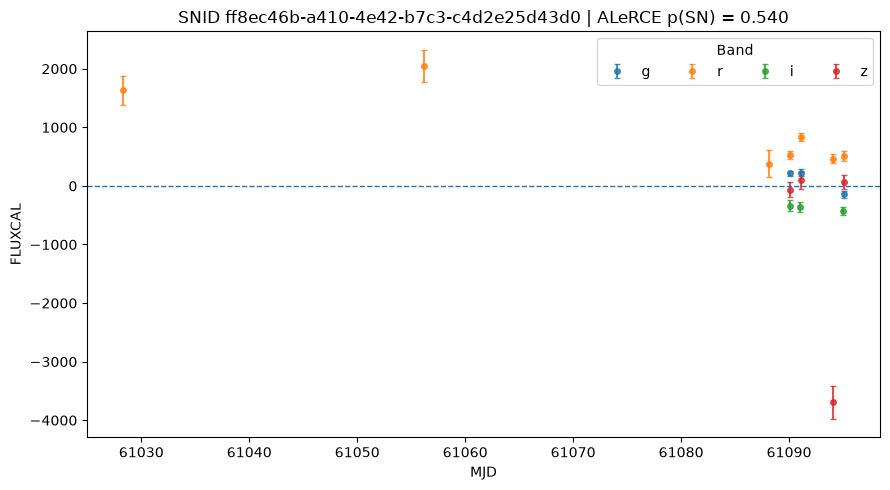

In [53]:
# SNIDs that passed the ALeRCE cut
pass_snids = set(alerce_cut["SNID"].astype(str))

# Match them back to head_data
alerce_head = [
    row for row in head_data
    if clean_snid(row["SNID"]) in pass_snids
]

print(f"Found {len(alerce_head)} light curves to plot")


# LSST bands
bands = ["u", "g", "r", "i", "z", "y"]


for row in alerce_head:

    snid = clean_snid(row["SNID"])

    # Get light curve
    lc = get_lightcurve(row)

    # Apply your photometric quality cuts
    good = photometry_mask(lc)

    mjd = np.asarray(lc["MJD"], dtype=float)
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    band = np.char.strip(
        np.asarray(lc["BAND"]).astype(str)
    )

    plt.figure(figsize=(9, 5))

    for b in bands:

        use = good & (band == b)

        if np.any(use):
            plt.errorbar(
                mjd[use],
                flux[use],
                yerr=fluxerr[use],
                fmt="o",
                ms=4,
                capsize=2,
                label=b,
                alpha=0.8,
            )

    # Get ALeRCE probability for title
    p_sn = alerce_cut.loc[
        alerce_cut["SNID"].astype(str) == snid,
        "p_SN"
    ].iloc[0]

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("MJD")
    plt.ylabel("FLUXCAL")
    plt.title(
        f"SNID {snid} | ALeRCE p(SN) = {p_sn:.3f}"
    )

    plt.legend(title="Band", ncol=6)
    plt.tight_layout()
    plt.show()

In [54]:
# Grab top 3 to fit w BayeSN
top3 = (
    alerce_cut
    .sort_values("p_SN", ascending=False)
    .head(3)
    .copy()
)

print(
    top3[
        ["SNID", "p_SN", "oid"]
    ]
)


                                      SNID      p_SN           oid
141   e5fb7c3e-a353-410e-b73b-e2b2a58c9244  0.991358  3.136291e+17
164   8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1  0.983037  3.138535e+17
2175  9ed73082-9254-4288-a1b5-d0173caab372  0.974576  1.705871e+17


In [55]:
head_lookup = {
    clean_snid(row["SNID"]): i
    for i, row in enumerate(head_data)
}

top3["HEAD_INDEX"] = (
    top3["SNID"]
    .astype(str)
    .map(head_lookup)
)

print(top3[["SNID", "p_SN", "HEAD_INDEX"]])

                                      SNID      p_SN  HEAD_INDEX
141   e5fb7c3e-a353-410e-b73b-e2b2a58c9244  0.991358       45315
164   8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1  0.983037       28149
2175  9ed73082-9254-4288-a1b5-d0173caab372  0.974576       31823


In [62]:
# --------------------------------------------
# 3. Broad redshift distribution
# --------------------------------------------

model_broad = SEDmodel(
    load_model="T21_model"
) 

zq_broad = jnp.linspace(
    0.001,
    1.0,
    101,
)
LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}


# --------------------------------------------
# 4. Function to fit one candidate
# --------------------------------------------

def fit_bayesn_candidate(candidate):

    snid = str(candidate["SNID"])
    idx = int(candidate["HEAD_INDEX"])

    head_row = head_data[idx]

    # Original light curve
    lc = get_lightcurve(head_row)

    # Same nightly preprocessing used previously
    nightly = make_positive_nightly_lightcurve(
        lc,
        min_snr=3.0,
    )

    if len(nightly) == 0:
        raise ValueError(
            f"{snid}: no nightly points after cuts"
        )

    # BayeSN arrays
    t = np.asarray(
        nightly["MJD"],
        dtype=float,
    )

    flux = np.asarray(
        nightly["FLUX"],
        dtype=float,
    )

    flux_err = np.asarray(
        nightly["FLUXERR"],
        dtype=float,
    )

    filters = np.asarray(
        nightly["BAND"]
    ).astype(str)

    ebv_mw = float(
        head_row["MWEBV"]
    )

    peak_mjd = float(
        head_row["PEAKMJD"]
    )

    print(f"\nFitting {snid}")
    print(f"ALeRCE p_SN = {candidate['p_SN']:.4f}")
    print(f"Nightly points = {len(nightly)}")
    print(f"Bands = {np.unique(filters)}")
    print(f"MW E(B-V) = {ebv_mw}")
    print(f"Peak MJD = {peak_mjd}")

    # ----------------------------------------
    # Updated BayeSN:
    # NO positional z argument
    # ----------------------------------------

    samples, props = model_broad.fit(
        t,
        flux,
        flux_err,
        filters,

        ebv_mw=ebv_mw,
        peak_mjd=peak_mjd,

        filt_map=LSST_FILT_MAP,

        # Infer redshift using broad distribution
        photoz=True,
        z_quantiles=zq_broad,

        chain_method="sequential",
    )

    return {
        "SNID": snid,
        "p_SN": float(candidate["p_SN"]),
        "HEAD_INDEX": idx,
        "head_row": head_row,
        "nightly": nightly,
        "samples": samples,
        "props": props,
    }

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [63]:
# --------------------------------------------
# 5. Fit top 3
# --------------------------------------------

bayesn_results = {}

for rank, (_, candidate) in enumerate(
    top3.iterrows(),
    start=1,
):

    snid = str(candidate["SNID"])

    print("\n" + "=" * 60)
    print(
        f"RANK {rank}: {snid} "
        f"(p_SN = {candidate['p_SN']:.4f})"
    )
    print("=" * 60)

    try:

        result = fit_bayesn_candidate(candidate)

        bayesn_results[snid] = result

        print(f"✓ Rank {rank} fit complete")

    except Exception as e:

        print(
            f"✗ Rank {rank} failed: {e}"
        )


RANK 1: e5fb7c3e-a353-410e-b73b-e2b2a58c9244 (p_SN = 0.9914)

Fitting e5fb7c3e-a353-410e-b73b-e2b2a58c9244
ALeRCE p_SN = 0.9914
Nightly points = 31
Bands = ['g' 'i' 'r' 'z']
MW E(B-V) = 0.0079098641872406
Peak MJD = 60973.16796875


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [05:59<00:00,  1.39it/s, 255 steps of size 1.64e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [10:39<00:00,  1.28s/it, 127 steps of size 2.79e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.17      0.08      0.17      0.04      0.31    297.06      1.01
          Ds[0]     35.07      0.10     35.07     34.91     35.25    276.44      1.01
 eps_tform[0,0]     -0.61      0.87     -0.58     -1.92      0.86    973.07      1.00
 eps_tform[0,1]      1.52      0.89      1.52     -0.00      2.89    770.64      1.00
 eps_tform[0,2]     -0.67      0.92     -0.70     -2.21      0.78   1175.46      1.00
 eps_tform[0,3]     -0.28      0.92     -0.27     -1.68      1.24   1060.29      1.00
 eps_tform[0,4]     -1.63      0.84     -1.64     -3.06     -0.31    851.25      1.00
 eps_tform[0,5]     -1.80      0.95     -1.84     -3.22     -0.10    701.96      1.00
 eps_tform[0,6]     -0.59      0.86     -0.58     -1.88      0.91   1122.77      1.00
 eps_tform[0,7]     -0.12      0.82     -0.12     -1.40      1.22   1251.17      1.00
 eps_tform[0,8]     -2.96      0.72     -2.98     -4.

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:22<00:00, 22.37it/s, 127 steps of size 5.09e-04. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [05:14<00:00,  1.59it/s, 1023 steps of size 5.08e-05. acc
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.08      0.04      0.06      0.02      0.16      2.28      5.27
          Ds[0]     35.42      1.60     34.41     33.89     37.58      3.04      2.21
 eps_tform[0,0]      0.15      0.25      0.25     -0.24      0.38      2.03     11.51
 eps_tform[0,1]      0.06      0.31      0.14     -0.37      0.50      2.04     12.73
 eps_tform[0,2]      0.34      0.21      0.33      0.02      0.63      2.01     18.57
 eps_tform[0,3]      0.19      0.38      0.12     -0.24      0.77      2.00    125.08
 eps_tform[0,4]     -0.01      0.24      0.09     -0.40      0.20      2.01     45.29
 eps_tform[0,5]     -0.03      0.31     -0.12     -0.38      0.47      2.02     16.72
 eps_tform[0,6]      0.08      0.26     -0.03     -0.16      0.53      2.01     20.91
 eps_tform[0,7]      0.07      0.10      0.07     -0.05      0.20      2.06     10.09
 eps_tform[0,8]      0.10      0.10      0.15     -0.

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:02<00:00,  8.05it/s, 127 steps of size 3.88e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:16<00:00,  6.55it/s, 127 steps of size 3.90e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2855: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.24      0.32      0.07      0.00      0.80      2.16      3.61
          Ds[0]     36.18      0.33     36.14     35.73     36.77      2.17      3.44
 eps_tform[0,0]     -1.40      0.86     -1.42     -2.90     -0.09      6.99      1.18
 eps_tform[0,1]     -1.94      1.67     -2.24     -4.31      0.91      2.42      2.30
 eps_tform[0,2]     -0.55      1.18     -0.53     -2.29      1.52      4.55      1.31
 eps_tform[0,3]      0.38      1.06      0.38     -1.30      1.99    672.75      1.01
 eps_tform[0,4]      0.02      1.71     -0.27     -2.32      2.86      2.44      2.25
 eps_tform[0,5]      0.59      1.02      0.61     -0.97      2.32     27.14      1.05
 eps_tform[0,6]      1.23      1.31      1.29     -0.98      3.28      3.47      1.50
 eps_tform[0,7]     -0.11      0.99     -0.11     -1.69      1.50     40.79      1.04
 eps_tform[0,8]      0.39      1.02      0.38     -1.

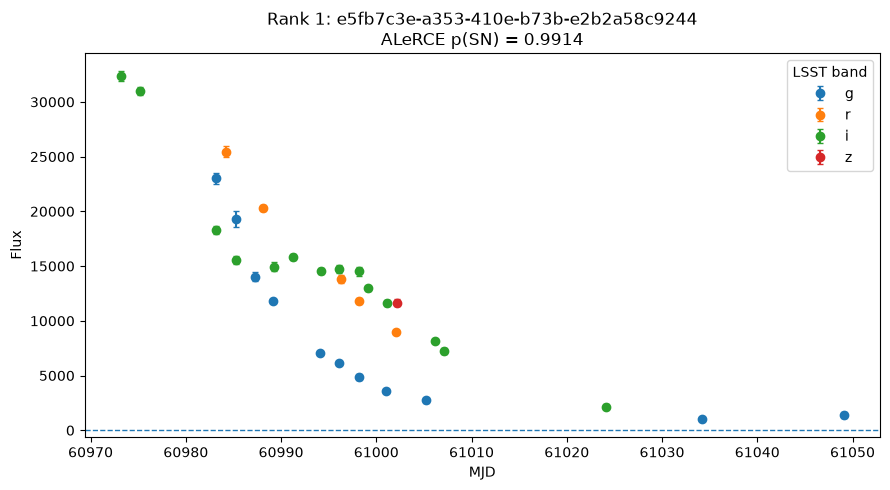

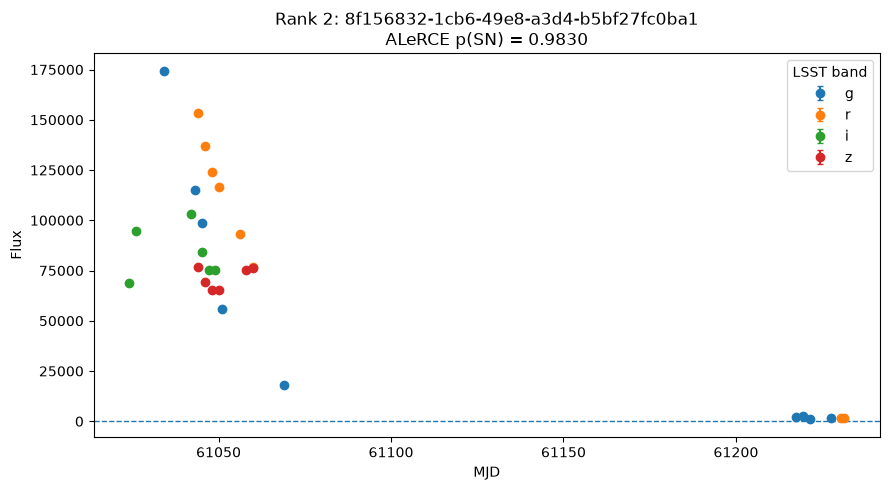

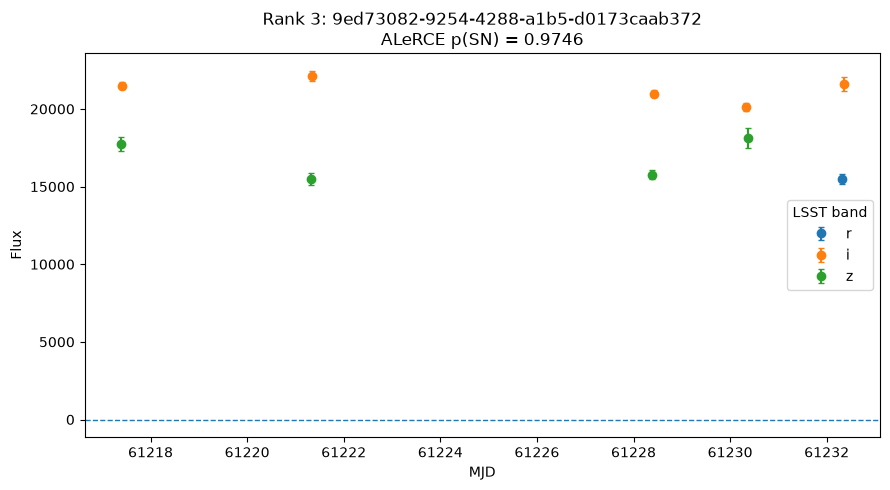

In [64]:
bands = ["u", "g", "r", "i", "z", "y"]

for rank, (_, candidate) in enumerate(top3.iterrows(), start=1):

    snid = str(candidate["SNID"])

    # Retrieve the data we already saved
    result = bayesn_results[snid]
    nightly = result["nightly"]

    plt.figure(figsize=(9, 5))

    for band in bands:

        use = np.asarray(nightly["BAND"]).astype(str) == band

        if np.any(use):
            plt.errorbar(
                np.asarray(nightly["MJD"])[use],
                np.asarray(nightly["FLUX"])[use],
                yerr=np.asarray(nightly["FLUXERR"])[use],
                fmt="o",
                capsize=2,
                label=band,
            )

    plt.axhline(0, ls="--", lw=1)

    plt.xlabel("MJD")
    plt.ylabel("Flux")
    
    plt.title(
        f"Rank {rank}: {snid}\n"
        f"ALeRCE p(SN) = {candidate['p_SN']:.4f}"
    )

    plt.legend(title="LSST band")
    plt.tight_layout()
    plt.show()

Rank 1 | e5fb7c3e-a353-410e-b73b-e2b2a58c9244 | p_SN = 0.9914


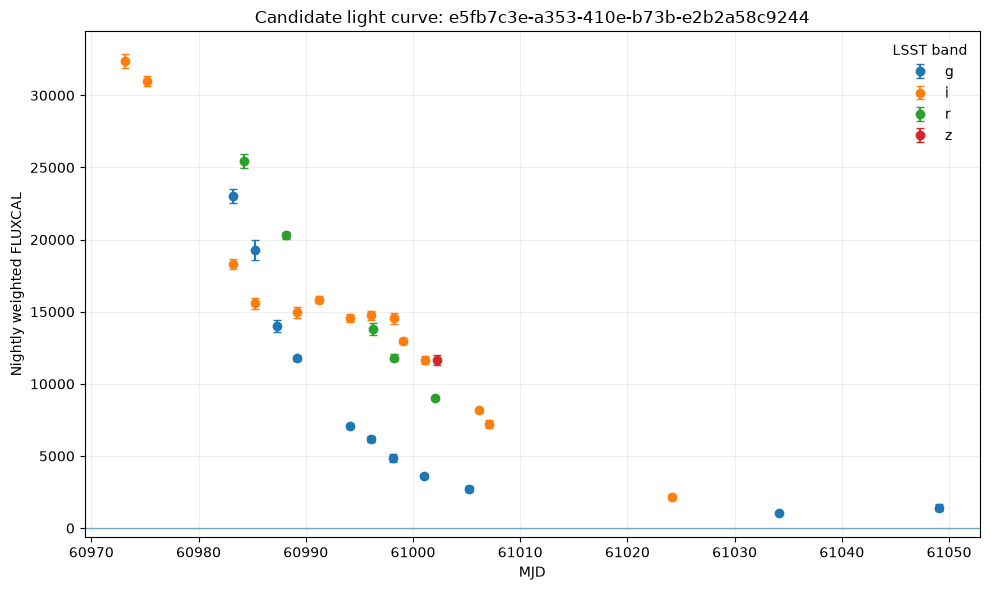

Rank 2 | 8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1 | p_SN = 0.9830


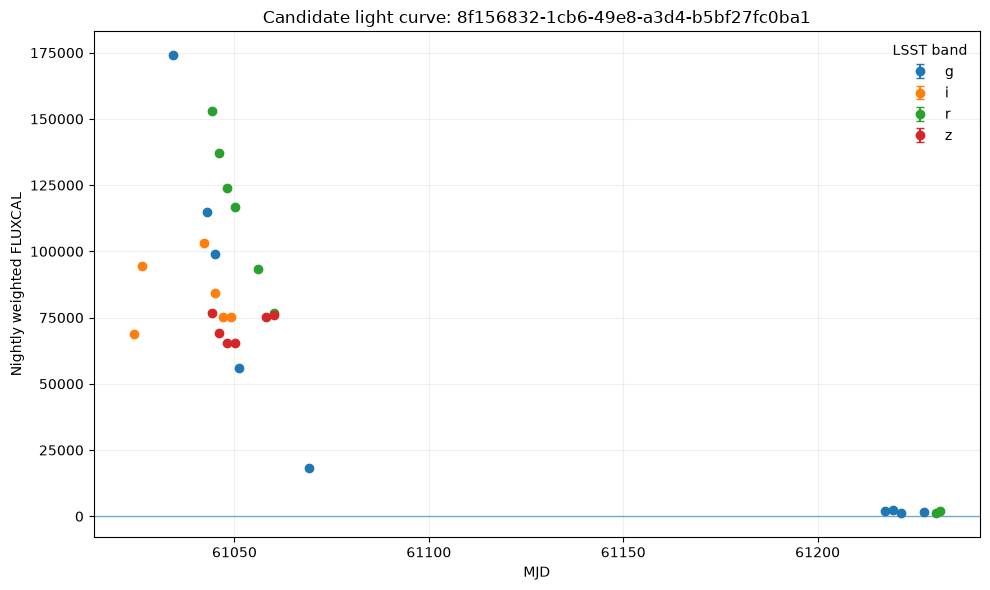

Rank 3 | 9ed73082-9254-4288-a1b5-d0173caab372 | p_SN = 0.9746


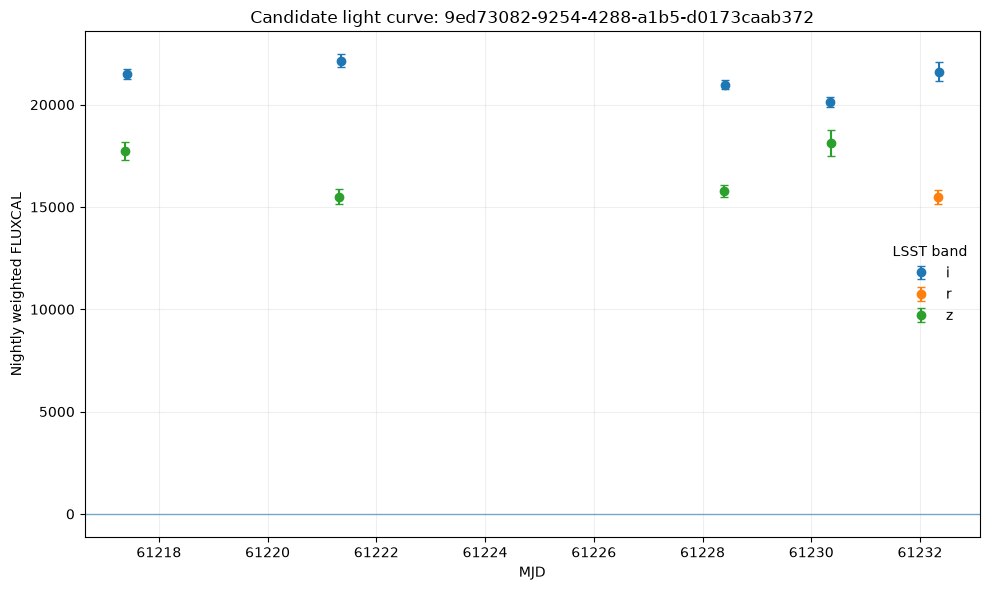

In [65]:
for rank, (_, candidate) in enumerate(top3.iterrows(), start=1):

    snid = str(candidate["SNID"])
    nightly = bayesn_results[snid]["nightly"]

    print(
        f"Rank {rank} | "
        f"{snid} | "
        f"p_SN = {candidate['p_SN']:.4f}"
    )

    plot_nightly_lightcurve(
        nightly,
        snid,
    )

In [66]:
candidate = top3.iloc[0]
snid = str(candidate["SNID"])

result = bayesn_results[snid]

samples = result["samples"]
props = result["props"]
nightly = result["nightly"]
head_row = result["head_row"]

print("SNID:", snid)
print("p_SN:", result["p_SN"])

SNID: e5fb7c3e-a353-410e-b73b-e2b2a58c9244
p_SN: 0.99135804


In [67]:
plot_samples = dict(samples)

# get_flux_from_chains expects "mu"
# Your current fit stores this as "Ds"
if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

# Some versions also expect delM
if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )

In [68]:
phase = np.linspace(
    -15,
    50,
    200,
)

observed_bands = np.unique(
    np.asarray(nightly["BAND"]).astype(str)
)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
]

print("Observed bands:", observed_bands)
print("BayeSN bands:", bands)

Observed bands: ['g' 'i' 'r' 'z']
BayeSN bands: ['g_LSST', 'i_LSST', 'r_LSST', 'z_LSST']


In [69]:
z_prop, ebv_prop = props

print("z property:", z_prop)
print("MW E(B-V):", ebv_prop)

z property: 0.5005
MW E(B-V): 0.0079098641872406


In [70]:
z_plot = float(
    np.median(
        np.asarray(z_prop)
    )
)

print("Redshift used for model:", z_plot)

Redshift used for model: 0.5005


In [71]:
flux_grid = model_broad.get_flux_from_chains(
    phase,
    bands,
    plot_samples,
    z_plot,
    float(head_row["MWEBV"]),
    mag=False,

    # 200 is plenty for visualization
    # and faster than using all samples
    num_samples=200,
)

print("flux_grid shape:", flux_grid.shape)

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:28<00:00, 28.98s/it]

flux_grid shape: (1, 200, 4, 200)


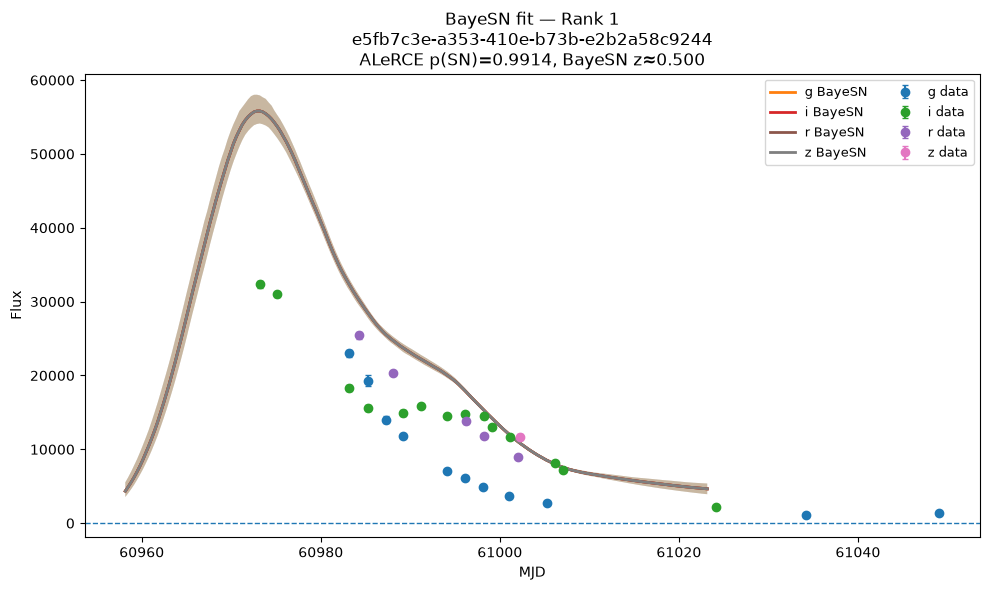

In [73]:
# -----------------------------
# Plot data + BayeSN model
# -----------------------------

peak_mjd = float(head_row["PEAKMJD"])

mjd_grid = phase + peak_mjd

obs_mjd = np.asarray(
    nightly["MJD"],
    dtype=float,
)

obs_flux = np.asarray(
    nightly["FLUX"],
    dtype=float,
)

obs_fluxerr = np.asarray(
    nightly["FLUXERR"],
    dtype=float,
)

obs_band = np.asarray(
    nightly["BAND"]
).astype(str)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


for j, band in enumerate(observed_bands):

    use = obs_band == band

    # Observed photometry
    ax.errorbar(
        obs_mjd[use],
        obs_flux[use],
        yerr=obs_fluxerr[use],
        fmt="o",
        capsize=2,
        label=f"{band} data",
    )

    # BayeSN posterior median
    ax.plot(
        mjd_grid,
        median_flux[j],
        lw=2,
        label=f"{band} BayeSN",
    )

    # 68% posterior interval
    ax.fill_between(
        mjd_grid,
        low_flux[j],
        high_flux[j],
        alpha=0.15,
    )


ax.axhline(
    0,
    ls="--",
    lw=1,
)

ax.set_xlabel("MJD")
ax.set_ylabel("Flux")

ax.set_title(
    f"BayeSN fit — Rank 1\n"
    f"{snid}\n"
    f"ALeRCE p(SN)={result['p_SN']:.4f}, "
    f"BayeSN z≈{z_plot:.3f}"
)

ax.legend(
    ncol=2,
    fontsize=9,
)

plt.tight_layout()
plt.show()

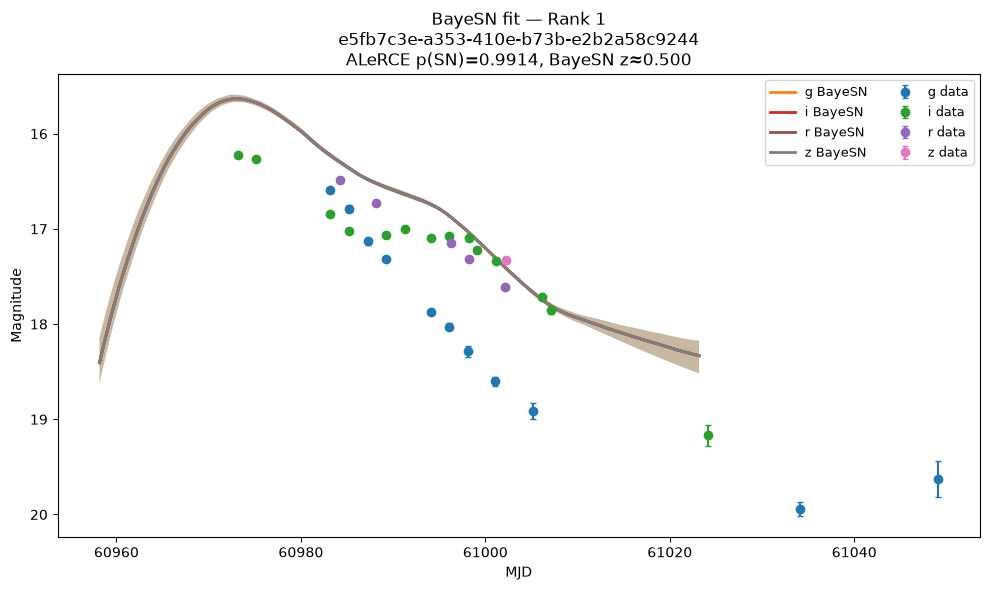

In [76]:
peak_mjd = float(head_row["PEAKMJD"])

mjd_grid = phase + peak_mjd


fig, ax = plt.subplots(
    figsize=(10, 6)
)


for j, band in enumerate(observed_bands):

    use = obs_band == band

    # ----------------------
    # Observed photometry
    # ----------------------

    ax.errorbar(
        obs_mjd[use],
        obs_mag[use],
        yerr=obs_magerr[use],
        fmt="o",
        capsize=2,
        label=f"{band} data",
    )


    # ----------------------
    # BayeSN model
    # ----------------------

    ax.plot(
        mjd_grid,
        median_mag[j],
        lw=2,
        label=f"{band} BayeSN",
    )


    ax.fill_between(
        mjd_grid,
        low_mag[j],
        high_mag[j],
        alpha=0.15,
    )


# Magnitudes run backwards
ax.invert_yaxis()

ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")

ax.set_title(
    f"BayeSN fit — Rank 1\n"
    f"{snid}\n"
    f"ALeRCE p(SN)={result['p_SN']:.4f}, "
    f"BayeSN z≈{z_plot:.3f}"
)

ax.legend(
    ncol=2,
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [94]:
# Rank 1

candidate = top3.iloc[0]
snid = str(candidate["SNID"])

result = bayesn_results[snid]

samples = result["samples"]
nightly = result["nightly"]
head_row = result["head_row"]

# Posterior redshift

z_samples = np.asarray(
    samples["z"]
).reshape(-1)

z_plot = np.median(z_samples)

z16, z84 = np.percentile(
    z_samples,
    [16, 84],
)

print(
    f"z = {z_plot:.4f} "
    f"[{z16:.4f}, {z84:.4f}]"
)

tmax_samples = np.asarray(
    samples["tmax"]
).reshape(-1)

tmax_plot = np.median(tmax_samples)

print("posterior tmax:", tmax_plot)

z = 0.1224 [0.1164, 0.1297]
posterior tmax: -0.9675301372184414


In [100]:
# Load observed data

t = np.asarray(
    nightly["MJD"],
    dtype=float,
)

flux = np.asarray(
    nightly["FLUX"],
    dtype=float,
)

flux_err = np.asarray(
    nightly["FLUXERR"],
    dtype=float,
)

filters = np.asarray(
    nightly["BAND"]
).astype(str)

# Prepare BayeSN posterior samples

plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )


# Rest-frame phase grid
phase = np.linspace(
    -20,
    30,
    400,
)


observed_bands = np.unique(filters)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
]

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:13<00:00, 13.09s/it]


Model shape: (4, 400)
Input PEAKMJD: 60973.16796875
BayeSN fitted peak MJD: 60972.20043861278


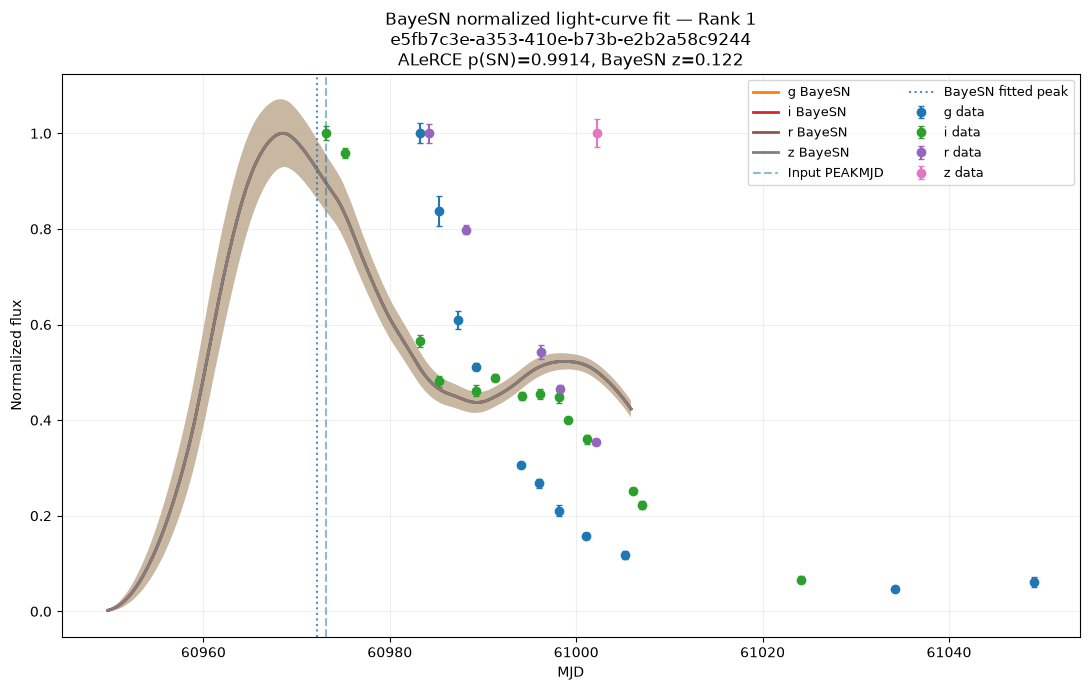

In [101]:
#  BayeSN model

flux_grid = model_broad.get_flux_from_chains(
    phase,
    bands,
    plot_samples,
    z_plot,
    float(head_row["MWEBV"]),
    mag=False,
    num_samples=200,
)


flux_grid = np.asarray(
    flux_grid[0]
)


# posterior mean / scatter
mean_flux = flux_grid.mean(
    axis=0
)

std_flux = flux_grid.std(
    axis=0
)


print(
    "Model shape:",
    mean_flux.shape
)

peak_mjd = float(
    head_row["PEAKMJD"]
)

# BayeSN fitted date of maximum
fitted_peak_mjd = (
    peak_mjd + tmax_plot
)


# Convert rest-frame phase to observer-frame MJD
mjd_grid = (
    fitted_peak_mjd
    + phase * (1 + z_plot)
)

print("Input PEAKMJD:", peak_mjd)
print("BayeSN fitted peak MJD:", fitted_peak_mjd)

# Plot normalised light curves

fig, ax = plt.subplots(
    figsize=(11, 7)
)


for i, band in enumerate(observed_bands):

    use = filters == band

    data_flux = flux[use]
    data_err = flux_err[use]
    data_mjd = t[use]

    model_flux = mean_flux[i]
    model_err = std_flux[i]



    # Normalise each band separately

    data_scale = np.max(data_flux)
    model_scale = np.max(model_flux)

    data_norm = (
        data_flux / data_scale
    )

    data_err_norm = (
        data_err / data_scale
    )

    model_norm = (
        model_flux / model_scale
    )

    model_err_norm = (
        model_err / model_scale
    )

    # Observations

    ax.errorbar(
        data_mjd,
        data_norm,
        yerr=data_err_norm,
        fmt="o",
        capsize=2,
        label=f"{band} data",
    )

    # BayeSN model

    ax.plot(
        mjd_grid,
        model_norm,
        linewidth=2,
        label=f"{band} BayeSN",
    )


    ax.fill_between(
        mjd_grid,
        model_norm - model_err_norm,
        model_norm + model_err_norm,
        alpha=0.15,
    )
    
# Labels

# Input/reference peak
ax.axvline(
    peak_mjd,
    linestyle="--",
    alpha=0.5,
    label="Input PEAKMJD",
)

# Peak preferred by BayeSN posterior
ax.axvline(
    fitted_peak_mjd,
    linestyle=":",
    alpha=0.8,
    label="BayeSN fitted peak",
)

ax.set_xlabel("MJD")

ax.set_ylabel(
    "Normalised flux"
)

ax.set_title(
    f"BayeSN normalized light-curve fit — Rank 1\n"
    f"{snid}\n"
    f"ALeRCE p(SN)={result['p_SN']:.4f}, "
    f"BayeSN z={z_plot:.3f}"
)

ax.legend(
    ncol=2,
    fontsize=9,
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [102]:
### Object 2

candidate = top3.iloc[1]
snid = str(candidate["SNID"])

result = bayesn_results[snid]

samples = result["samples"]
nightly = result["nightly"]
head_row = result["head_row"]

# Posterior redshift

z_samples = np.asarray(
    samples["z"]
).reshape(-1)

z_plot = np.median(z_samples)

z16, z84 = np.percentile(
    z_samples,
    [16, 84],
)

print(
    f"z = {z_plot:.4f} "
    f"[{z16:.4f}, {z84:.4f}]"
)

tmax_samples = np.asarray(
    samples["tmax"]
).reshape(-1)

tmax_plot = np.median(tmax_samples)

print("posterior tmax:", tmax_plot)

z = 0.4138 [0.2732, 0.7961]
posterior tmax: 3.183857515297084


In [103]:
# Load observed data

t = np.asarray(
    nightly["MJD"],
    dtype=float,
)

flux = np.asarray(
    nightly["FLUX"],
    dtype=float,
)

flux_err = np.asarray(
    nightly["FLUXERR"],
    dtype=float,
)

filters = np.asarray(
    nightly["BAND"]
).astype(str)

# Prepare BayeSN posterior samples

plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )


# Rest-frame phase grid
phase = np.linspace(
    -20,
    30,
    400,
)


observed_bands = np.unique(filters)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
]

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:11<00:00, 11.95s/it]


Model shape: (4, 400)
Input PEAKMJD: 61034.15234375
BayeSN fitted peak MJD: 61037.336201265294


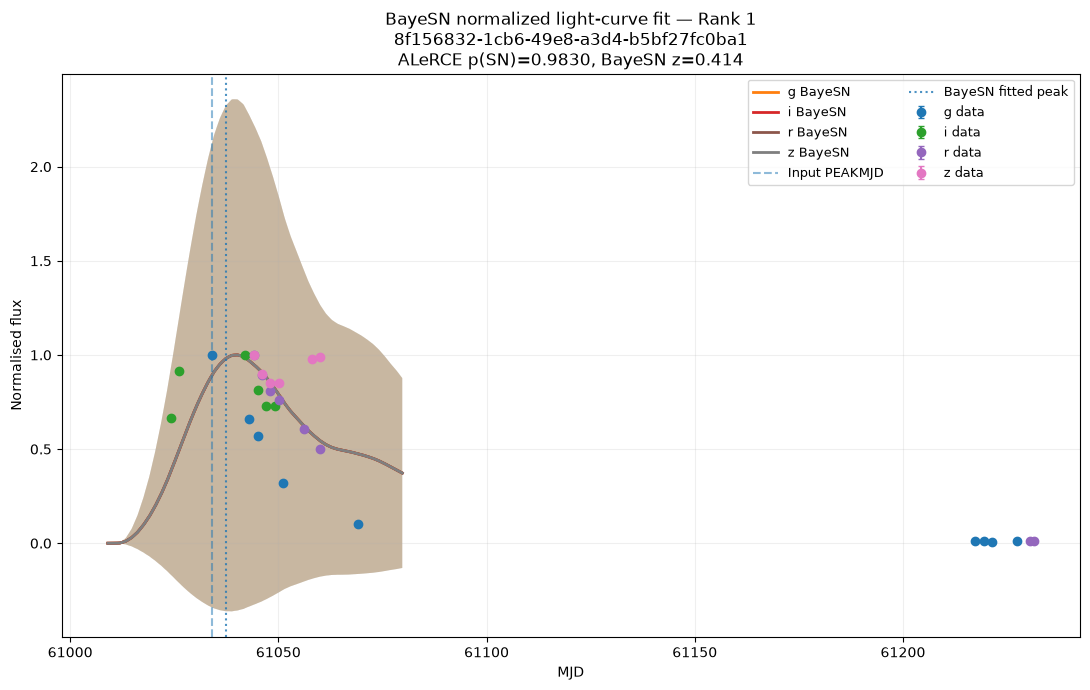

In [104]:
#  BayeSN model

flux_grid = model_broad.get_flux_from_chains(
    phase,
    bands,
    plot_samples,
    z_plot,
    float(head_row["MWEBV"]),
    mag=False,
    num_samples=200,
)


flux_grid = np.asarray(
    flux_grid[0]
)


# posterior mean / scatter
mean_flux = flux_grid.mean(
    axis=0
)

std_flux = flux_grid.std(
    axis=0
)


print(
    "Model shape:",
    mean_flux.shape
)

peak_mjd = float(
    head_row["PEAKMJD"]
)

# BayeSN fitted date of maximum
fitted_peak_mjd = (
    peak_mjd + tmax_plot
)


# Convert rest-frame phase to observer-frame MJD
mjd_grid = (
    fitted_peak_mjd
    + phase * (1 + z_plot)
)

print("Input PEAKMJD:", peak_mjd)
print("BayeSN fitted peak MJD:", fitted_peak_mjd)

# Plot normalised light curves

fig, ax = plt.subplots(
    figsize=(11, 7)
)


for i, band in enumerate(observed_bands):

    use = filters == band

    data_flux = flux[use]
    data_err = flux_err[use]
    data_mjd = t[use]

    model_flux = mean_flux[i]
    model_err = std_flux[i]



    # Normalise each band separately

    data_scale = np.max(data_flux)
    model_scale = np.max(model_flux)

    data_norm = (
        data_flux / data_scale
    )

    data_err_norm = (
        data_err / data_scale
    )

    model_norm = (
        model_flux / model_scale
    )

    model_err_norm = (
        model_err / model_scale
    )

    # Observations

    ax.errorbar(
        data_mjd,
        data_norm,
        yerr=data_err_norm,
        fmt="o",
        capsize=2,
        label=f"{band} data",
    )

    # BayeSN model

    ax.plot(
        mjd_grid,
        model_norm,
        linewidth=2,
        label=f"{band} BayeSN",
    )


    ax.fill_between(
        mjd_grid,
        model_norm - model_err_norm,
        model_norm + model_err_norm,
        alpha=0.15,
    )
    
# Labels

# Input/reference peak
ax.axvline(
    peak_mjd,
    linestyle="--",
    alpha=0.5,
    label="Input PEAKMJD",
)

# Peak preferred by BayeSN posterior
ax.axvline(
    fitted_peak_mjd,
    linestyle=":",
    alpha=0.8,
    label="BayeSN fitted peak",
)

ax.set_xlabel("MJD")

ax.set_ylabel(
    "Normalised flux"
)

ax.set_title(
    f"BayeSN normalized light-curve fit — Rank 1\n"
    f"{snid}\n"
    f"ALeRCE p(SN)={result['p_SN']:.4f}, "
    f"BayeSN z={z_plot:.3f}"
)

ax.legend(
    ncol=2,
    fontsize=9,
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### Plotting function

In [106]:
def plot_bayesn_candidate(candidate, rank=None):

    import numpy as np
    import matplotlib.pyplot as plt

    # --------------------------------------------
    # Candidate/result
    # --------------------------------------------

    snid = str(candidate["SNID"])
    result = bayesn_results[snid]

    samples = result["samples"]
    nightly = result["nightly"]
    head_row = result["head_row"]


    # --------------------------------------------
    # Redshift posterior
    # --------------------------------------------

    z_samples = np.asarray(
        samples["z"]
    ).reshape(-1)

    z_plot = np.median(z_samples)

    z16, z84 = np.percentile(
        z_samples,
        [16, 84]
    )


    # --------------------------------------------
    # tmax posterior
    # --------------------------------------------

    tmax_samples = np.asarray(
        samples["tmax"]
    ).reshape(-1)

    tmax_plot = np.median(tmax_samples)


    # --------------------------------------------
    # Observed light curve
    # --------------------------------------------

    t = np.asarray(
        nightly["MJD"],
        dtype=float
    )

    flux = np.asarray(
        nightly["FLUX"],
        dtype=float
    )

    flux_err = np.asarray(
        nightly["FLUXERR"],
        dtype=float
    )

    filters = np.asarray(
        nightly["BAND"]
    ).astype(str)


    # --------------------------------------------
    # Prepare posterior samples
    # --------------------------------------------

    plot_samples = dict(samples)

    if "mu" not in plot_samples:
        plot_samples["mu"] = plot_samples["Ds"]

    if "delM" not in plot_samples:
        plot_samples["delM"] = np.zeros_like(
            plot_samples["Ds"]
        )


    # --------------------------------------------
    # Phase + bands
    # --------------------------------------------

    phase = np.linspace(
        -40,
        80,
        400
    )

    observed_bands = np.unique(filters)

    bands = [
        LSST_FILT_MAP[b]
        for b in observed_bands
    ]


    # --------------------------------------------
    # BayeSN posterior model curves
    # --------------------------------------------

    flux_grid = model_broad.get_flux_from_chains( # use photoz 
        phase,
        bands,
        plot_samples,
        z_plot,
        float(head_row["MWEBV"]),
        mag=False,
        num_samples=200,
    )

    flux_grid = np.asarray(
        flux_grid[0]
    )

    mean_flux = flux_grid.mean(
        axis=0
    )

    std_flux = flux_grid.std(
        axis=0
    )


    # --------------------------------------------
    # MJD conversion
    # --------------------------------------------

    peak_mjd = float(
        head_row["PEAKMJD"]
    )

    mjd_grid = (
        peak_mjd
        + phase * (1 + z_plot)
    )

    fitted_peak_mjd = (
        peak_mjd
        + tmax_plot * (1 + z_plot)
    )


    # --------------------------------------------
    # Diagnostics
    # --------------------------------------------

    print("\nSNID:", snid)
    print(f"ALeRCE p_SN = {result['p_SN']:.4f}")
    print(
        f"BayeSN z = {z_plot:.4f} "
        f"[{z16:.4f}, {z84:.4f}]"
    )
    print(f"tmax = {tmax_plot:.3f}")
    print("N points =", len(nightly))
    print("Bands =", observed_bands)


    # --------------------------------------------
    # Plot
    # --------------------------------------------

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    for i, band in enumerate(observed_bands):

        use = filters == band

        data_flux = flux[use]
        data_err = flux_err[use]
        data_mjd = t[use]

        model_flux = mean_flux[i]
        model_err = std_flux[i]


        # Avoid weird normalization
        if len(data_flux) == 0:
            continue

        data_scale = np.max(data_flux)
        model_scale = np.max(model_flux)

        if data_scale <= 0 or model_scale <= 0:
            continue


        data_norm = (
            data_flux / data_scale
        )

        data_err_norm = (
            data_err / data_scale
        )

        model_norm = (
            model_flux / model_scale
        )

        model_err_norm = (
            model_err / model_scale
        )


        # data
        ax.errorbar(
            data_mjd,
            data_norm,
            yerr=data_err_norm,
            fmt="o",
            capsize=2,
            label=f"{band} data",
        )

        # BayeSN model
        ax.plot(
            mjd_grid,
            model_norm,
            linewidth=2,
            label=f"{band} BayeSN",
        )

        ax.fill_between(
            mjd_grid,
            model_norm - model_err_norm,
            model_norm + model_err_norm,
            alpha=0.15,
        )


    # Input peak
    ax.axvline(
        peak_mjd,
        linestyle="--",
        alpha=0.6,
        label="Input PEAKMJD",
    )

    # BayeSN fitted peak
    ax.axvline(
        fitted_peak_mjd,
        linestyle=":",
        alpha=0.8,
        label="BayeSN fitted peak",
    )


    if rank is None:
        title_rank = ""
    else:
        title_rank = f" — Rank {rank}"


    ax.set_xlabel("MJD")
    ax.set_ylabel("Normalised flux")

    ax.set_title(
        f"BayeSN normalized light-curve fit"
        f"{title_rank}\n"
        f"{snid}\n"
        f"ALeRCE p(SN)={result['p_SN']:.4f}, "
        f"BayeSN z={z_plot:.3f}"
    )

    ax.legend(
        ncol=2,
        fontsize=9
    )

    ax.grid(
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

### Plot top 3

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:21<00:00, 21.55s/it]



SNID: e5fb7c3e-a353-410e-b73b-e2b2a58c9244
ALeRCE p_SN = 0.9914
BayeSN z = 0.1224 [0.1164, 0.1297]
tmax = -0.968
N points = 31
Bands = ['g' 'i' 'r' 'z']


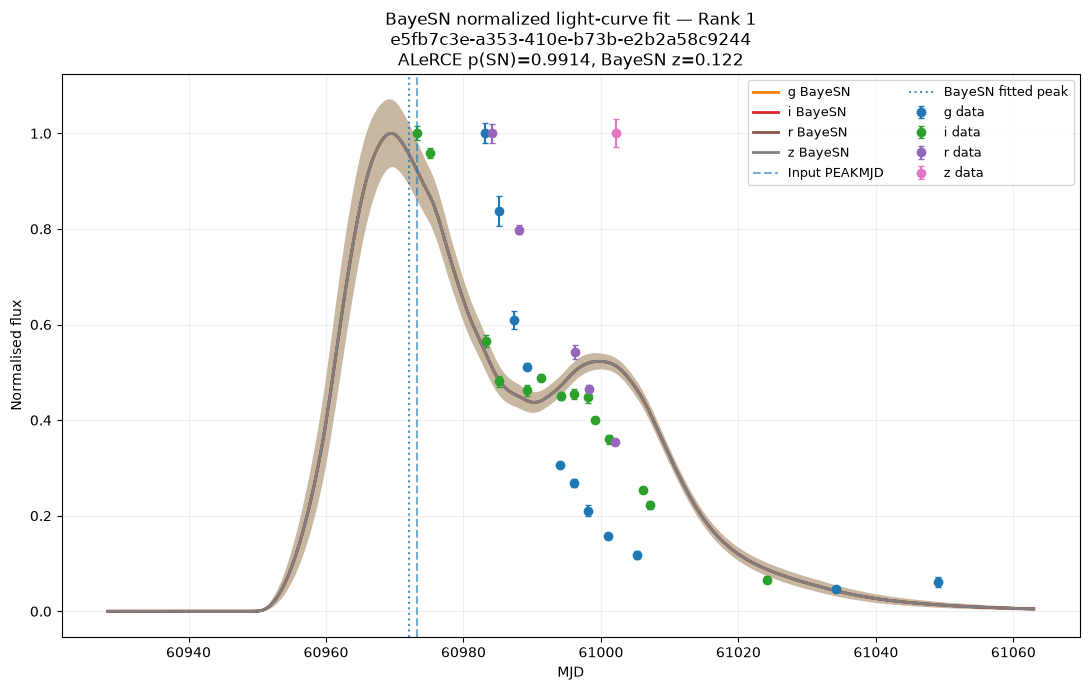

In [107]:
plot_bayesn_candidate(
    top3.iloc[0],
    rank=1
)

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:13<00:00, 13.67s/it]



SNID: 8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1
ALeRCE p_SN = 0.9830
BayeSN z = 0.4138 [0.2732, 0.7961]
tmax = 3.184
N points = 29
Bands = ['g' 'i' 'r' 'z']


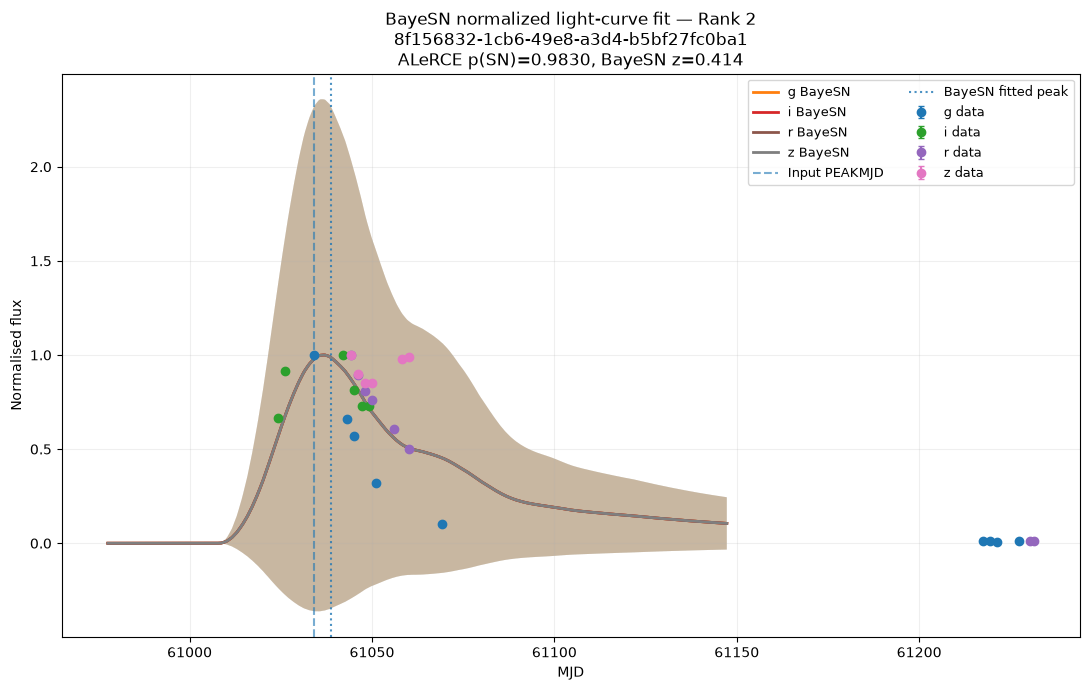

In [108]:
plot_bayesn_candidate(
    top3.iloc[1],
    rank=2
)

Getting best fit light curves from chains...


100%|██████████████████████████████████████████████| 1/1 [00:18<00:00, 18.85s/it]



SNID: 9ed73082-9254-4288-a1b5-d0173caab372
ALeRCE p_SN = 0.9746
BayeSN z = 0.3519 [0.2757, 0.7156]
tmax = 0.875
N points = 10
Bands = ['i' 'r' 'z']


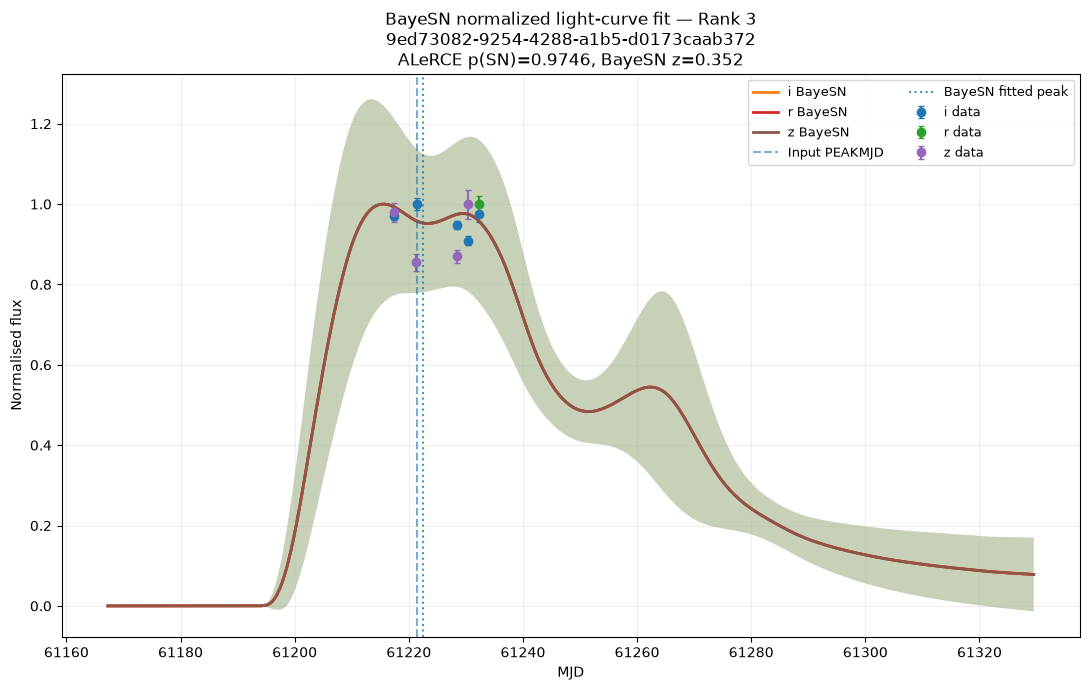

In [109]:
plot_bayesn_candidate(
    top3.iloc[2],
    rank=3
)

Rank 1: z = 0.1224 [0.1164, 0.1297]
Rank 2: z = 0.4138 [0.2732, 0.7961]
Rank 3: z = 0.3519 [0.2757, 0.7156]


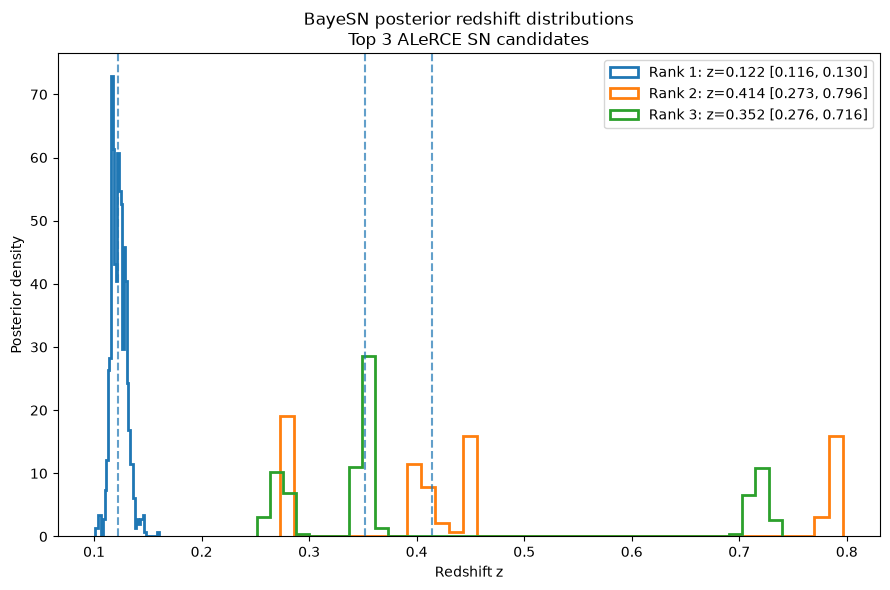

In [113]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

for rank, (_, candidate) in enumerate(top3.iterrows(), start=1):

    snid = str(candidate["SNID"])

    result = bayesn_results[snid]
    samples = result["samples"]

    # Posterior redshift samples
    z_samples = np.asarray(
        samples["z"]
    ).reshape(-1)

    # Posterior summary
    z_med = np.median(z_samples)
    z16, z84 = np.percentile(
        z_samples,
        [16, 84]
    )

    print(
        f"Rank {rank}: "
        f"z = {z_med:.4f} "
        f"[{z16:.4f}, {z84:.4f}]"
    )

    # Plot posterior
    ax.hist(
        z_samples,
        bins=40,
        density=True,
        histtype="step",
        linewidth=2,
        label=(
            f"Rank {rank}: "
            f"z={z_med:.3f} "
            f"[{z16:.3f}, {z84:.3f}]"
        ),
    )

    # Median
    ax.axvline(
        z_med,
        linestyle="--",
        alpha=0.7,
    )


ax.set_xlabel("Redshift z")
ax.set_ylabel("Posterior density")

ax.set_title(
    "BayeSN posterior redshift distributions\n"
    "Top 3 ALeRCE SN candidates"
)

ax.legend()

plt.tight_layout()
plt.show()

In [114]:
target_snid = "e5fb7c3e-a353-410e-b73b-e2b2a58c9244"

row = alerce_match[
    alerce_match["SNID"].astype(str) == target_snid
]

display(row.T)

,141
SNID,e5fb7c3e-a353-410e-b73b-e2b2a58c9244
oid,313629129605382144.0
sep_arcsec,0.002803
p_SN,0.991358
classifier_version,202.0


In [117]:
target_snid = "e5fb7c3e-a353-410e-b73b-e2b2a58c9244"

# find the matching HEAD row
head_match = [
    row for row in head_data
    if clean_snid(row["SNID"]) == target_snid
][0]

m = match_lsst_object(
    head_match["RA"],
    head_match["DEC"],
    target_snid,
    search_radius_arcsec=1.0,
)

print("Fresh match:", m)

Fresh match: (np.int64(313629129605382159), np.float64(0.0028028301417118186))


In [119]:
oid, sep = m

oid = str(oid)

print("Correct ALeRCE oid:", oid)
print("Separation:", sep)

Correct ALeRCE oid: 313629129605382159
Separation: 0.0028028301417118186


### Top 10

In [112]:
top10 = (
    alerce_cut
    .sort_values("p_SN", ascending=False)
    .head(10)
    .copy()
)



### BayeSN preliminary lc Rank 2: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a

SNID: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
HEAD index: 43571
Number of nightly points: 88
Bands: ['g' 'i' 'r' 'z']


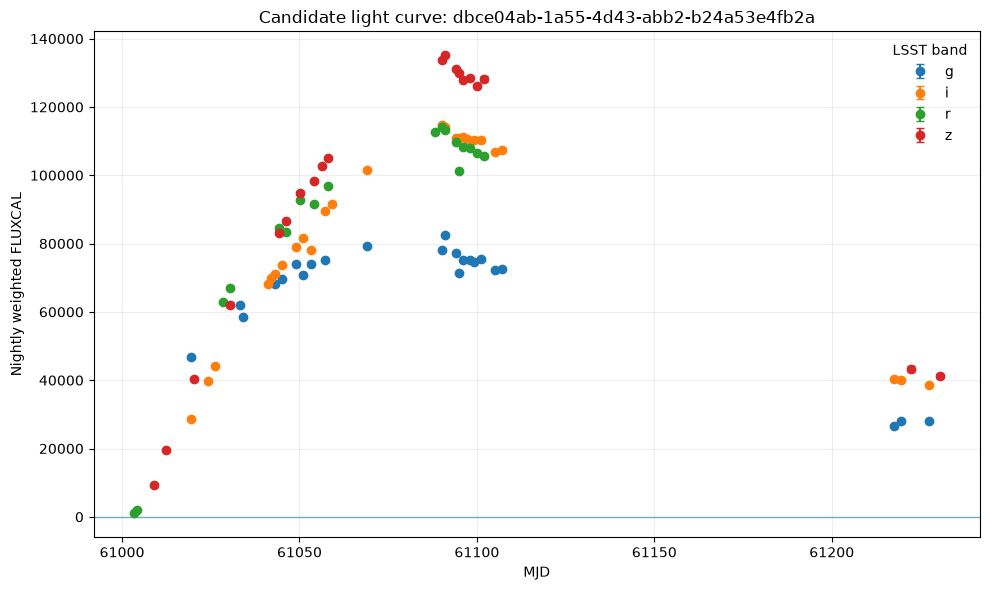

In [35]:
target_snid = "dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"

match = transient_candidates[
    transient_candidates["SNID"] == target_snid
    ]

if len(match) == 0:
    raise ValueError(f"{target_snid} not found")

candidate = match.iloc[0]

idx = int(candidate["HEAD_INDEX"])
head_row = head_data[idx]

lc = get_lightcurve(head_row)

nightly = make_positive_nightly_lightcurve(
    lc,
    min_snr=3.0,
)

print("SNID:", target_snid)
print("HEAD index:", idx)
print("Number of nightly points:", len(nightly))
print("Bands:", np.unique(nightly["BAND"]))

plot_nightly_lightcurve(
    nightly,
    target_snid,
)

In [45]:
import numpy as np
import jax.numpy as jnp

from bayesn import SEDmodel

model_broad = SEDmodel(
    load_model="T21_model"
)


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [38]:
LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}


In [39]:
zq_broad = jnp.linspace(
    0.001,
    3.0,
    301,
)

t = np.asarray(
    nightly["MJD"],
    dtype=float,
)

flux = np.asarray(
    nightly["FLUX"],
    dtype=float,
)

flux_err = np.asarray(
    nightly["FLUXERR"],
    dtype=float,
)

filters = np.asarray(
    nightly["BAND"]
).astype(str)

In [40]:
ebv_mw = float(head_row["MWEBV"])

peak_mjd = float(head_row["PEAKMJD"])

print("MWEBV:", ebv_mw)
print("PEAKMJD:", peak_mjd)

MWEBV: 0.010929998941719532
PEAKMJD: 61091.09375


In [47]:
ebv_mw = float(head_row["MWEBV"])
peak_mjd = float(head_row["PEAKMJD"])
t = np.asarray(nightly["MJD"], dtype=float)
flux = np.asarray(nightly["FLUX"], dtype=float)
flux_err = np.asarray(nightly["FLUXERR"], dtype=float)
filters = np.asarray(nightly["BAND"]).astype(str)

zq_broad = jnp.linspace(0.001, 3.0, 301)

samples_broad, props_broad = model_broad.fit(
    t,
    flux,
    flux_err,
    filters,
    1.5,   # reference scalar required internally

    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),

    filt_map=LSST_FILT_MAP,

    photoz=True,
    z_quantiles=zq_broad,

    chain_method="sequential",
)

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:27<00:00, 18.40it/s, 3 steps of size 4.84e-04. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:22<00:00, 22.41it/s, 7 steps of size 5.11e-04. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.05      0.07      0.05      0.18      2.00   4602.81
          Ds[0]     39.84      0.49     39.79     39.10     40.61      2.73      3.76
 eps_tform[0,0]      0.23      0.27      0.30     -0.20      0.50      2.00   9208.70
 eps_tform[0,1]      0.03      0.30     -0.01     -0.34      0.49      2.00   8810.02
 eps_tform[0,2]      0.32      0.22      0.32      0.00      0.62      2.00   4866.78
 eps_tform[0,3]      0.20      0.38      0.15     -0.25      0.77      2.00  13357.00
 eps_tform[0,4]      0.02      0.28      0.10     -0.41      0.32      2.00  10313.26
 eps_tform[0,5]     -0.10      0.33     -0.14     -0.51      0.40      2.00  12507.98
 eps_tform[0,6]      0.11      0.24      0.04     -0.12      0.50      2.00   8291.59
 eps_tform[0,7]      0.10      0.08      0.11     -0.01      0.20      2.00   3188.39
 eps_tform[0,8]      0.15      0.08      0.18      0.

In [48]:
phase = np.linspace(-15, 50, 250)

# Only generate curves for bands actually present
observed_bands = np.unique(filters)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
]

print("Observed bands:", observed_bands)
print("BayeSN bands:", bands)

Observed bands: ['g' 'i' 'r' 'z']
BayeSN bands: ['g_LSST', 'i_LSST', 'r_LSST', 'z_LSST']


In [49]:
plot_samples = dict(samples_broad)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )

In [50]:
z_prop, ebv_prop = props_broad

flux_grid = model_broad.get_flux_from_chains(
    phase,
    bands,
    plot_samples,
    z_prop,
    ebv_prop,
    mag=False,
    num_samples=500,
)

print("flux_grid shape:", flux_grid.shape)

Getting best fit light curves from chains...


100%|████████████████████████████████████████████| 1/1 [01:31<00:00, 91.61s/it]

flux_grid shape: (1, 500, 4, 250)


In [51]:
mean_flux = np.asarray(
    flux_grid.mean(axis=(0, 1))
)

std_flux = np.asarray(
    flux_grid.std(axis=(0, 1))
)

print("mean_flux shape:", mean_flux.shape)

peak_mjd = float(head_row["PEAKMJD"])

mjd_grid = phase + peak_mjd

mean_flux shape: (4, 250)


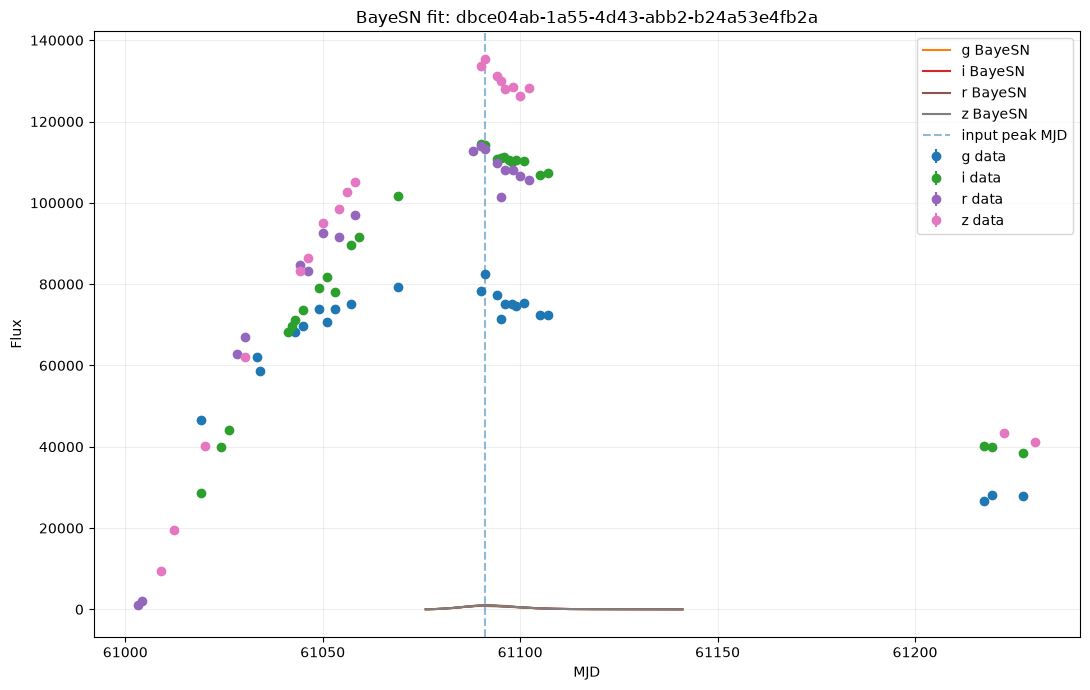

In [52]:
fig, ax = plt.subplots(figsize=(11, 7))

for i, band in enumerate(observed_bands):

    # -------------------------
    # observed nightly points
    # -------------------------

    use = filters == band

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        label=f"{band} data",
    )

    # -------------------------
    # BayeSN model
    # -------------------------

    ax.plot(
        mjd_grid,
        mean_flux[i],
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        mjd_grid,
        mean_flux[i] - std_flux[i],
        mean_flux[i] + std_flux[i],
        alpha=0.2,
    )

ax.axvline(
    peak_mjd,
    linestyle="--",
    alpha=0.5,
    label="input peak MJD",
)

ax.set_xlabel("MJD")
ax.set_ylabel("Flux")
ax.set_title(
    "BayeSN fit: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'AV'}>, <Axes: title={'center': 'AV'}>],
       [<Axes: title={'center': 'Ds'}>, <Axes: title={'center': 'Ds'}>],
       [<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>],
       [<Axes: title={'center': 'tmax'}>,
        <Axes: title={'center': 'tmax'}>],
       [<Axes: title={'center': 'u'}>, <Axes: title={'center': 'u'}>]],
      dtype=object)

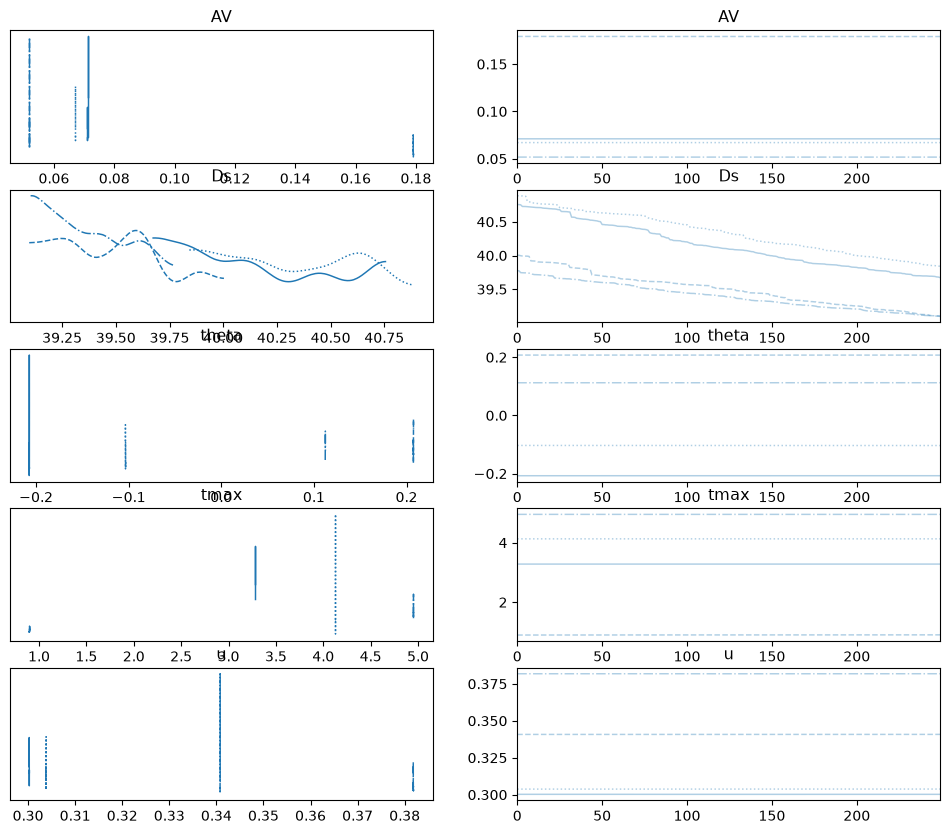

In [53]:
import arviz as az

az.plot_trace(
    samples_broad,
    var_names=[
        "AV",
        "Ds",
        "theta",
        "tmax",
        "u",
    ],
)

In [57]:
z_samples = np.asarray(
    samples_broad["z"]
).reshape(-1)

print(
    np.percentile(
        z_samples,
        [5, 16, 50, 84, 95]
    )
)

[0.90143469 0.90146188 0.96759072 1.14607405 1.14615152]


In [58]:
print("Observed flux range:")
print(flux.min(), flux.max())

print("\nModel mean flux range:")
print(mean_flux.min(), mean_flux.max())

print("\nDs samples:")
print(np.asarray(samples_broad["Ds"]).reshape(-1)[:20])

print("\nprops_broad:")
print(props_broad)

Observed flux range:
1007.5999755859376 135290.0

Model mean flux range:
10.959986198846426 945.1121302861433

Ds samples:
[40.75633447 40.75555087 40.75232735 40.72775815 40.72731033 40.726661
 40.72416457 40.72131797 40.72062659 40.7181436  40.71538845 40.71251924
 40.71181169 40.71095471 40.71022867 40.70398558 40.70110556 40.7005123
 40.69775946 40.69485377]

props_broad:
(1.5, 0.010929998941719532)


In [59]:
print(np.unique(lc["ZEROPT"])[:20])
print("ZEROPT range:", np.nanmin(lc["ZEROPT"]), np.nanmax(lc["ZEROPT"]))

[-9.]
ZEROPT range: -9.0 -9.0


In [61]:
print("flux range:", flux.min(), flux.max())
print("mean_flux range:", mean_flux.min(), mean_flux.max())

print("ZEROPT range:",
      np.nanmin(lc["ZEROPT"]),
      np.nanmax(lc["ZEROPT"]))

print("props_broad:", props_broad)

print(
    "Ds median:",
    np.median(np.asarray(samples_broad["Ds"]).reshape(-1))
)

print(
    "tmax median:",
    np.median(np.asarray(samples_broad["tmax"]).reshape(-1))
)

flux range: 1007.5999755859376 135290.0
mean_flux range: 10.959986198846426 945.1121302861433
ZEROPT range: -9.0 -9.0
props_broad: (1.5, 0.010929998941719532)
Ds median: 39.79175545873372
tmax median: 3.704983962173391


In [62]:
import inspect

print(inspect.signature(model_broad.get_flux_from_chains))

(t, bands, chains, zs, ebv_mws, mag=True, num_samples=None, num_sne=None, mean=False)


In [63]:
source = inspect.getsource(model_broad.get_flux_from_chains)

for i, line in enumerate(source.splitlines(), start=1):
    if any(key in line for key in [
        "z",
        "u",
        "photoz",
        "z_icdf_grid",
    ]):
        print(i, line)

1     def get_flux_from_chains(self, t, bands, chains, zs, ebv_mws, mag=True, num_samples=None, num_sne=None, mean=False):
3         Returns model photometry for posterior samples from BayeSN fits, which can be used to make light curve fit
9             Array of phases to evaluate model photometry at
11             List of bandpasses to evaluate model photometry in. Photometry will be
13             Path to file containing BayeSN fitting posterior samples you wish to obtain photometry for
14         zs: array-like
15             Array of heliocentric redshifts corresponding to the SNe you are obtaining model fit light curves for.
17             Array containing Milky Way extincion values corresponding to the SNe you are obtaining model fit light
18             curves for.
20             Boolean to specify whether you want magnitude or flux data. If True, magnitudes will be returned. If False,
21             flux densities (f_lambda) will be returned. Default to True i.e. mag data.
22  

In [64]:
z_plot = np.median(z_samples)

print("Redshift used for LC visualization:", z_plot)

Redshift used for LC visualization: 0.967590718482672


In [68]:
plot_model = SEDmodel(
    load_model="T21_model"
)

plot_samples = dict(samples_broad)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )
phase = np.linspace(
    -15,
    50,
    250
)

observed_bands = np.unique(filters)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
] 

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [69]:
flux_grid = plot_model.get_flux_from_chains(
    phase,
    bands,
    plot_samples,
    z_plot,
    float(head_row["MWEBV"]),
    mag=False,
    num_samples=500,
)

Getting best fit light curves from chains...


100%|████████████████████████████████████████████| 1/1 [01:06<00:00, 66.82s/it]


In [70]:
print(flux_grid.shape)

(1, 500, 4, 250)


In [71]:
mean_flux = np.asarray(
    flux_grid[0].mean(axis=0)
)

std_flux = np.asarray(
    flux_grid[0].std(axis=0)
)

print("mean_flux shape:", mean_flux.shape)
print(
    "model range:",
    mean_flux.min(),
    mean_flux.max(),
)

mean_flux shape: (4, 250)
model range: 0.47961891210980523 945.3145548362041


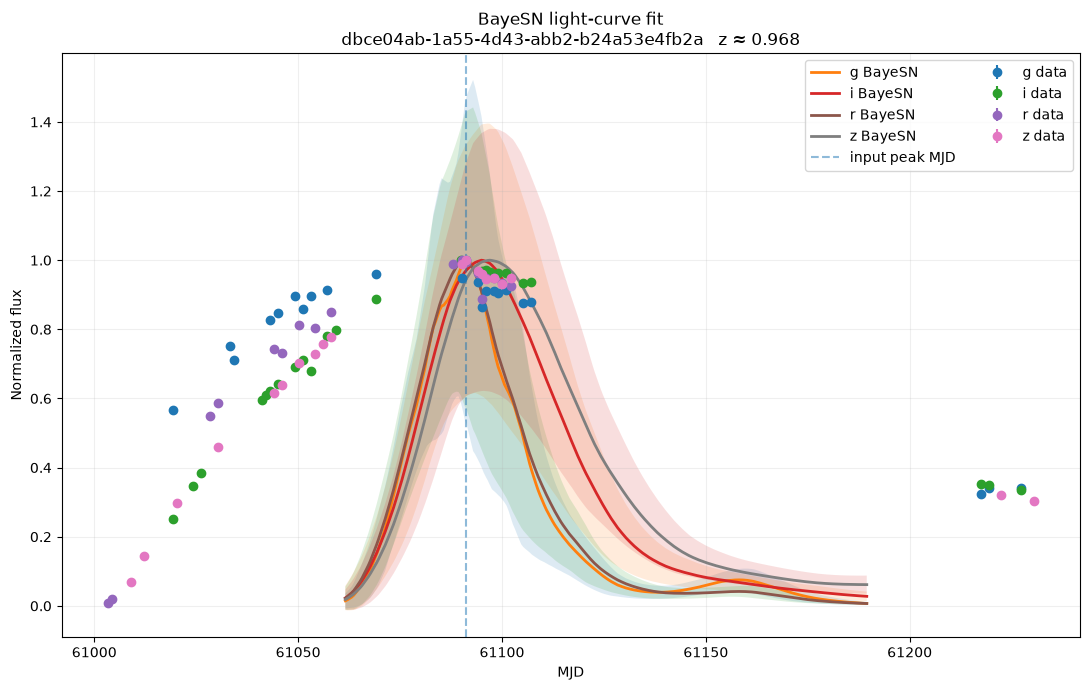

In [74]:
# Convert BayeSN phase grid to MJD
peak_mjd = float(head_row["PEAKMJD"])
#mjd_grid = phase + peak_mjd
mjd_grid = peak_mjd + phase * (1 + z_plot)
phase = np.linspace(-40, 80, 400)
fig, ax = plt.subplots(figsize=(11, 7))

for i, band in enumerate(observed_bands):

    # Observed points for this band
    use = filters == band

    data_flux = flux[use]
    data_err = flux_err[use]
    data_mjd = t[use]

    # BayeSN fitted curve for this band
    model_flux = mean_flux[i]
    model_err = std_flux[i]

    # Normalize data and model separately
    data_scale = np.max(data_flux)
    model_scale = np.max(model_flux)

    data_norm = data_flux / data_scale
    data_err_norm = data_err / data_scale

    model_norm = model_flux / model_scale
    model_err_norm = model_err / model_scale

    # Plot observed points
    ax.errorbar(
        data_mjd,
        data_norm,
        yerr=data_err_norm,
        fmt="o",
        label=f"{band} data",
    )

    # Plot BayeSN mean fit
    ax.plot(
        mjd_grid,
        model_norm,
        linewidth=2,
        label=f"{band} BayeSN",
    )

    # Posterior uncertainty
    ax.fill_between(
        mjd_grid,
        model_norm - model_err_norm,
        model_norm + model_err_norm,
        alpha=0.15,
    )

ax.axvline(
    peak_mjd,
    linestyle="--",
    alpha=0.5,
    label="input peak MJD",
)

ax.set_xlabel("MJD")
ax.set_ylabel("Normalized flux")

ax.set_title(
    f"BayeSN light-curve fit\n"
    f"{target_snid}   z ≈ {z_plot:.3f}"
)

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Trying with a different z prior

SNID: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
HEAD index: 43571
Number of nightly points: 88
Bands: ['g' 'i' 'r' 'z']


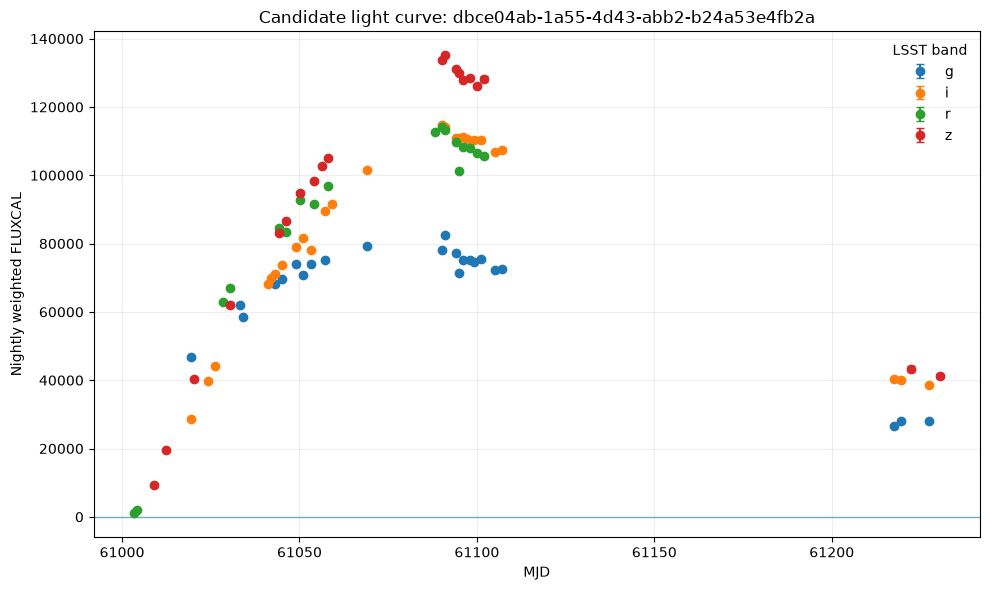

In [76]:
target_snid = "dbce04ab-1a55-4d43-abb2-b24a53e4fb2a"

match = transient_candidates[
    transient_candidates["SNID"] == target_snid
    ]

if len(match) == 0:
    raise ValueError(f"{target_snid} not found")

candidate = match.iloc[0]

idx = int(candidate["HEAD_INDEX"])
head_row = head_data[idx]

lc = get_lightcurve(head_row)

nightly = make_positive_nightly_lightcurve(
    lc,
    min_snr=3.0,
)

print("SNID:", target_snid)
print("HEAD index:", idx)
print("Number of nightly points:", len(nightly))
print("Bands:", np.unique(nightly["BAND"]))

plot_nightly_lightcurve(
    nightly,
    target_snid,
)

In [77]:
import numpy as np
import jax.numpy as jnp

from bayesn import SEDmodel

model_broad = SEDmodel(
    load_model="T21_model"
)

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [78]:
ebv_mw = float(head_row["MWEBV"])
peak_mjd = float(head_row["PEAKMJD"])
t = np.asarray(nightly["MJD"], dtype=float)
flux = np.asarray(nightly["FLUX"], dtype=float)
flux_err = np.asarray(nightly["FLUXERR"], dtype=float)
filters = np.asarray(nightly["BAND"]).astype(str)

zq_broad = jnp.linspace(0.001, 1.0, 101)

samples_broad, props_broad = model_broad.fit(
    t,
    flux,
    flux_err,
    filters,
    0.5,   # reference scalar required internally

    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),

    filt_map=LSST_FILT_MAP,

    photoz=True,
    z_quantiles=zq_broad,

    chain_method="sequential",
)

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:34<00:00, 14.35it/s, 3 steps of size 4.53e-04. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:22<00:00, 22.40it/s, 7 steps of size 6.07e-04. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.11      0.05      0.09      0.06      0.20      2.00    361.82
          Ds[0]     37.78      2.06     38.43     34.41     39.75      2.01     27.04
 eps_tform[0,0]      0.22      0.27      0.29     -0.20      0.51      2.00    199.69
 eps_tform[0,1]      0.03      0.31     -0.01     -0.37      0.49      2.00    390.39
 eps_tform[0,2]      0.30      0.20      0.31      0.01      0.58      2.00    164.93
 eps_tform[0,3]      0.20      0.38      0.13     -0.24      0.77      2.00    863.23
 eps_tform[0,4]      0.02      0.24      0.10     -0.37      0.25      2.01     45.56
 eps_tform[0,5]     -0.08      0.34     -0.12     -0.52      0.44      2.00    171.81
 eps_tform[0,6]      0.11      0.25      0.02     -0.13      0.52      2.00    422.06
 eps_tform[0,7]      0.10      0.08      0.10     -0.01      0.19      2.00    118.37
 eps_tform[0,8]      0.16      0.08      0.18      0.

In [79]:
mean_flux = np.asarray(
    flux_grid[0].mean(axis=0)
)

std_flux = np.asarray(
    flux_grid[0].std(axis=0)
)

print("mean_flux shape:", mean_flux.shape)
print(
    "model range:",
    mean_flux.min(),
    mean_flux.max(),
)

mean_flux shape: (4, 250)
model range: 0.47961891210980523 945.3145548362041


In [81]:
z_plot = np.median(z_samples)

print("Redshift used for LC visualization:", z_plot)

plot_model = SEDmodel(
    load_model="T21_model"
)

plot_samples = dict(samples_broad)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )
phase = np.linspace(
    -15,
    50,
    250
)

observed_bands = np.unique(filters)

bands = [
    LSST_FILT_MAP[b]
    for b in observed_bands
] 

Redshift used for LC visualization: 0.967590718482672
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [82]:
mean_flux = np.asarray(
    flux_grid[0].mean(axis=0)
)

std_flux = np.asarray(
    flux_grid[0].std(axis=0)
)

print("mean_flux shape:", mean_flux.shape)
print(
    "model range:",
    mean_flux.min(),
    mean_flux.max(),
)

mean_flux shape: (4, 250)
model range: 0.47961891210980523 945.3145548362041


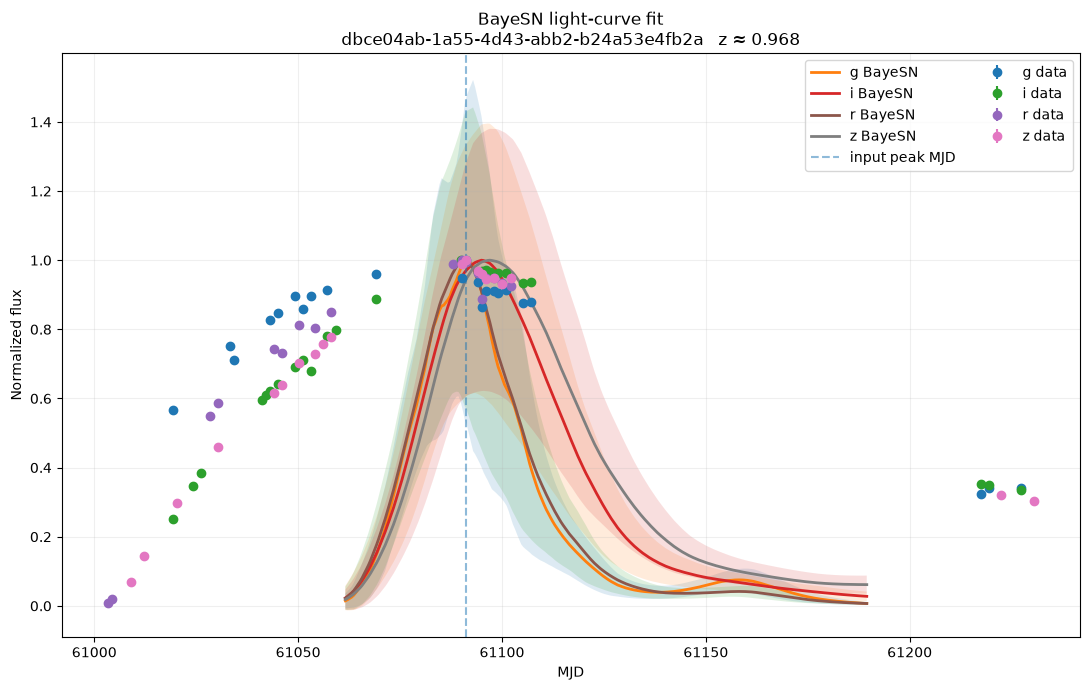

In [83]:
# Convert BayeSN phase grid to MJD
peak_mjd = float(head_row["PEAKMJD"])
#mjd_grid = phase + peak_mjd
mjd_grid = peak_mjd + phase * (1 + z_plot)
phase = np.linspace(-40, 80, 400)
fig, ax = plt.subplots(figsize=(11, 7))

for i, band in enumerate(observed_bands):

    # Observed points for this band
    use = filters == band

    data_flux = flux[use]
    data_err = flux_err[use]
    data_mjd = t[use]

    # BayeSN fitted curve for this band
    model_flux = mean_flux[i]
    model_err = std_flux[i]

    # Normalize data and model separately
    data_scale = np.max(data_flux)
    model_scale = np.max(model_flux)

    data_norm = data_flux / data_scale
    data_err_norm = data_err / data_scale

    model_norm = model_flux / model_scale
    model_err_norm = model_err / model_scale

    # Plot observed points
    ax.errorbar(
        data_mjd,
        data_norm,
        yerr=data_err_norm,
        fmt="o",
        label=f"{band} data",
    )

    # Plot BayeSN mean fit
    ax.plot(
        mjd_grid,
        model_norm,
        linewidth=2,
        label=f"{band} BayeSN",
    )

    # Posterior uncertainty
    ax.fill_between(
        mjd_grid,
        model_norm - model_err_norm,
        model_norm + model_err_norm,
        alpha=0.15,
    )

ax.axvline(
    peak_mjd,
    linestyle="--",
    alpha=0.5,
    label="input peak MJD",
)

ax.set_xlabel("MJD")
ax.set_ylabel("Normalized flux")

ax.set_title(
    f"BayeSN light-curve fit\n"
    f"{target_snid}   z ≈ {z_plot:.3f}"
)

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()